## Montar Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Meli_Case'

In [ ]:
import sys
sys.path.append(path)

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## Funções

In [ ]:
def plot_distribuicao_target(df, variable_name, target_name):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    value_counts = df[variable_name].value_counts().sort_index()
    ax1.bar(value_counts.index, value_counts.values, color='y')
    ax1.set_xlabel(variable_name)
    ax1.set_ylabel('Frequência', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_title(f'Distribuição da Variável {variable_name} e Número de Fraudes')

    ax2 = ax1.twinx()
    fraud_counts = df[df['Fraude'] == 1].groupby(variable_name)['Fraude'].count()
    ax2.plot(fraud_counts.index, fraud_counts.values, color='red', marker='o')
    ax2.set_ylabel('Número de Fraudes', color='black')
    ax2.tick_params(axis='y', labelcolor='black')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_distribuicao(df, variable_name):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[variable_name], kde=True, palette='deep')
    plt.title(f'Distribuição da Variável {variable_name}')
    plt.xlabel(variable_name)
    plt.ylabel('Frequência')
    plt.show()

In [ ]:
def plotar_percentual_por_categoria(df, var, target):
    grupo = df.groupby([var, target]).size().reset_index(name='count')

    grupo_total = grupo.groupby(var)['count'].transform('sum')
    grupo['percentual'] = 100 * grupo['count'] / grupo_total

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=grupo, x=var, y='percentual', hue=target, palette='deep')
    plt.title(f"Variável '{var}' x {target}")
    plt.ylabel("Percentual %")
    plt.xlabel(f"{var}")
    plt.tight_layout()
    plt.show()

## Base

In [ ]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base

,A,B,C,D,E,F,G,H,I,J,...,L,M,N,O,P,Q,R,S,Monto,Fraude
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,0,3,1,0,5,0.00,0.00,7.25,37.51,1
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,0,1,1,0,3,0.00,0.00,11.66,8.18,1
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,0,3,1,0,2,0.00,0.00,86.97,13.96,1
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,0,3,1,0,5,0.00,0.00,2.51,93.67,1
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,0,1,1,0,1,0.00,0.00,25.96,135.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,1,1,0,1,0.00,0.00,85.73,132.17,1
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,1,1,0,5,0.00,0.00,12.50,26.34,1
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,0,1,1,0,1,0.00,0.00,24.16,195.63,1
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,0,2,1,0,1,0.00,0.00,29.00,36.97,1


In [ ]:
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})
base

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,...,var_L,var_M,var_N,var_O,var_P,var_Q,var_R,var_S,Monto,Fraude
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,0,3,1,0,5,0.00,0.00,7.25,37.51,1
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,0,1,1,0,3,0.00,0.00,11.66,8.18,1
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,0,3,1,0,2,0.00,0.00,86.97,13.96,1
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,0,3,1,0,5,0.00,0.00,2.51,93.67,1
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,0,1,1,0,1,0.00,0.00,25.96,135.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,1,1,0,1,0.00,0.00,85.73,132.17,1
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,1,1,0,5,0.00,0.00,12.50,26.34,1
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,0,1,1,0,1,0.00,0.00,24.16,195.63,1
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,0,2,1,0,1,0.00,0.00,29.00,36.97,1


## Volumetria, Nulos e Distribuição da Traget

In [ ]:
base.shape

(16880, 21)

In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var_A   16880 non-null  int64  
 1   var_B   16880 non-null  int64  
 2   var_C   13683 non-null  float64
 3   var_D   16880 non-null  int64  
 4   var_E   16880 non-null  int64  
 5   var_F   16880 non-null  float64
 6   var_G   16880 non-null  float64
 7   var_H   16880 non-null  int64  
 8   var_I   16880 non-null  int64  
 9   var_J   16880 non-null  object 
 10  var_K   4016 non-null   float64
 11  var_L   16880 non-null  int64  
 12  var_M   16880 non-null  int64  
 13  var_N   16880 non-null  int64  
 14  var_O   16880 non-null  int64  
 15  var_P   16880 non-null  int64  
 16  var_Q   16880 non-null  object 
 17  var_R   16880 non-null  object 
 18  var_S   16880 non-null  object 
 19  Monto   16880 non-null  object 
 20  Fraude  16880 non-null  int64  
dtypes: float64(4), int64(12), object(5)

In [ ]:
## Número de Nulos nas Variáveis
base.isna().sum()

,0
var_A,0
var_B,0
var_C,3197
var_D,0
var_E,0
var_F,0
var_G,0
var_H,0
var_I,0
var_J,0


In [ ]:
## Percentual de Nulos nas Variáveis
(base.isna().sum()/len(base)*100).round()

,0
var_A,0.0
var_B,0.0
var_C,19.0
var_D,0.0
var_E,0.0
var_F,0.0
var_G,0.0
var_H,0.0
var_I,0.0
var_J,0.0


In [ ]:
base.groupby('Fraude').count()

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,var_K,var_L,var_M,var_N,var_O,var_P,var_Q,var_R,var_S,Monto
Fraude,,,,,,,,,,,,,,,,,,,,
0,12269,12269,9625,12269,12269,12269,12269,12269,12269,12269,2563,12269,12269,12269,12269,12269,12269,12269,12269,12269
1,4611,4611,4058,4611,4611,4611,4611,4611,4611,4611,1453,4611,4611,4611,4611,4611,4611,4611,4611,4611


In [ ]:
pct_fraude = float((base['Fraude'].sum() / len(base)*100).round(2))
print(f"Percentual de Fraude na Base {pct_fraude}")
print(f"Percentual de Não Fraude na Base {100 - pct_fraude}")

Percentual de Fraude na Base 27.32
Percentual de Não Fraude na Base 72.68


## Análise Exploratória de Variáveis Numéricas

As variáveis abaixo estavam identificadas como INT/FLOAT no descritivo da base.

Avaliar a Relação com a Target.

In [ ]:
base.describe()

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_K,var_L,var_M,var_N,var_O,var_P,Fraude
count,16880.000000,16880.000000,13683.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000,4016.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000
mean,0.309242,7.645379,39235.339984,0.198697,0.433709,5.612705,1.439842,0.050296,0.144076,0.682099,0.432346,1.544135,1.091765,0.009419,1.630865,0.273164
std,1.094064,4.686494,91045.252879,2.042959,1.537297,37.362389,19.347937,0.531060,0.824761,0.153264,0.663860,1.022385,0.408081,0.116606,1.088286,0.445597
min,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.120000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,4.000000,1172.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.580000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,0.000000,7.000000,6173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.680000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,0.000000,11.000000,26888.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,1.000000,2.000000,1.000000,0.000000,2.000000,1.000000
max,30.000000,20.000000,617324.000000,180.000000,45.000000,667.000000,667.000000,21.000000,24.000000,0.990000,7.000000,13.000000,10.000000,3.000000,41.000000,1.000000


In [ ]:
base.describe().columns

Index(['var_A', 'var_B', 'var_C', 'var_D', 'var_E', 'var_F', 'var_G', 'var_H',
       'var_I', 'var_K', 'var_L', 'var_M', 'var_N', 'var_O', 'var_P',
       'Fraude'],
      dtype='object')

In [ ]:
colunas = ['var_A', 'var_B', 'var_C', 'var_D', 'var_E', 'var_F', 'var_G', 'var_H',
       'var_I', 'var_K', 'var_L', 'var_M', 'var_N', 'var_O', 'var_P']

var_A


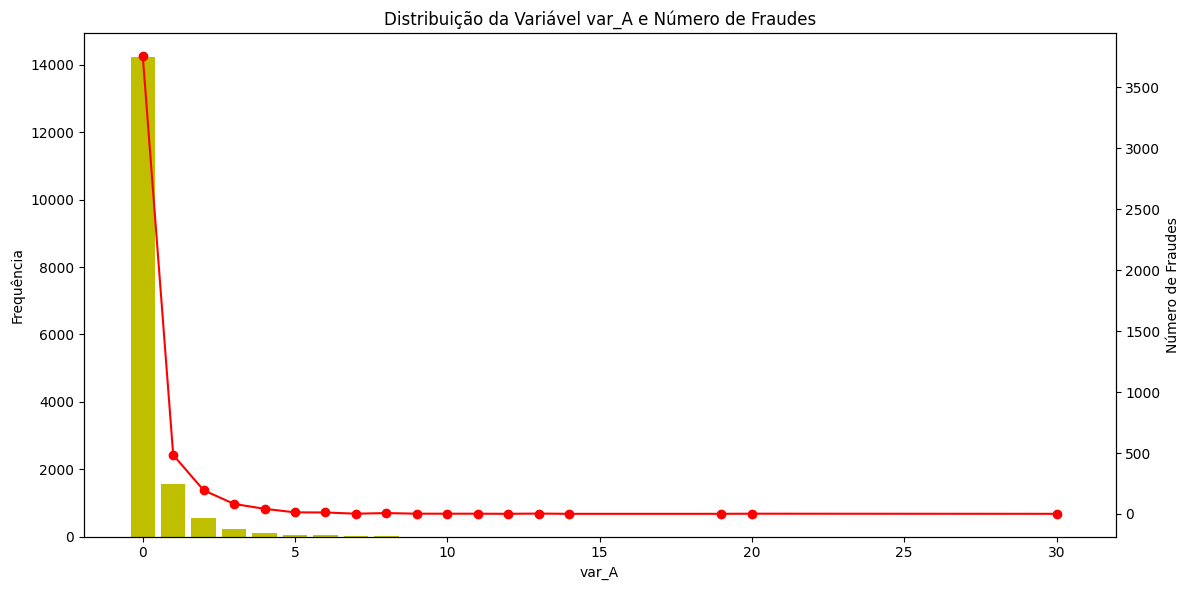

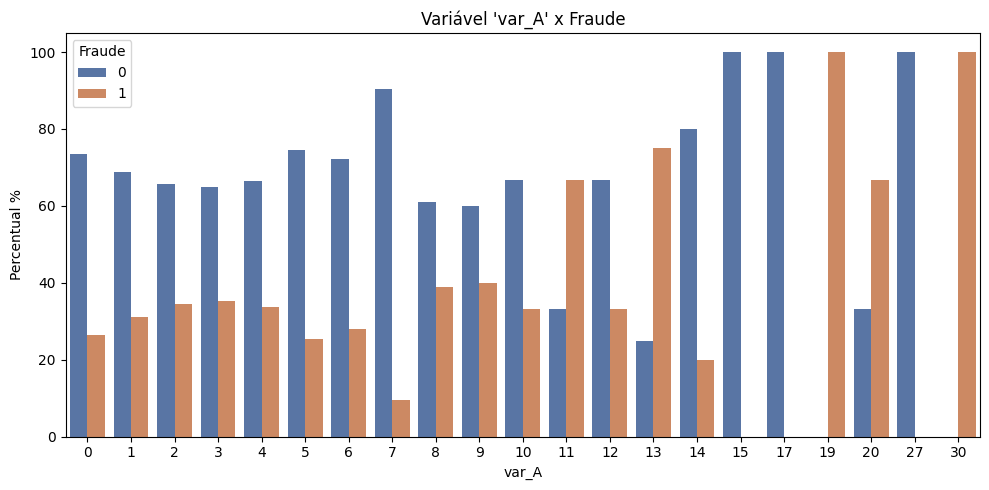

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


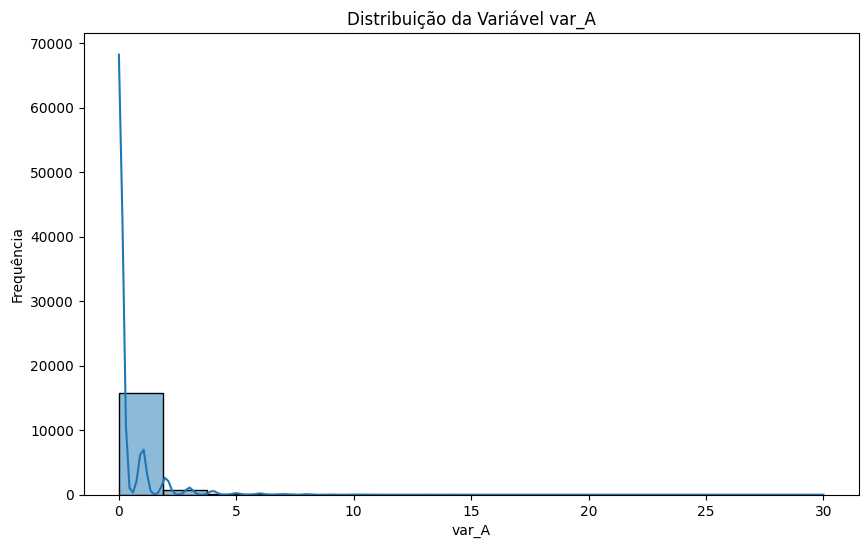

var_B


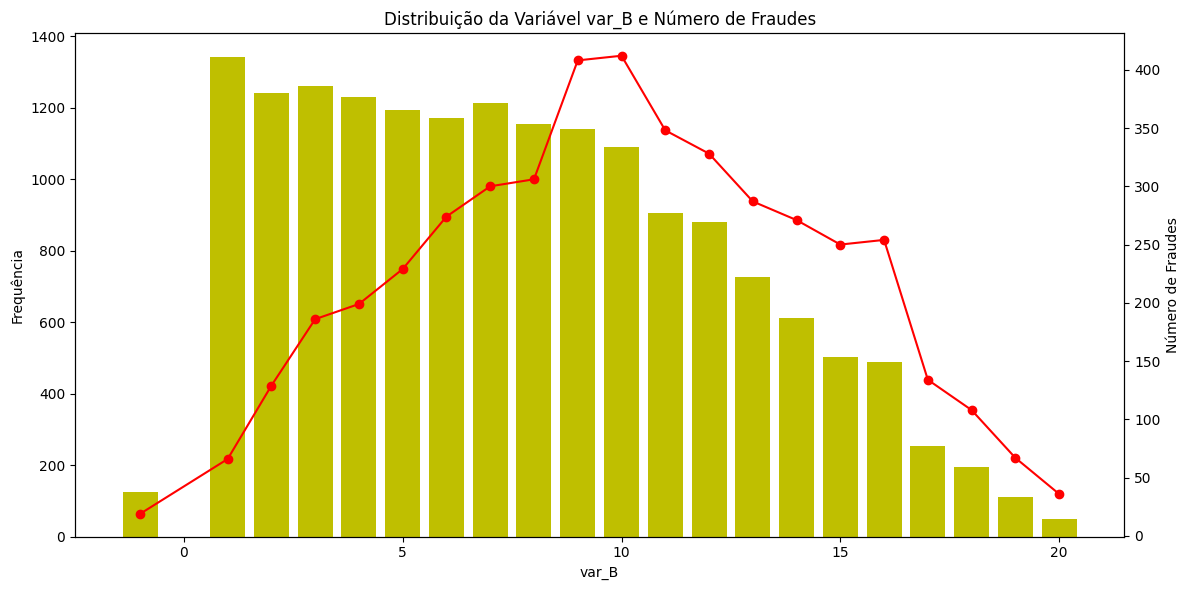

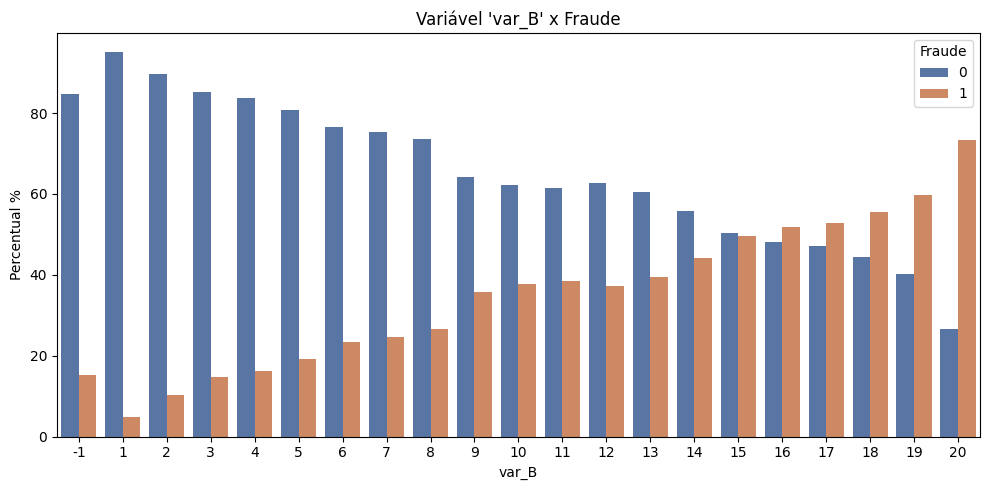

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


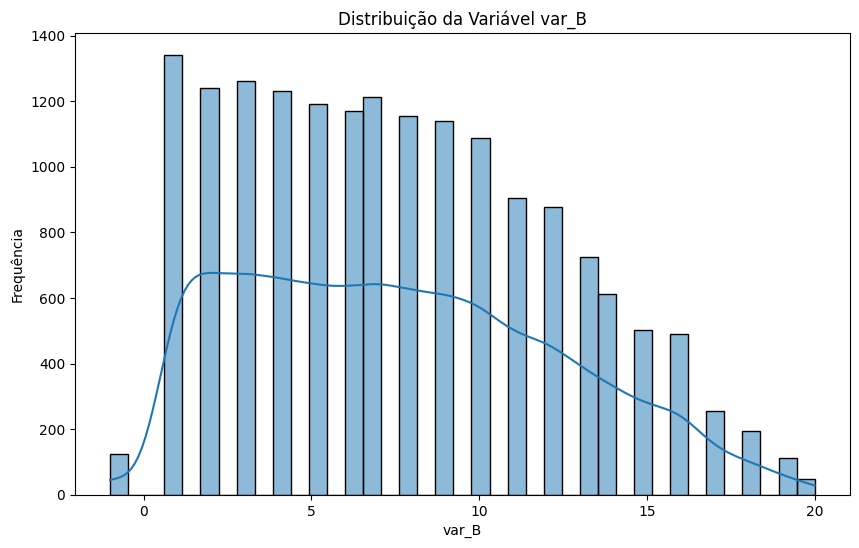

var_C


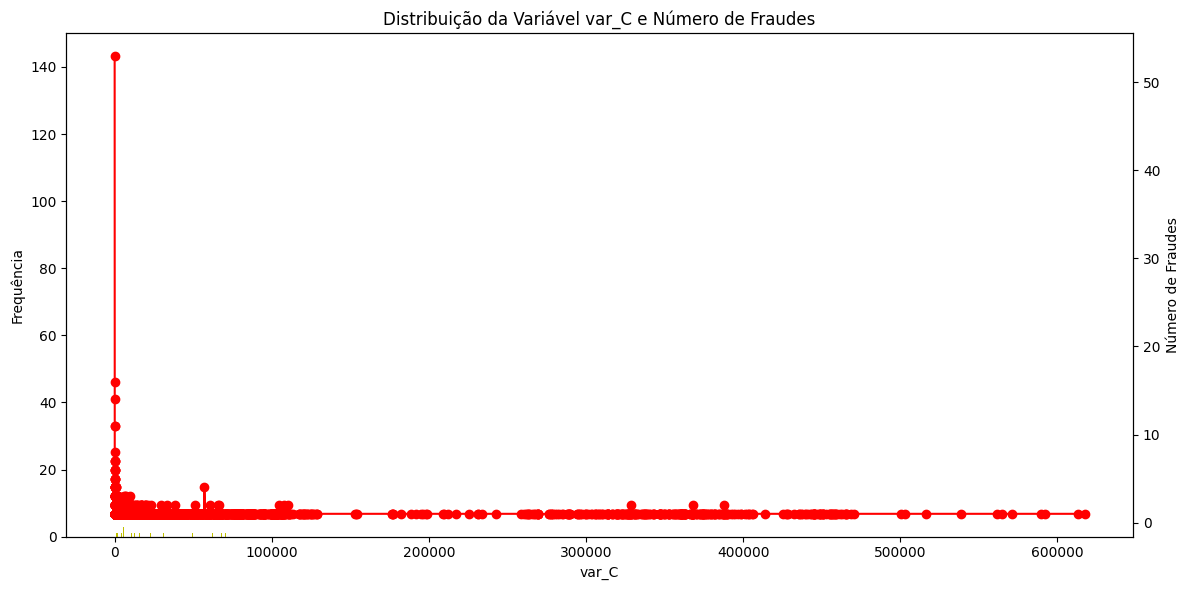

<ipython-input-8-1e83fc71f913>:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


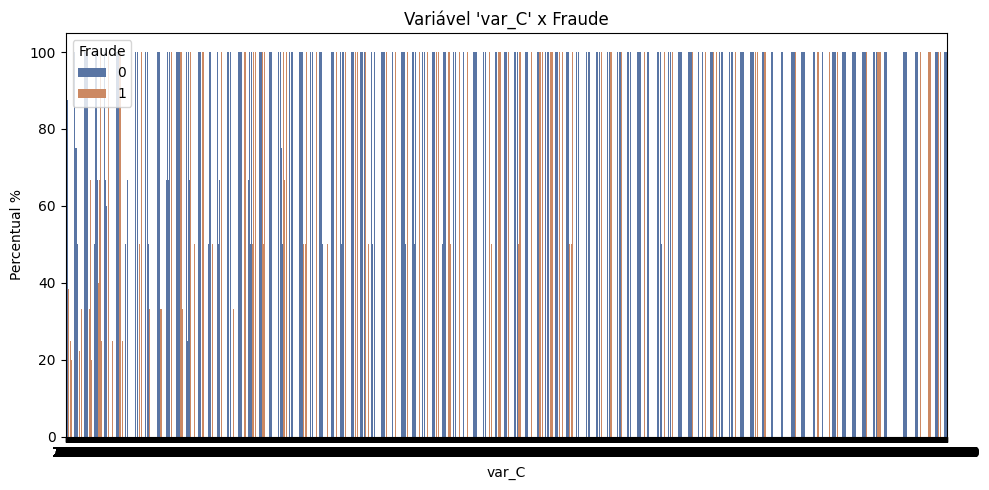

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


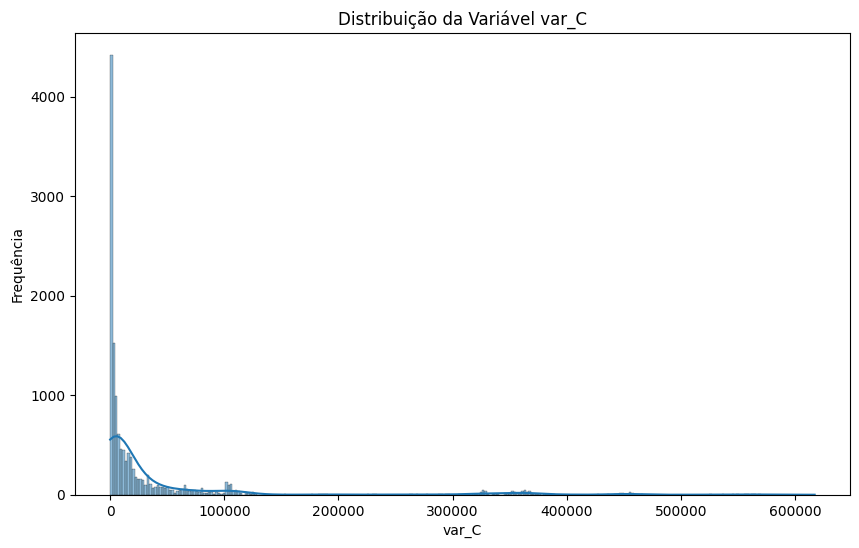

var_D


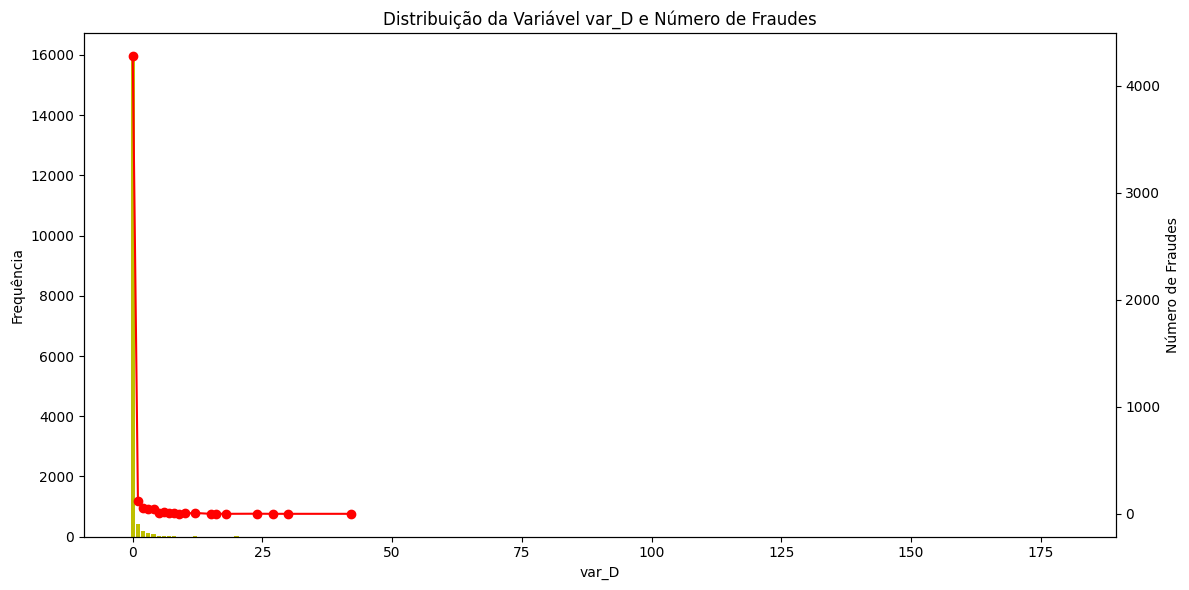

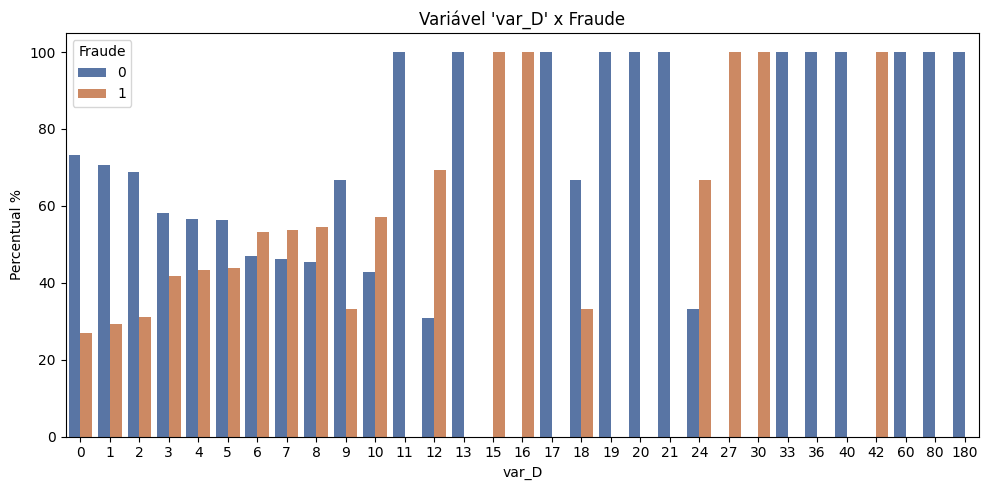

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


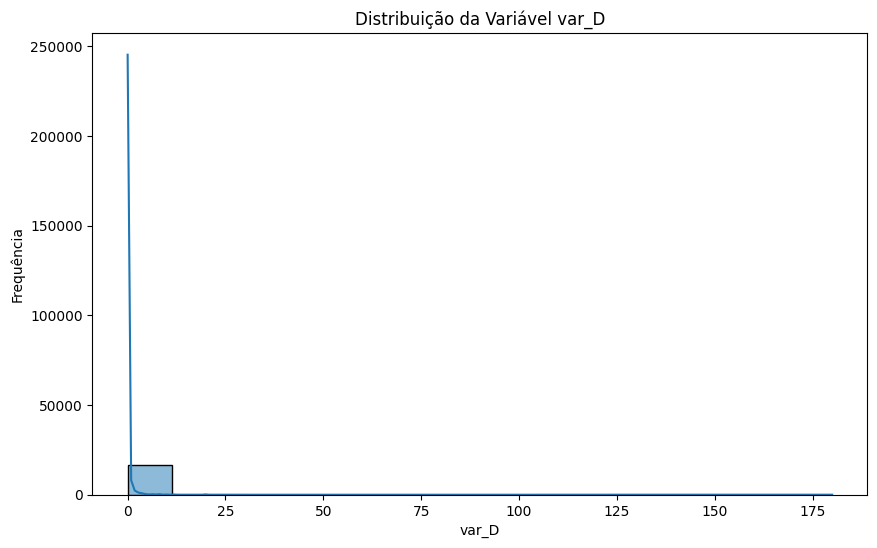

var_E


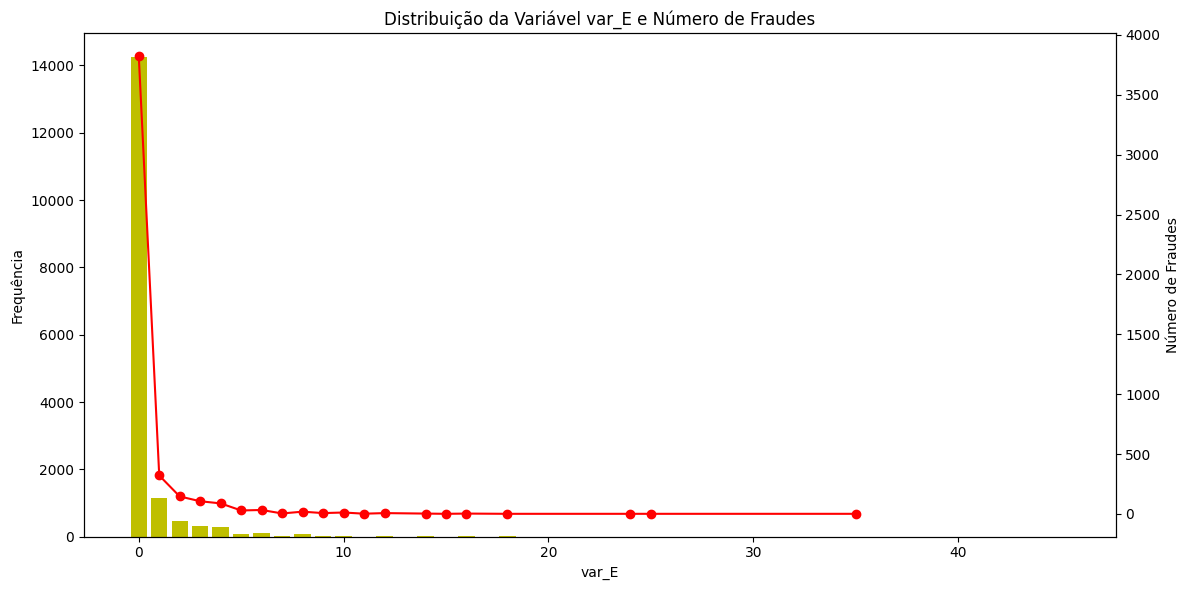

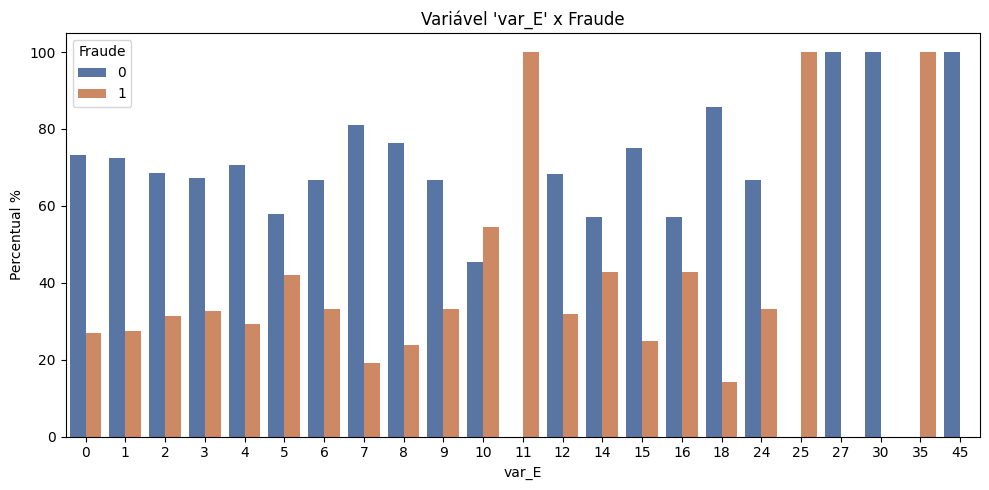

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


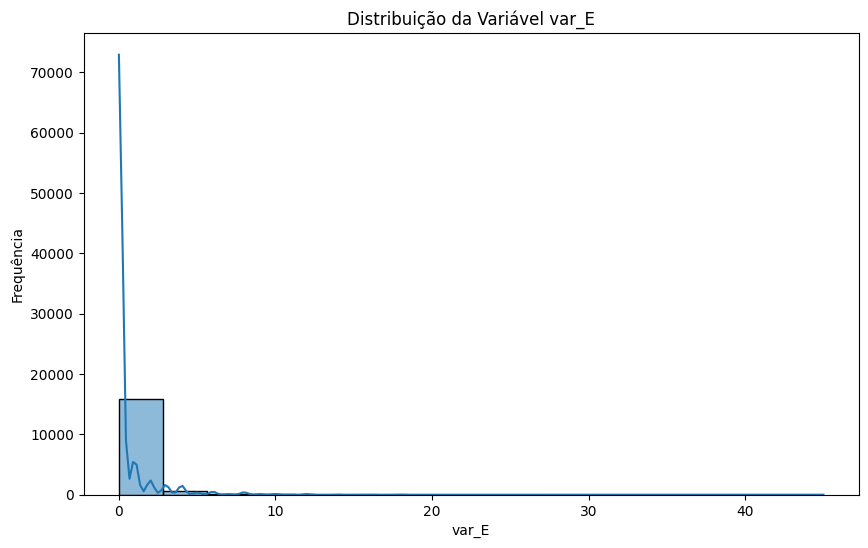

var_F


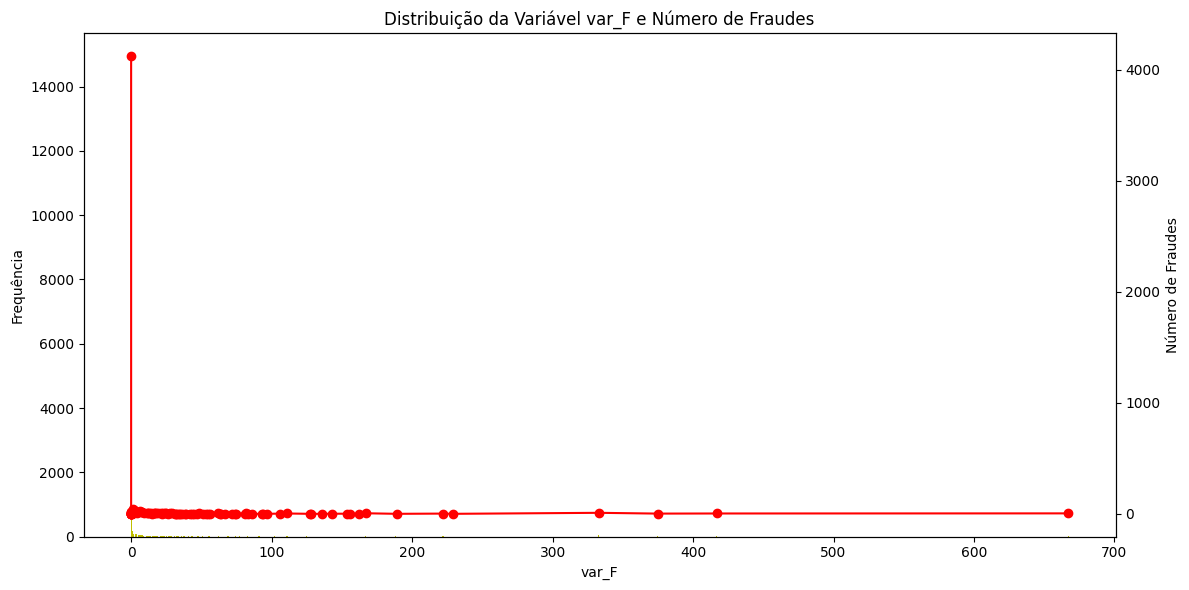

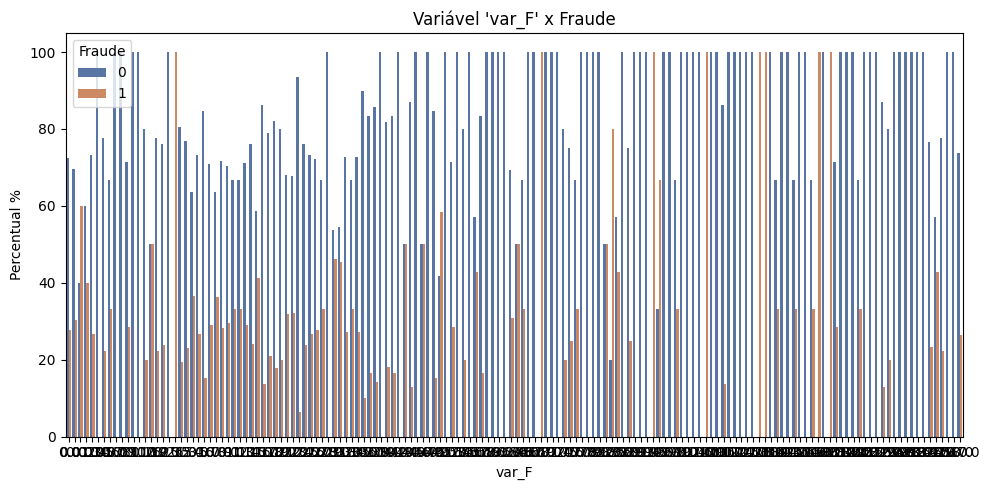

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


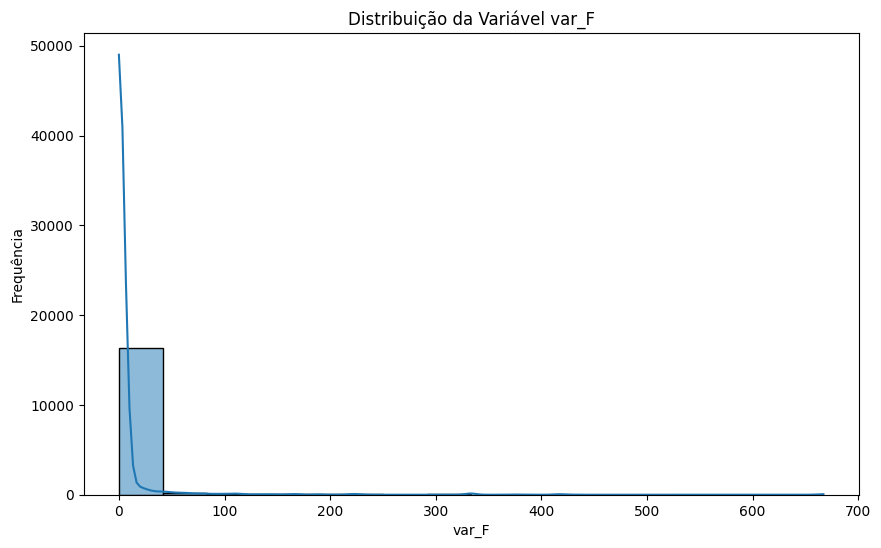

var_G


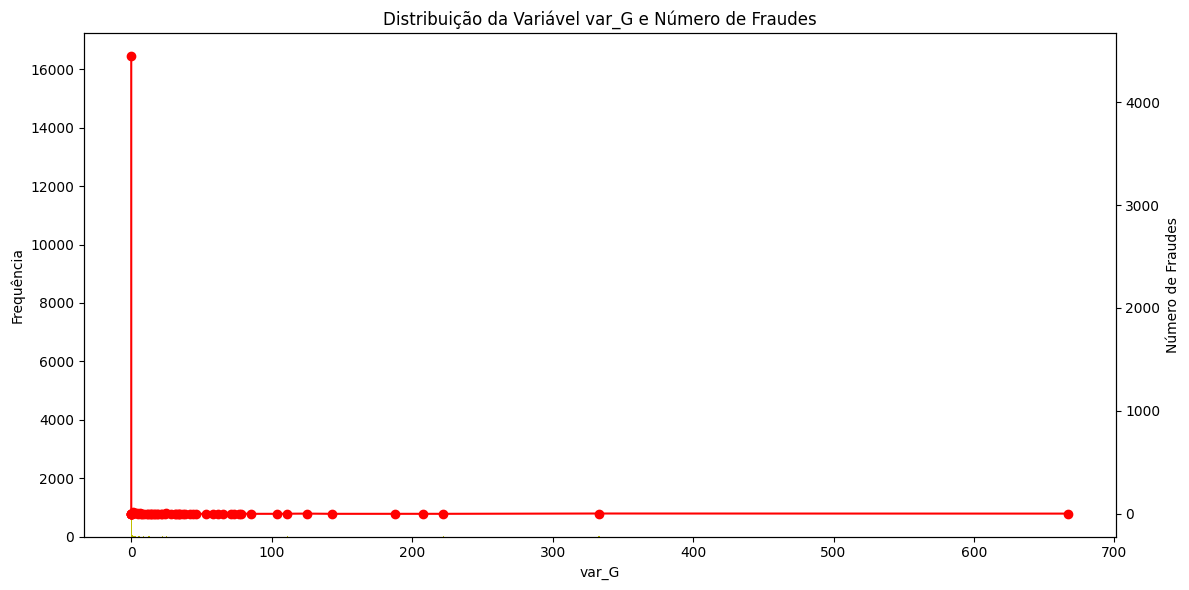

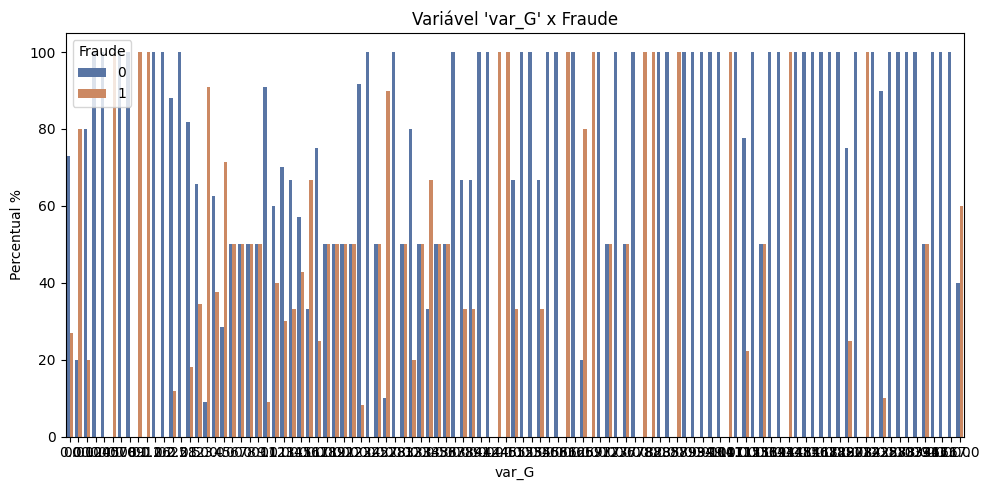

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


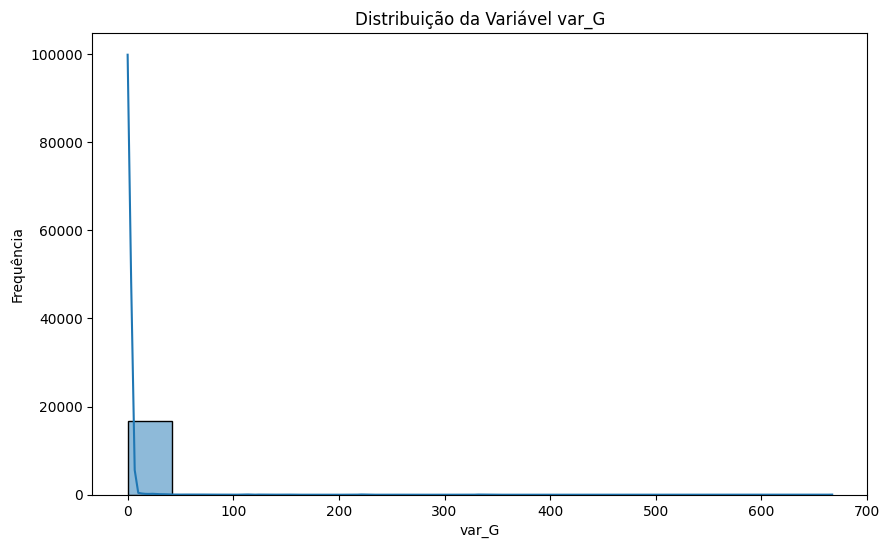

var_H


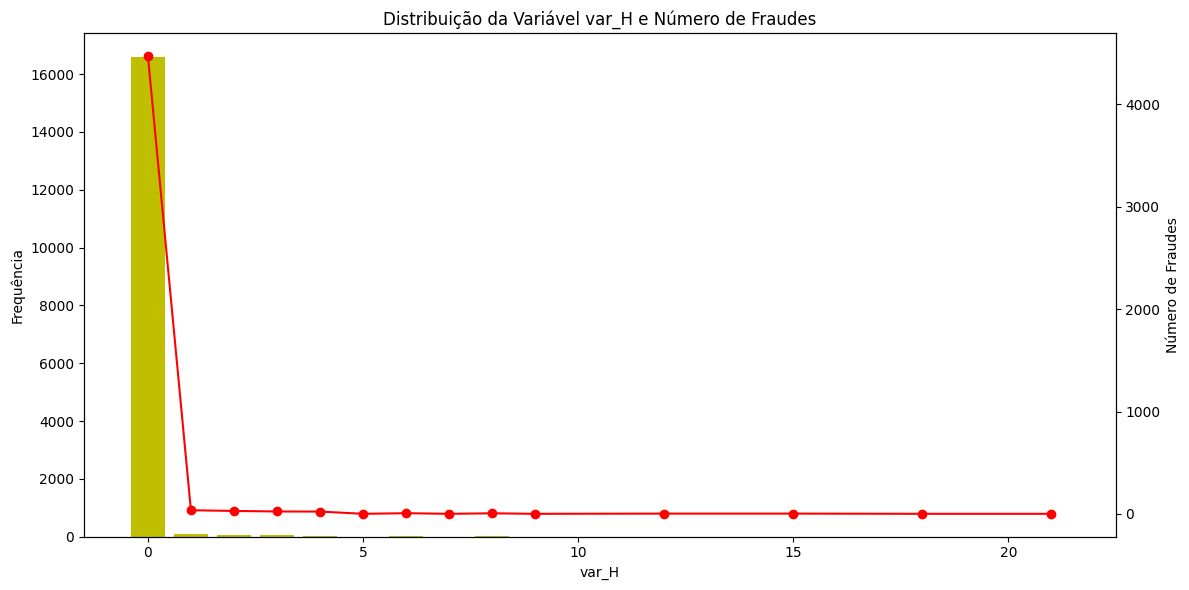

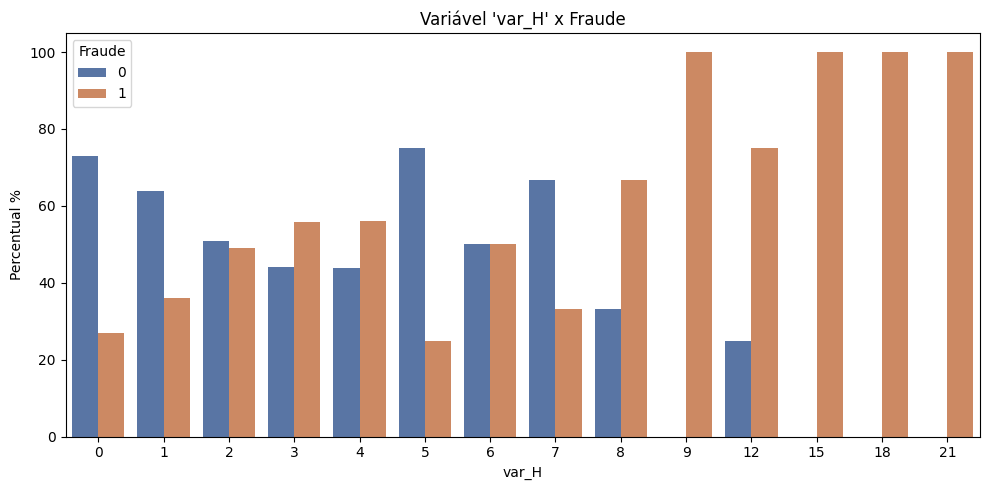

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


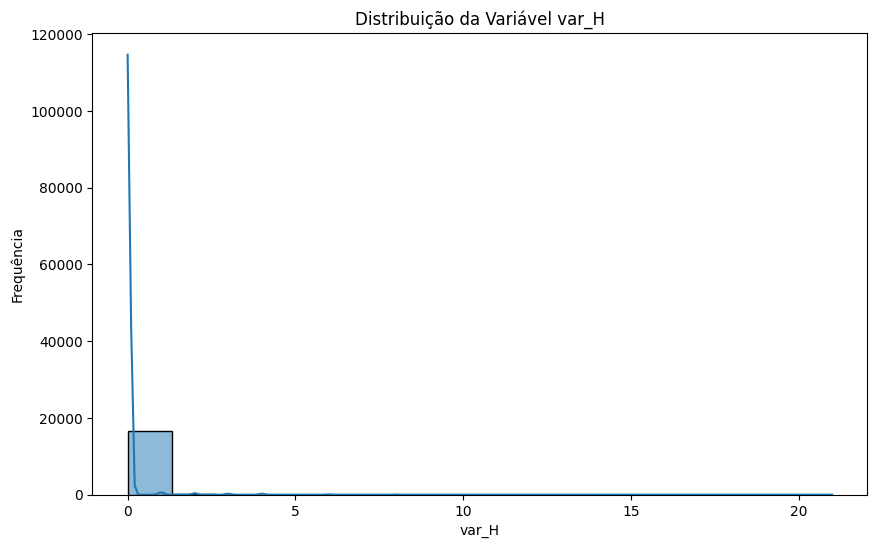

var_I


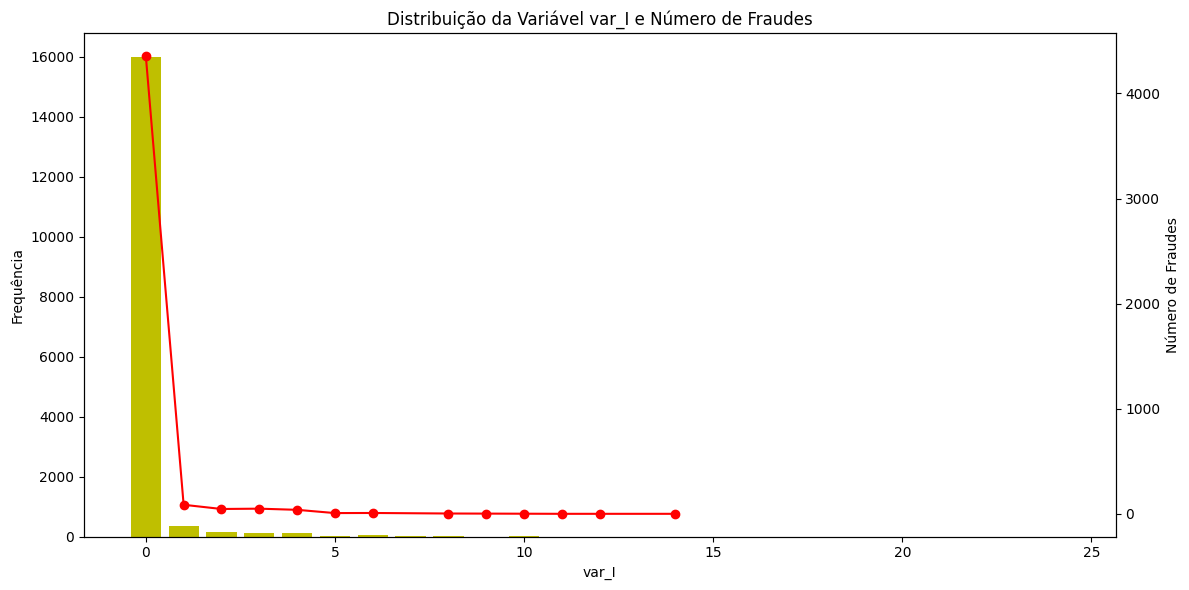

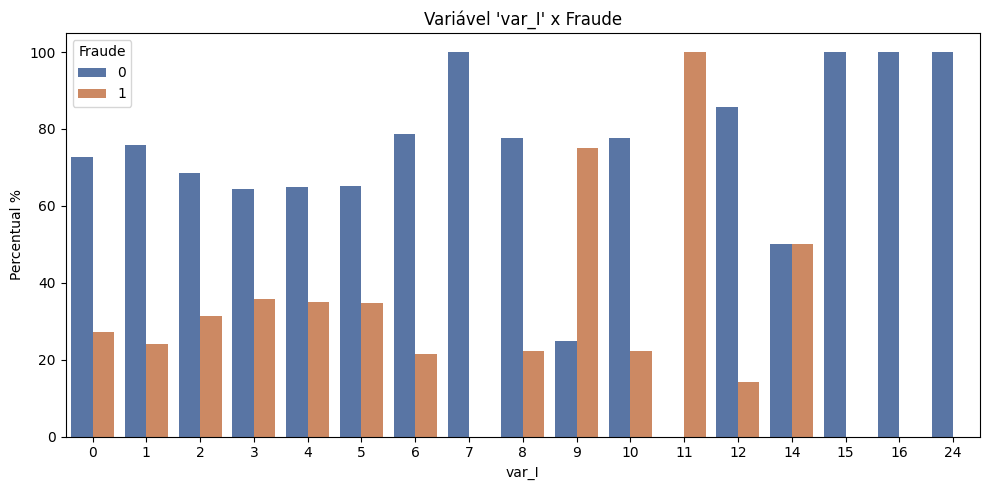

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


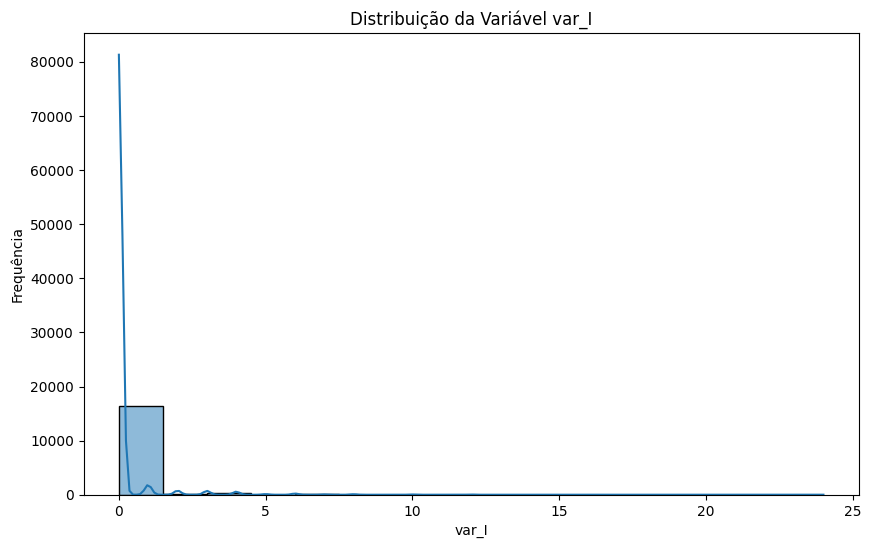

var_K


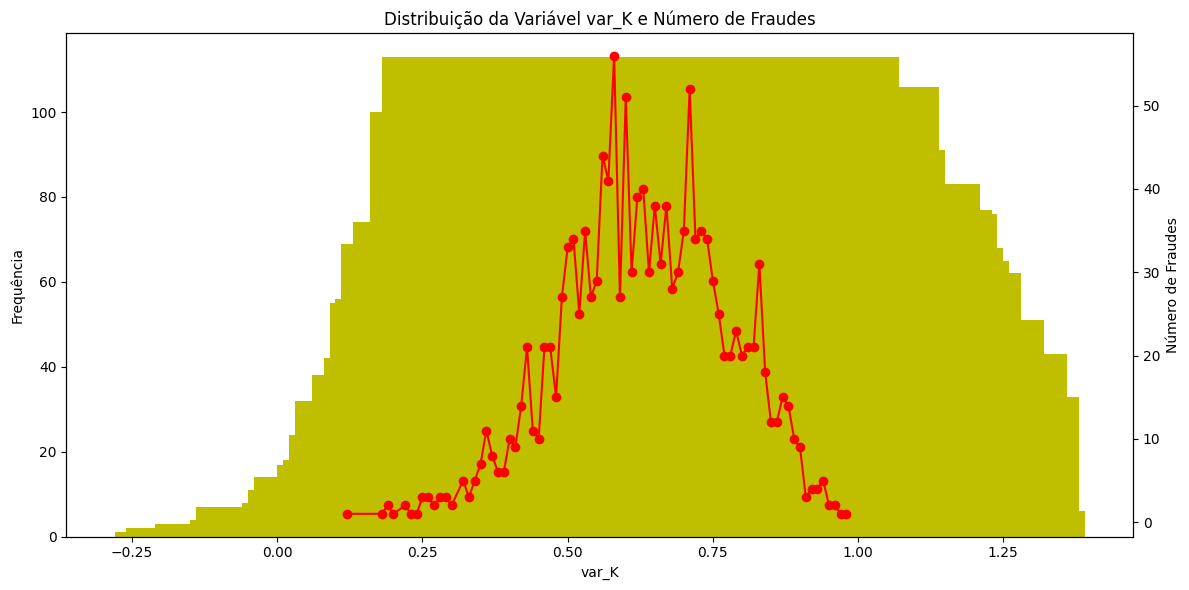

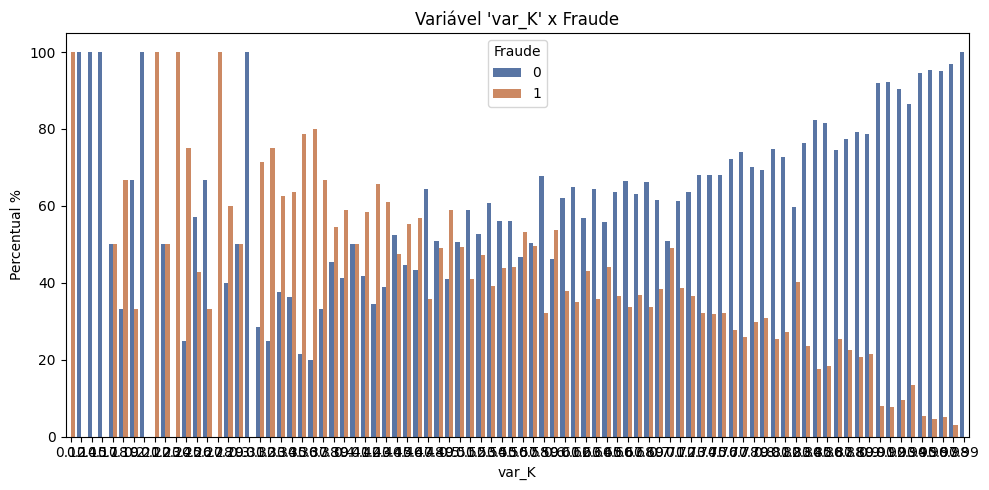

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


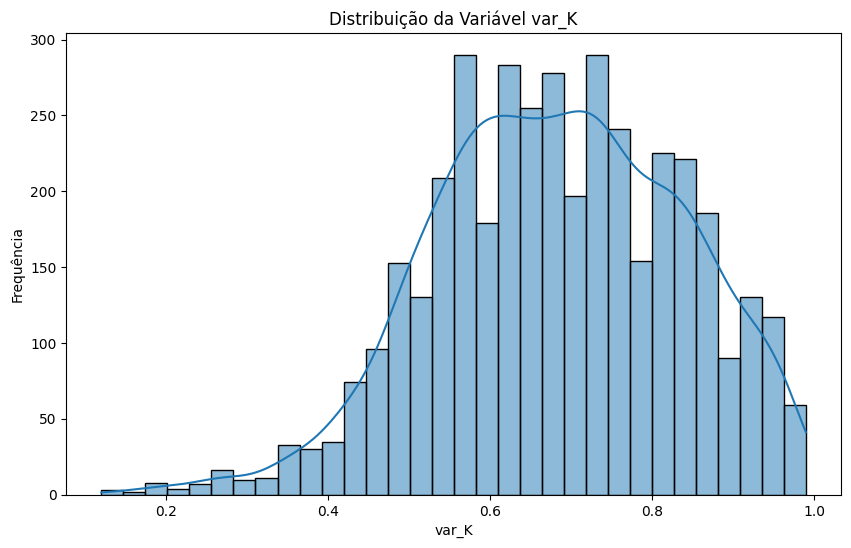

var_L


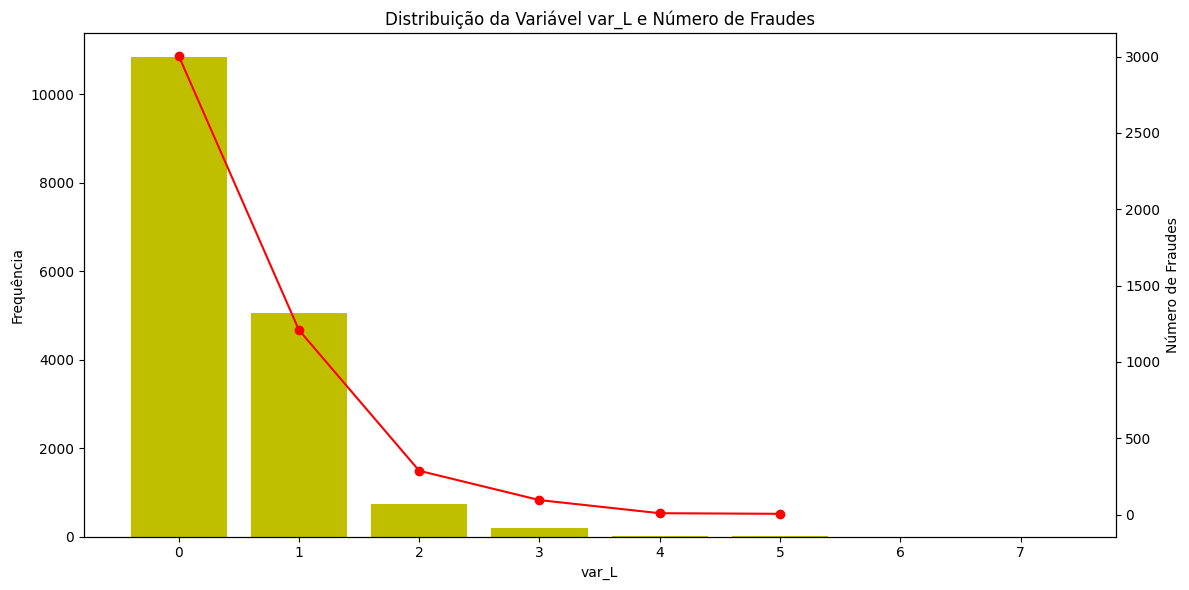

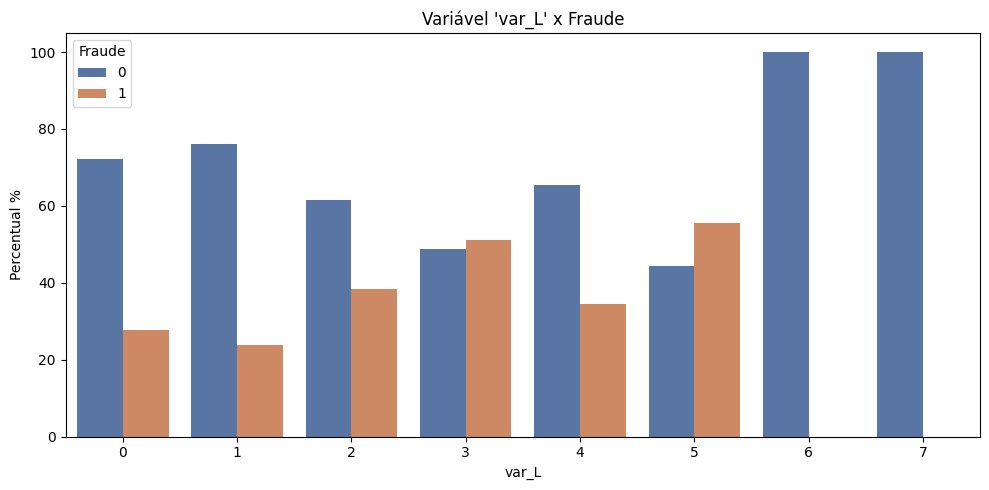

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


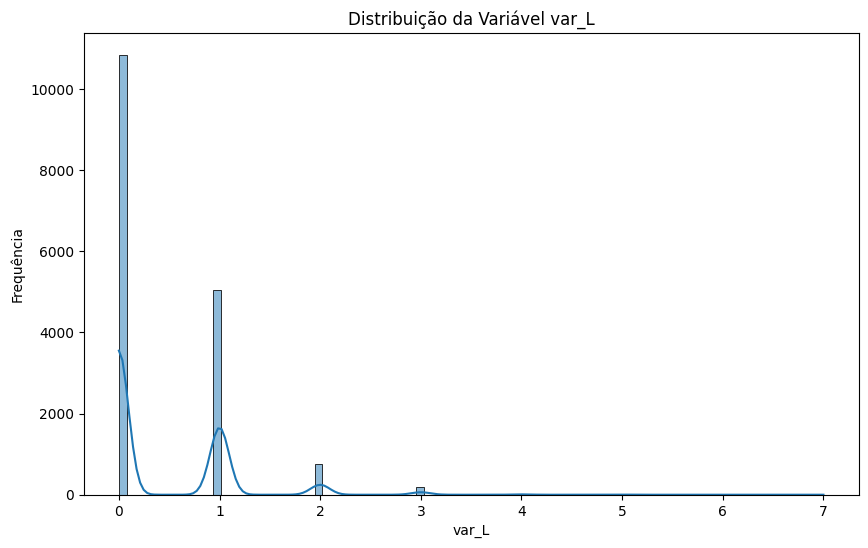

var_M


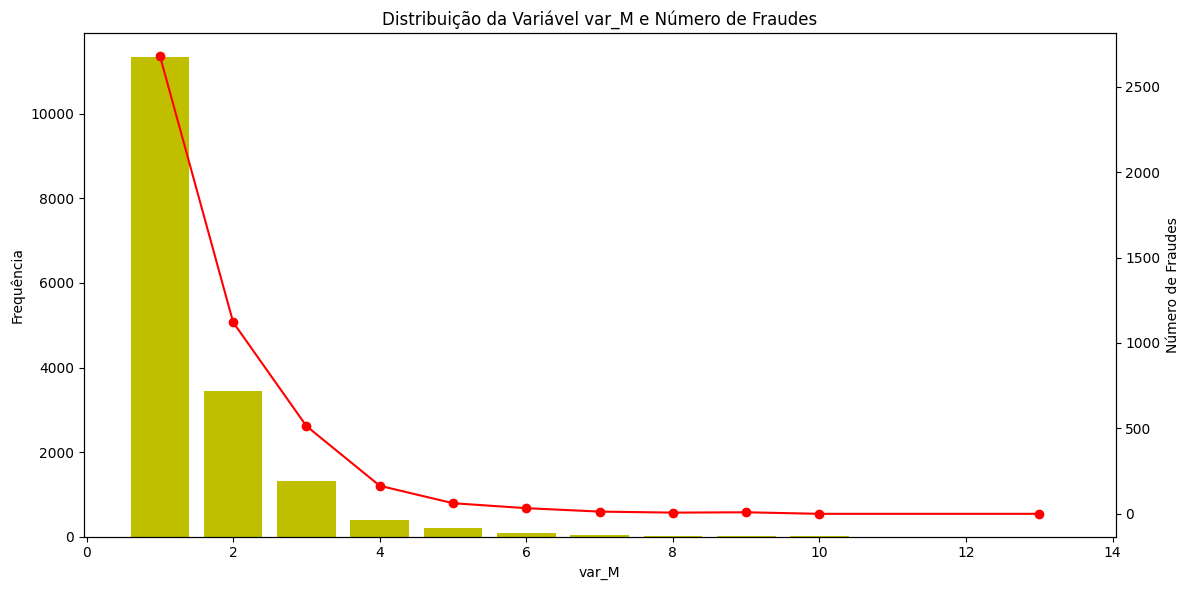

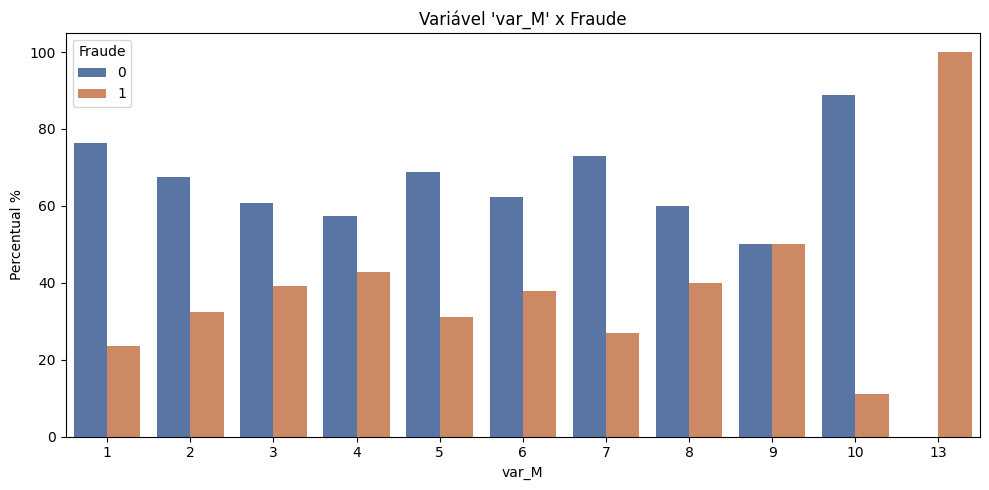

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


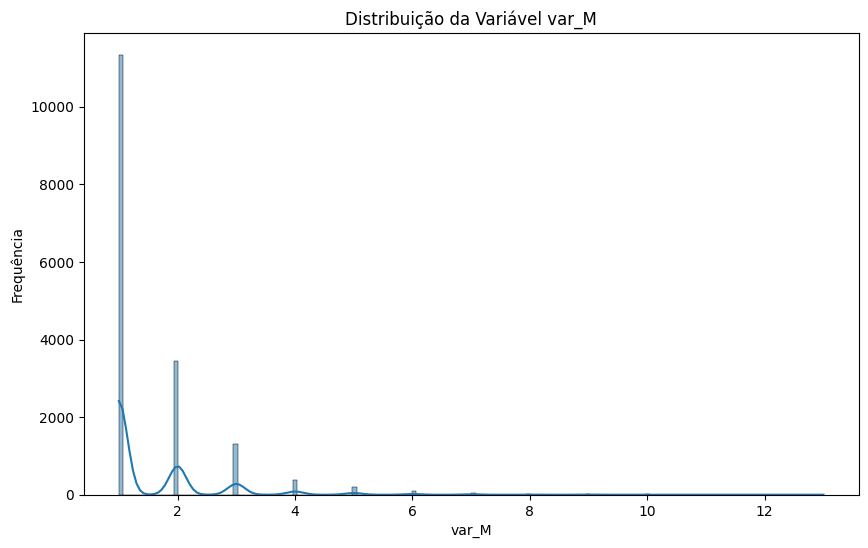

var_N


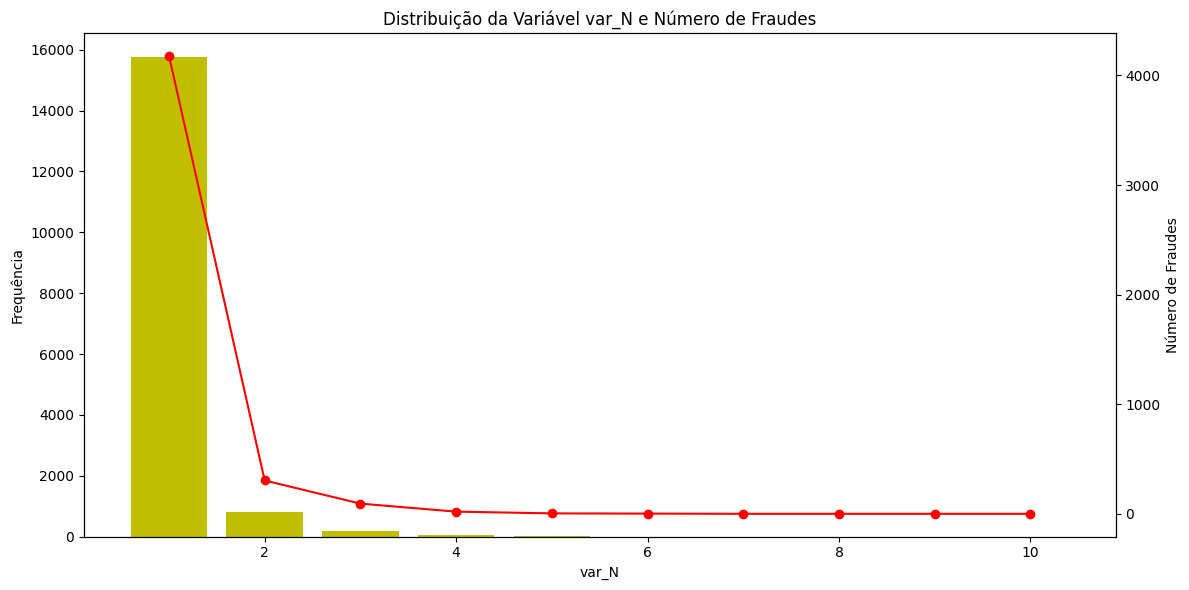

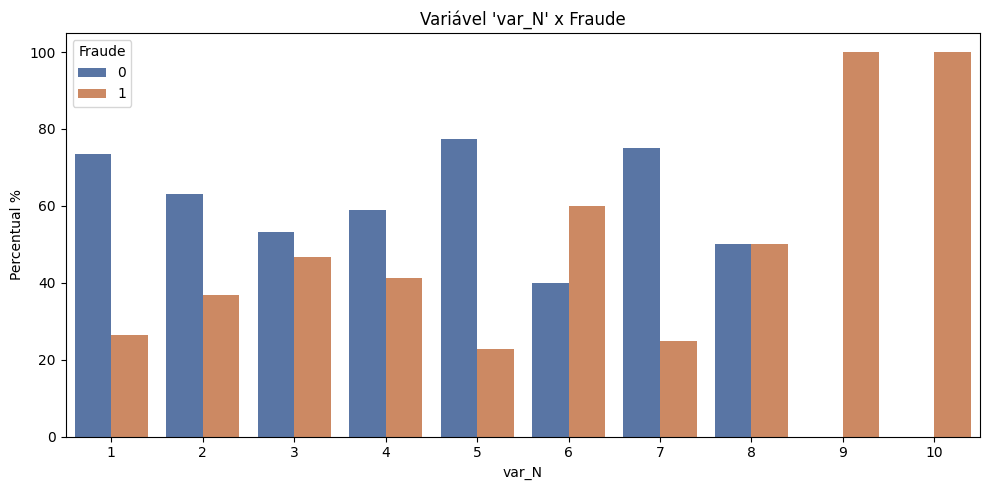

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


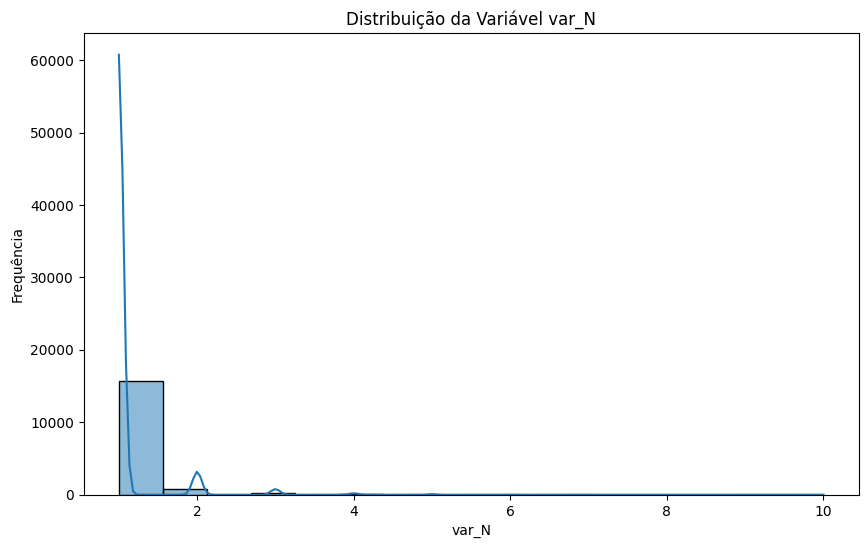

var_O


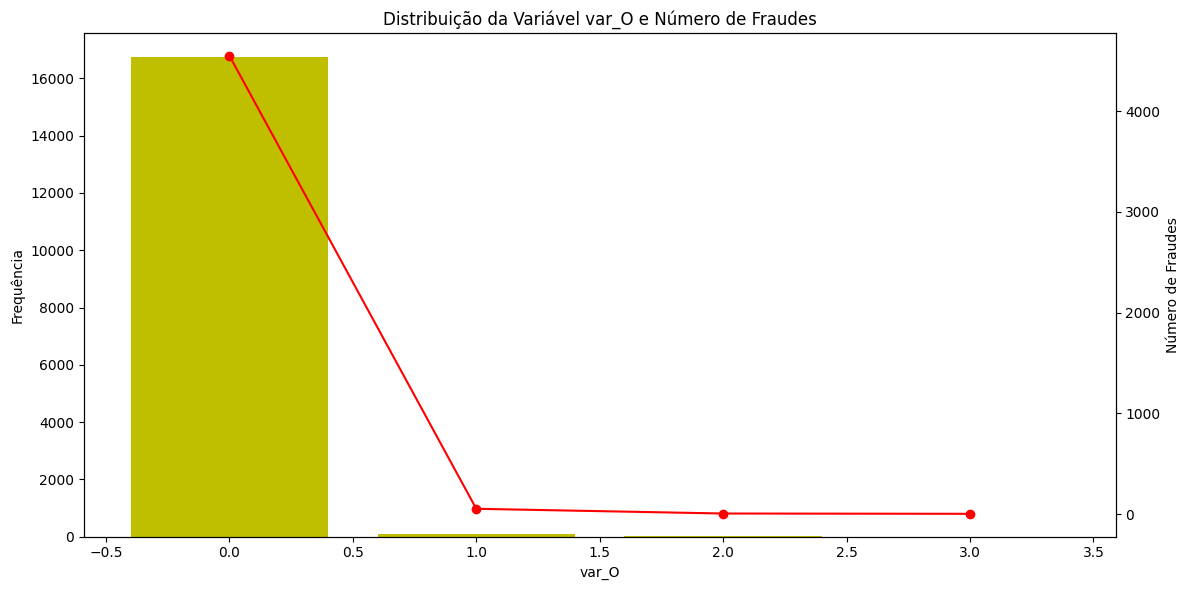

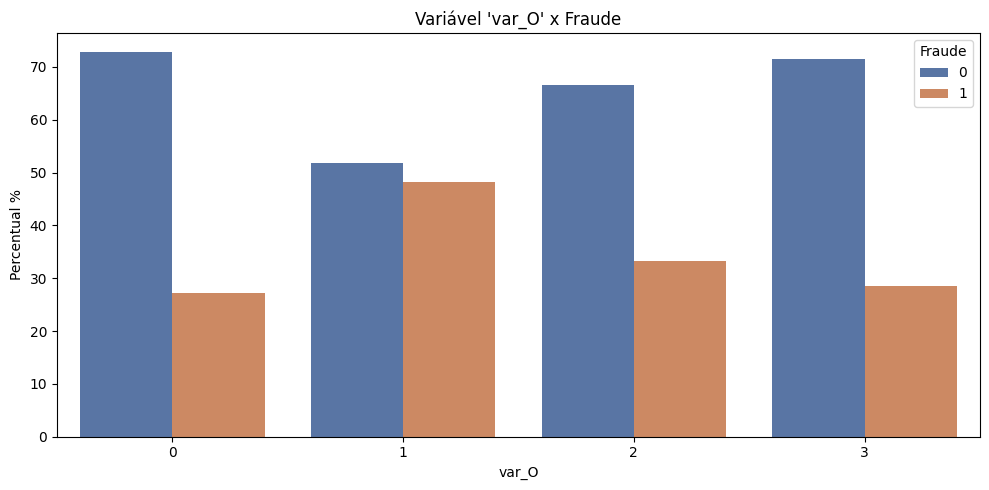

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


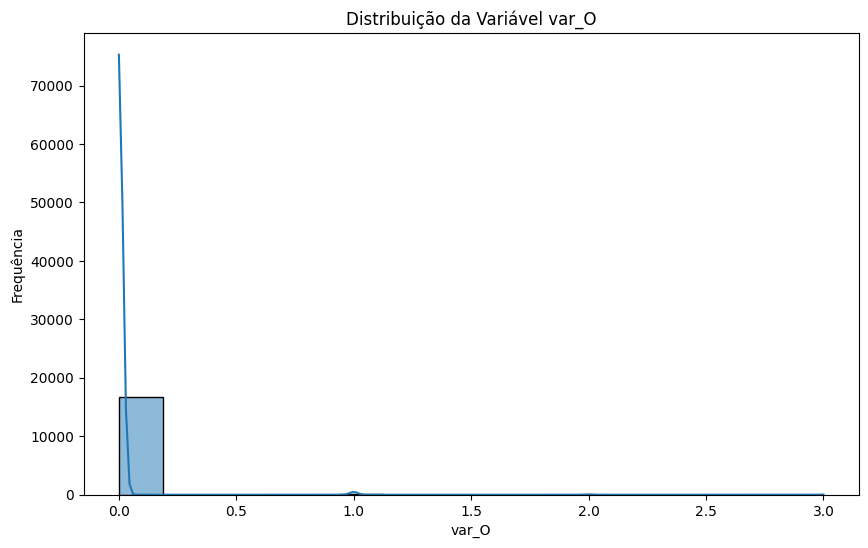

var_P


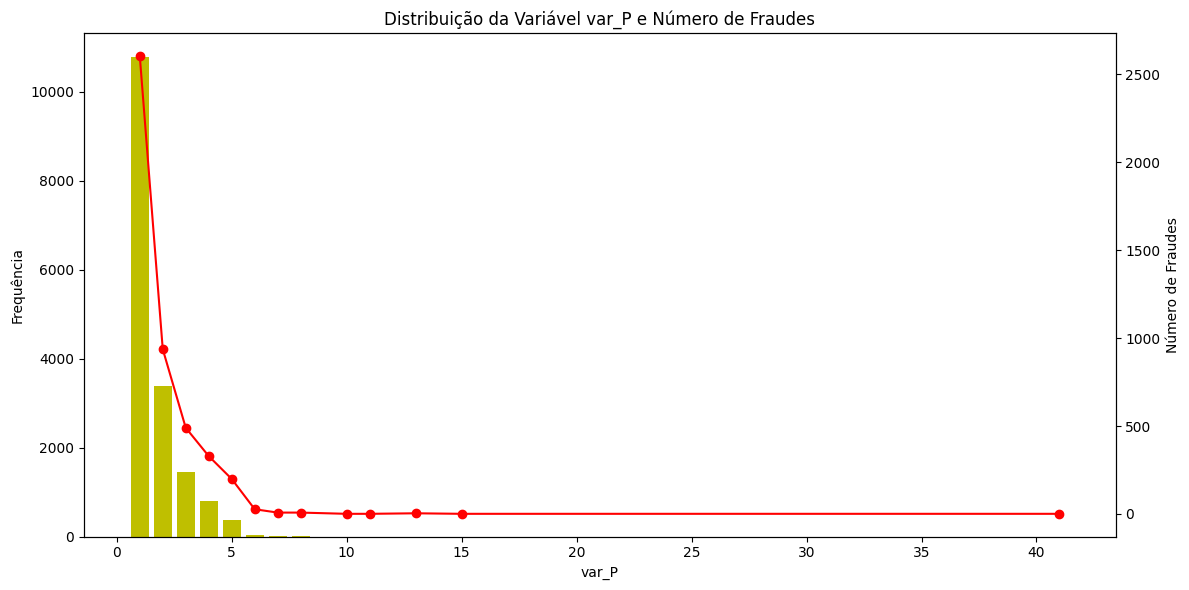

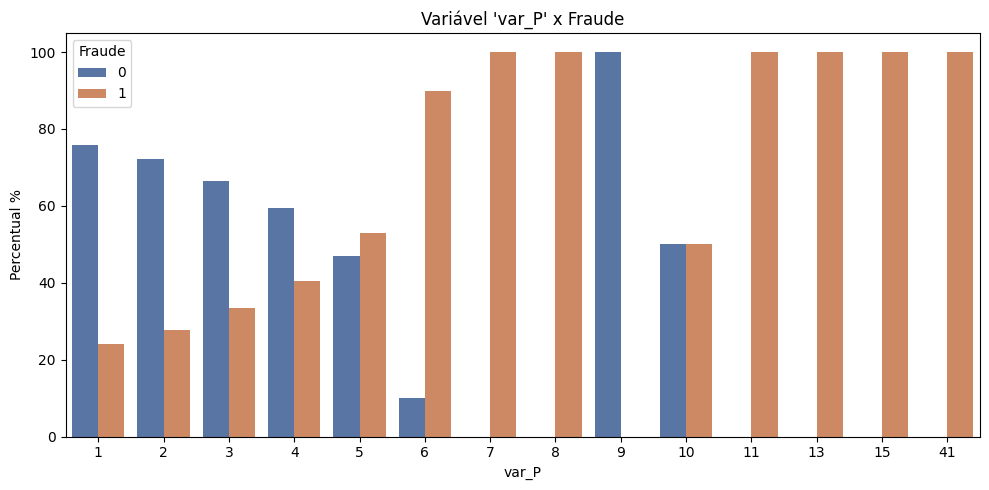

<ipython-input-7-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


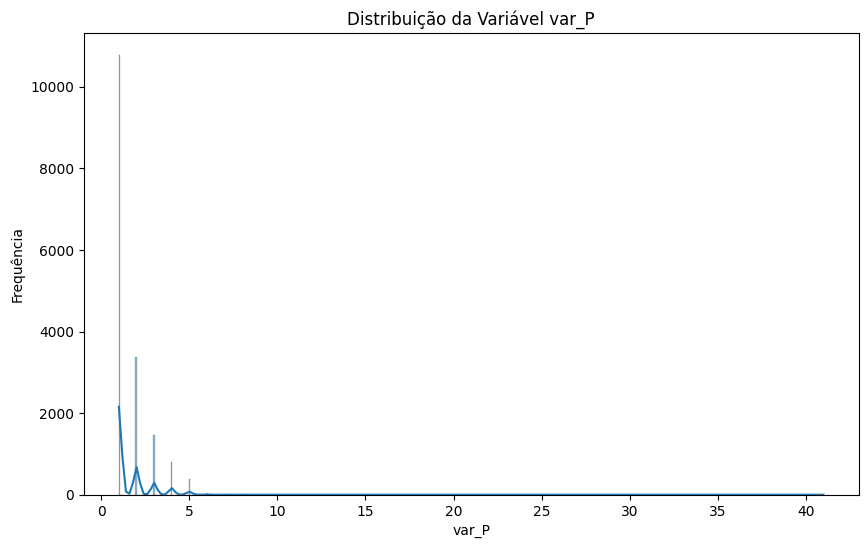

In [ ]:
for k in colunas:
  print(k)
  plot_distribuicao_target(base, k, 'Fraude')
  plotar_percentual_por_categoria(base, k, 'Fraude')
  plot_distribuicao(base, k)

### Variável C

In [ ]:
base['var_C'].describe()

,var_C
count,13683.000000
mean,39235.339984
std,91045.252879
min,0.000000
25%,1172.000000
50%,6173.000000
75%,26888.500000
max,617324.000000


In [ ]:
base['var_C'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

,var_C
0.1,148.0
0.2,704.0
0.3,1805.6
0.4,3581.8
0.5,6173.0
0.6,11647.8
0.7,19231.6
0.8,38334.0
0.9,101455.0


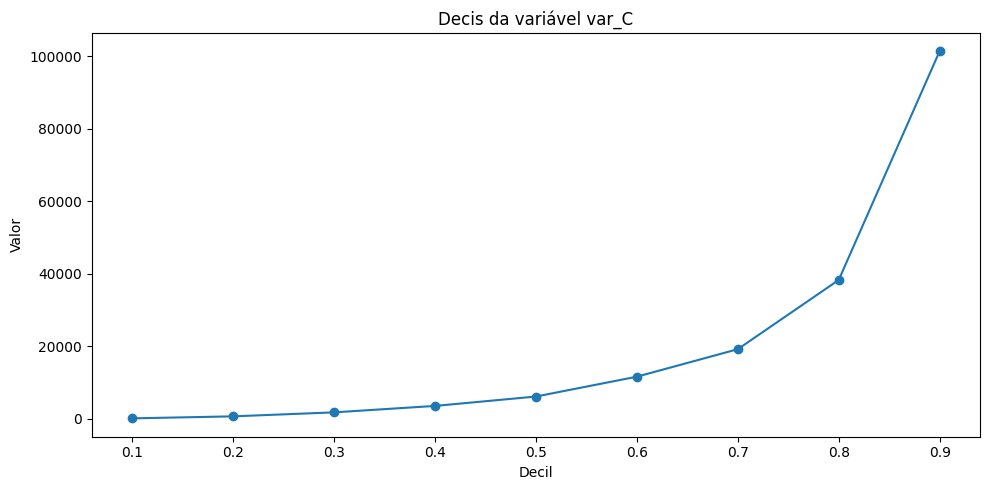

In [ ]:
decis = base['var_C'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.figure(figsize=(10, 5))
plt.plot(decis.index, decis.values, marker='o', linestyle='-')
plt.title("Decis da variável var_C")
plt.xlabel("Decil")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

### Variável F

In [ ]:
base['var_F'].describe()

,var_F
count,16880.000000
mean,5.612705
std,37.362389
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,667.000000


In [ ]:
base['var_F'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

,var_F
0.1,0.00
0.2,0.00
0.3,0.00
0.4,0.00
0.5,0.00
0.6,0.00
0.7,0.00
0.8,0.00
0.9,0.55


In [ ]:
base['var_F'].quantile([0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

,var_F
0.91,1.00
0.92,3.00
0.93,6.00
0.94,9.00
0.95,16.05
0.96,24.00
0.97,42.00
0.98,69.84
0.99,154.42


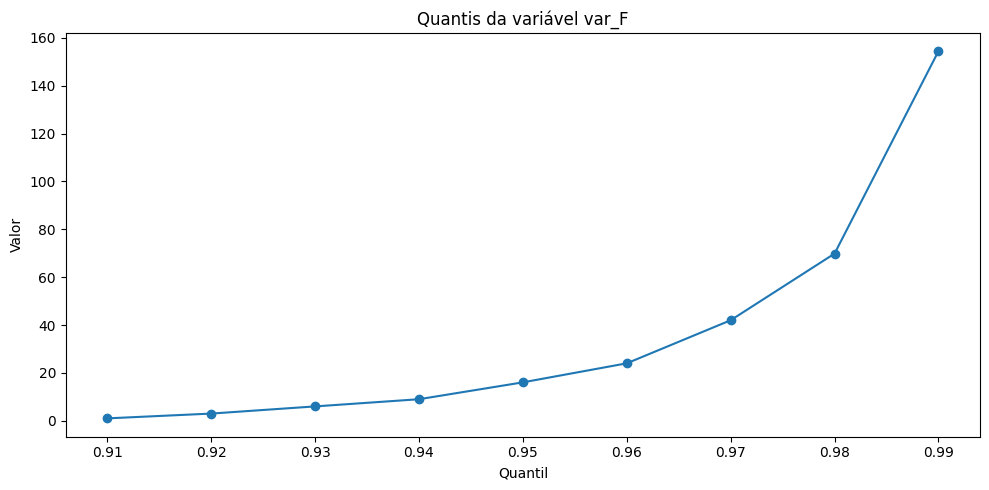

In [ ]:
quantil = base['var_F'].quantile([0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
plt.figure(figsize=(10, 5))
plt.plot(quantil.index, quantil.values, marker='o', linestyle='-')
plt.title("Quantis da variável var_F")
plt.xlabel("Quantil")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

### Variável G

In [ ]:
base['var_G'].describe()

,var_G
count,16880.000000
mean,1.439842
std,19.347937
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,667.000000


In [ ]:
base['var_G'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

,var_G
0.1,0.0
0.2,0.0
0.3,0.0
0.4,0.0
0.5,0.0
0.6,0.0
0.7,0.0
0.8,0.0
0.9,0.0


In [ ]:
base['var_G'].quantile([0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999])

,var_G
0.991,28.000
0.992,33.000
0.993,41.847
0.994,61.726
0.995,78.000
0.996,111.000
0.997,143.363
0.998,215.936
0.999,333.000


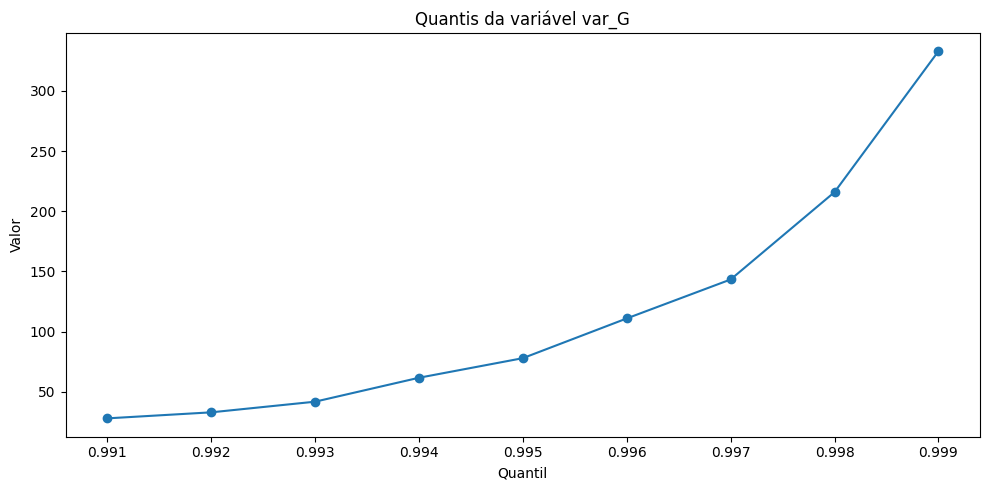

In [ ]:
quantil = base['var_G'].quantile([0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999])
plt.figure(figsize=(10, 5))
plt.plot(quantil.index, quantil.values, marker='o', linestyle='-')
plt.title("Quantis da variável var_G")
plt.xlabel("Quantil")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

### Variável K

In [ ]:
base['var_K'].describe()

,var_K
count,4016.000000
mean,0.682099
std,0.153264
min,0.120000
25%,0.580000
50%,0.680000
75%,0.800000
max,0.990000


In [ ]:
base['var_K'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

,var_K
0.1,0.49
0.2,0.55
0.3,0.60
0.4,0.64
0.5,0.68
0.6,0.73
0.7,0.77
0.8,0.82
0.9,0.88


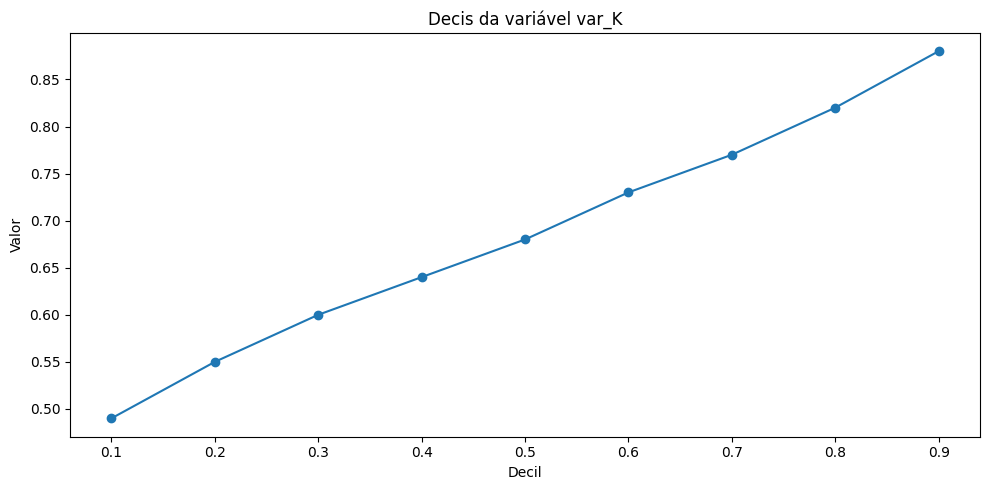

In [ ]:
decis = base['var_K'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.figure(figsize=(10, 5))
plt.plot(decis.index, decis.values, marker='o', linestyle='-')
plt.title("Decis da variável var_K")
plt.xlabel("Decil")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

## Variáveis "Problemáticas"

As variáveis que tiveram uma análise adicional devem ser transformadas.

As variáveis que seus decis/quantis crescem exponencialmente, serão transformadas em log(var), buscando atenuar a distribuição assimétrica e altamente concentrada em valores baixos (var_C, var_F e var_G). No entanto, não vemos isso na variável var_K.

# Análise exploratória de Variáveis "Categóricas"

Análise das variáveis classificadas como OBJECT na base inicial.

Avaliar a Relação com a Target.

In [ ]:
# cat_col = ['var_J', 'var_Q', 'var_R', "var_S"]
# for k in cat_col:
#   print(k)
#   plot_distribuicao_target(base, k, 'Fraude')
#   plotar_percentual_por_categoria(base, k, 'Fraude')
#   plot_distribuicao(base, k)

## Variável J

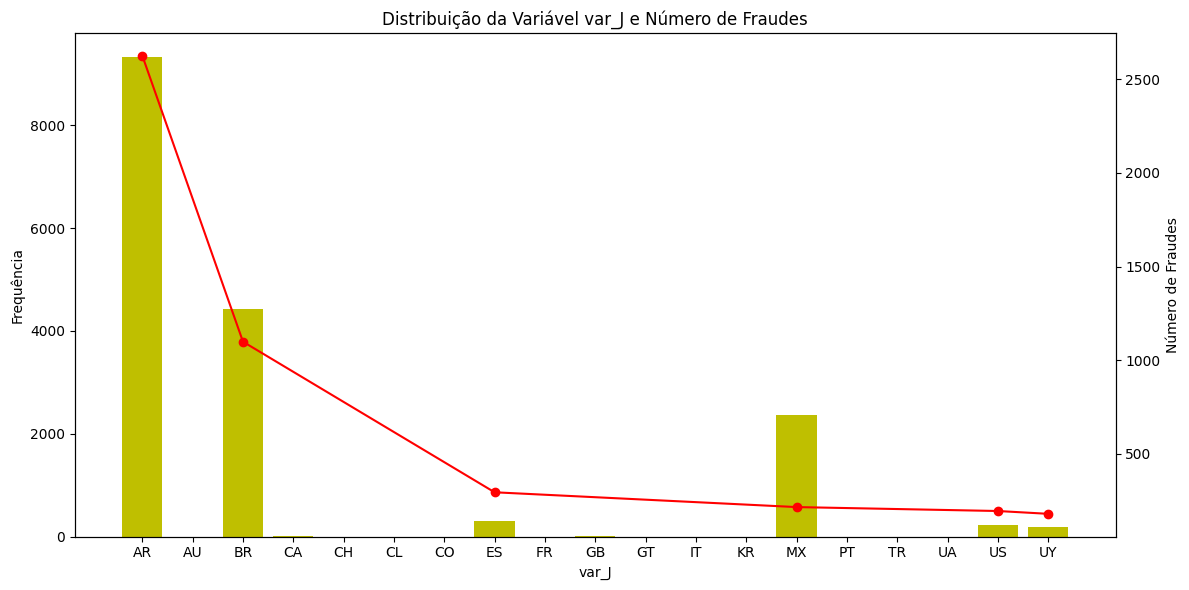

In [ ]:
plot_distribuicao_target(base, 'var_J', 'Fraude')

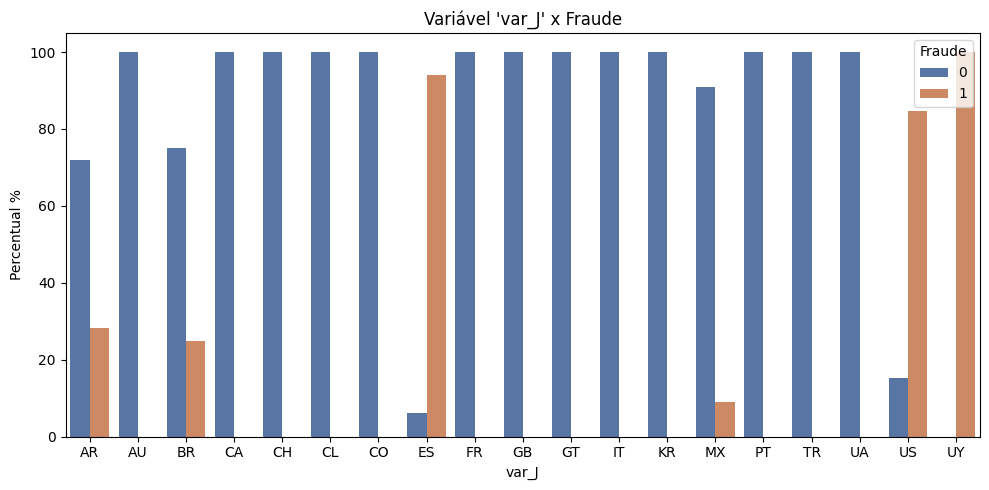

In [ ]:
plotar_percentual_por_categoria(base, 'var_J', 'Fraude')

In [ ]:
base.groupby('var_J').count().sort_index()['Fraude']

,Fraude
var_J,
AR,9329
AU,1
BR,4428
CA,12
CH,1
CL,1
CO,1
ES,314
FR,2


In [ ]:
var_J_fraud = (base.groupby('var_J')['Fraude'].mean() * 100)
var_J_fraud

,Fraude
var_J,
AR,28.148783
AU,0.000000
BR,24.819332
CA,0.000000
CH,0.000000
CL,0.000000
CO,0.000000
ES,93.949045
FR,0.000000


In [ ]:
base[['var_Q', 'var_R', 'var_S', 'Fraude']]

,var_Q,var_R,var_S,Fraude
0,0.00,0.00,7.25,1
1,0.00,0.00,11.66,1
2,0.00,0.00,86.97,1
3,0.00,0.00,2.51,1
4,0.00,0.00,25.96,1
...,...,...,...,...
16875,0.00,0.00,85.73,1
16876,0.00,0.00,12.50,1
16877,0.00,0.00,24.16,1
16878,0.00,0.00,29.00,1


## Variável Q

In [ ]:
datetime_qtd = base[base["var_Q"].apply(lambda x: isinstance(x, datetime))][["var_Q", 'Fraude']]
str_qtd = base[base["var_Q"].apply(lambda x: isinstance(x, str))][["var_Q", 'Fraude']]
int_float_qtd = base[base["var_Q"].apply(lambda x: isinstance(x, int))]["var_Q"] + base[base["var_Q"].apply(lambda x: isinstance(x, float))][["var_Q", 'Fraude']][["var_Q", 'Fraude']]

In [ ]:
datetime_qtd

,var_Q,Fraude
270,2021-11-15 00:00:00,1
392,2021-12-16 00:00:00,1
583,2021-04-29 00:00:00,1
2221,2021-10-24 00:00:00,1
4272,2021-10-21 00:00:00,0
5010,2021-09-22 00:00:00,0
5657,2021-05-19 00:00:00,0
6092,2021-05-14 00:00:00,0
7813,2021-05-29 00:00:00,0
8635,2021-11-29 00:00:00,0


In [ ]:
str_qtd

,var_Q,Fraude
0,0.00,1
1,0.00,1
2,0.00,1
3,0.00,1
4,0.00,1
...,...,...
16875,0.00,1
16876,0.00,1
16877,0.00,1
16878,0.00,1


In [ ]:
int_float_qtd

,Fraude,var_Q


In [ ]:
datetime_qtd.shape, str_qtd.shape, int_float_qtd.shape

((17, 2), (16863, 2), (0, 2))

A variável Q na verdade é uma variável numérica

## Variável R

In [ ]:
datetime_qtd = base[base["var_R"].apply(lambda x: isinstance(x, datetime))][["var_R", 'Fraude']]
str_qtd = base[base["var_R"].apply(lambda x: isinstance(x, str))][["var_R", 'Fraude']]
int_float_qtd = base[base["var_R"].apply(lambda x: isinstance(x, int))]["var_R"] + base[base["var_R"].apply(lambda x: isinstance(x, float))][["var_R", 'Fraude']][["var_R", 'Fraude']]

In [ ]:
datetime_qtd

,var_R,Fraude
2374,2021-08-15 00:00:00,1
3831,2021-02-18 00:00:00,1
9308,2021-01-19 00:00:00,0


In [ ]:
str_qtd

,var_R,Fraude
0,0.00,1
1,0.00,1
2,0.00,1
3,0.00,1
4,0.00,1
...,...,...
16875,0.00,1
16876,0.00,1
16877,0.00,1
16878,0.00,1


In [ ]:
int_float_qtd

,Fraude,var_R


A variável R na verdade é uma variável numérica

## Variável S

In [ ]:
datetime_qtd = base[base["var_S"].apply(lambda x: isinstance(x, datetime))][["var_S", 'Fraude']]
str_qtd = base[base["var_S"].apply(lambda x: isinstance(x, str))][["var_S", 'Fraude']]
int_float_qtd = base[base["var_S"].apply(lambda x: isinstance(x, int))]["var_S"] + base[base["var_S"].apply(lambda x: isinstance(x, float))][["var_S", 'Fraude']][["var_S", 'Fraude']]

In [ ]:
datetime_qtd

,var_S,Fraude
13,2021-11-12 00:00:00,1
19,2021-03-19 00:00:00,1
26,2021-09-13 00:00:00,1
36,2021-09-23 00:00:00,1
43,2021-06-03 00:00:00,1
...,...,...
16668,2021-09-21 00:00:00,1
16685,2021-05-14 00:00:00,1
16699,2021-02-11 00:00:00,1
16712,2021-02-06 00:00:00,1


In [ ]:
str_qtd

,var_S,Fraude
0,7.25,1
1,11.66,1
2,86.97,1
3,2.51,1
4,25.96,1
...,...,...
16875,85.73,1
16876,12.50,1
16877,24.16,1
16878,29.00,1


In [ ]:
int_float_qtd

,Fraude,var_S


A variável S na verdade é uma variável numérica

## Monto

In [ ]:
datetime_qtd = base[base["Monto"].apply(lambda x: isinstance(x, datetime))][["Monto", 'Fraude']]
str_qtd = base[base["Monto"].apply(lambda x: isinstance(x, str))][["Monto", 'Fraude']]
int_float_qtd = base[base["Monto"].apply(lambda x: isinstance(x, int))]["Monto"] + base[base["Monto"].apply(lambda x: isinstance(x, float))][["Monto", 'Fraude']][["Monto", 'Fraude']]

In [ ]:
datetime_qtd

,Monto,Fraude
34,2021-11-20 00:00:00,1
84,2021-10-10 00:00:00,1
106,2021-10-20 00:00:00,1
114,2021-07-26 00:00:00,1
115,2021-02-25 00:00:00,1
...,...,...
16781,2021-04-30 00:00:00,1
16814,2021-10-27 00:00:00,1
16822,2021-05-18 00:00:00,1
16833,2021-10-27 00:00:00,1


In [ ]:
str_qtd

,Monto,Fraude
0,37.51,1
1,8.18,1
2,13.96,1
3,93.67,1
4,135.40,1
...,...,...
16875,132.17,1
16876,26.34,1
16877,195.63,1
16878,36.97,1


In [ ]:
int_float_qtd

,Fraude,Monto


# Base de Modelagem Final - Tratamentos

Passar de string para floatt as variáveis Q, R, S e Monto. Cuidado com o separador de milhar.
Aplicar log nas variáveis C, F e G que possuem a maioria da sua marcação como zero, no entanto, quando começam a ter marcação, as marcações tem crescimento exponencial identificado.

In [ ]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})

In [ ]:
variaveis = ["var_Q", "var_R", "var_S", 'Monto']

for col in variaveis:
    base[col] = base[col].apply(lambda x: np.nan if isinstance(x, datetime) else x)

    base[col] = base[col].astype(str).str.replace(",", "").str.replace(" ", "").replace("None", np.nan)
    base[col] = pd.to_numeric(base[col], errors='coerce')

In [ ]:
for col in ["var_C", "var_F", "var_G"]:
    base[f"{col}_log"] = np.log1p(base[col])

In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var_A      16880 non-null  int64  
 1   var_B      16880 non-null  int64  
 2   var_C      13683 non-null  float64
 3   var_D      16880 non-null  int64  
 4   var_E      16880 non-null  int64  
 5   var_F      16880 non-null  float64
 6   var_G      16880 non-null  float64
 7   var_H      16880 non-null  int64  
 8   var_I      16880 non-null  int64  
 9   var_J      16880 non-null  object 
 10  var_K      4016 non-null   float64
 11  var_L      16880 non-null  int64  
 12  var_M      16880 non-null  int64  
 13  var_N      16880 non-null  int64  
 14  var_O      16880 non-null  int64  
 15  var_P      16880 non-null  int64  
 16  var_Q      16863 non-null  float64
 17  var_R      16877 non-null  float64
 18  var_S      15575 non-null  float64
 19  Monto      16413 non-null  float64
 20  Fraude

In [ ]:
base.describe()

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_K,...,var_O,var_P,var_Q,var_R,var_S,Monto,Fraude,var_C_log,var_F_log,var_G_log
count,16880.000000,16880.000000,13683.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000,16880.000000,4016.000000,...,16880.000000,16880.000000,16863.000000,16877.000000,15575.000000,16413.000000,16880.000000,13683.000000,16880.000000,16880.000000
mean,0.309242,7.645379,39235.339984,0.198697,0.433709,5.612705,1.439842,0.050296,0.144076,0.682099,...,0.009419,1.630865,8.431719,1.992188,30.357065,165.838561,0.273164,8.461528,0.293087,0.068807
std,1.094064,4.686494,91045.252879,2.042959,1.537297,37.362389,19.347937,0.531060,0.824761,0.153264,...,0.116606,1.088286,74.403731,38.225326,27.134179,278.351442,0.445597,2.575930,0.994470,0.507503
min,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.120000,...,0.000000,1.000000,0.000000,0.000000,-1.000000,0.050000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.000000,1172.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.580000,...,0.000000,1.000000,0.000000,0.000000,9.855000,36.160000,0.000000,7.067320,0.000000,0.000000
50%,0.000000,7.000000,6173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.680000,...,0.000000,1.000000,0.000000,0.000000,21.680000,85.420000,0.000000,8.728102,0.000000,0.000000
75%,0.000000,11.000000,26888.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,...,0.000000,2.000000,0.000000,0.000000,41.810000,196.530000,1.000000,10.199491,0.000000,0.000000
max,30.000000,20.000000,617324.000000,180.000000,45.000000,667.000000,667.000000,21.000000,24.000000,0.990000,...,3.000000,41.000000,2274.670000,2025.720000,99.970000,12538.440000,1.000000,13.333151,6.504288,6.504288


In [ ]:
base.describe().columns

Index(['var_A', 'var_B', 'var_C', 'var_D', 'var_E', 'var_F', 'var_G', 'var_H',
       'var_I', 'var_K', 'var_L', 'var_M', 'var_N', 'var_O', 'var_P', 'var_Q',
       'var_R', 'var_S', 'Monto', 'Fraude', 'var_C_log', 'var_F_log',
       'var_G_log'],
      dtype='object')

In [ ]:
colunas = ['var_A', 'var_B', 'var_C_log', 'var_D', 'var_E', 'var_F_log', 'var_G_log', 'var_H',
       'var_I', 'var_K', 'var_L', 'var_M', 'var_N', 'var_O', 'var_P', 'var_Q',
       'var_R', 'var_S', 'Monto']

var_A


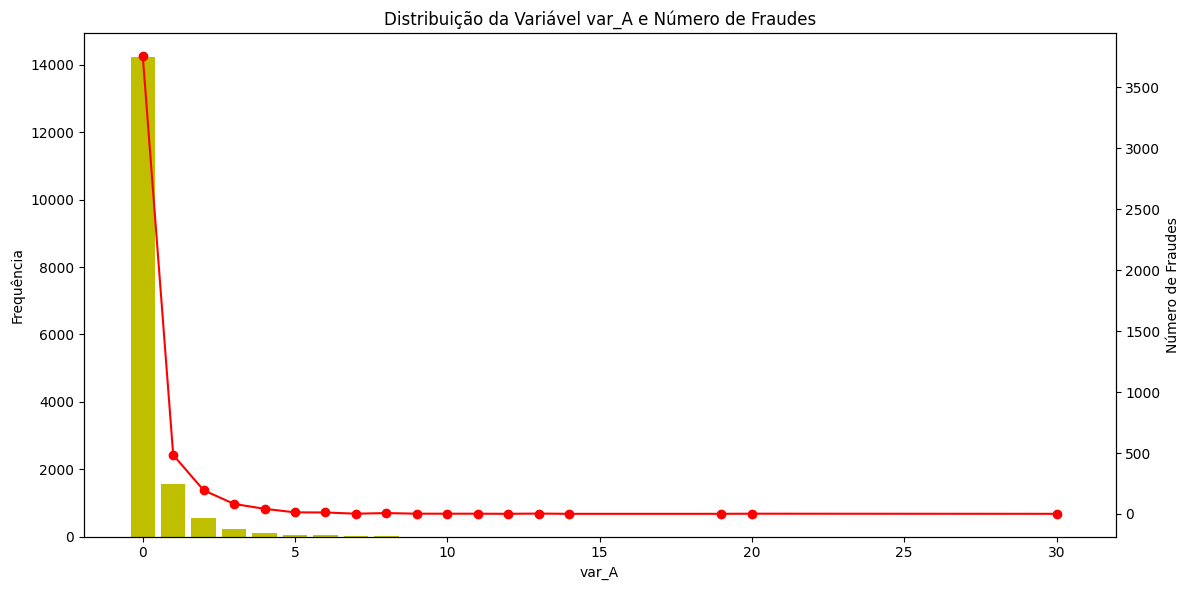

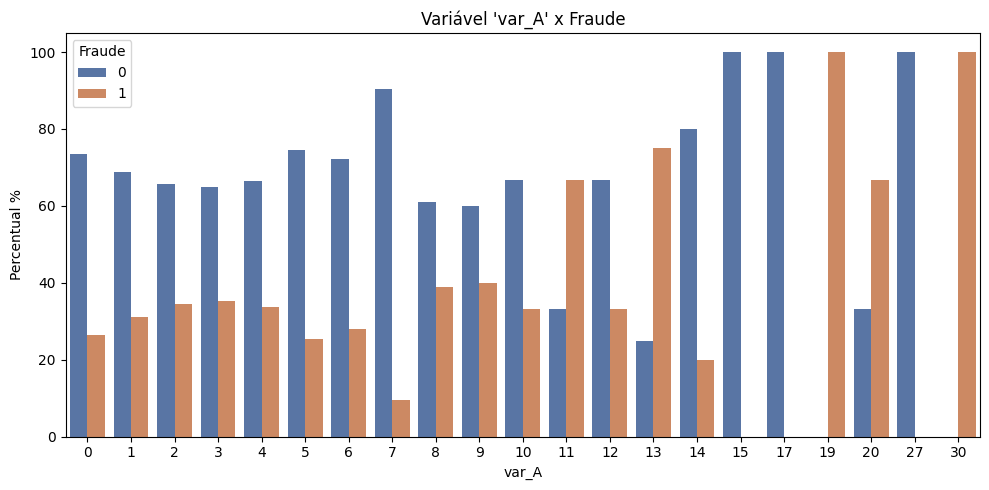

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


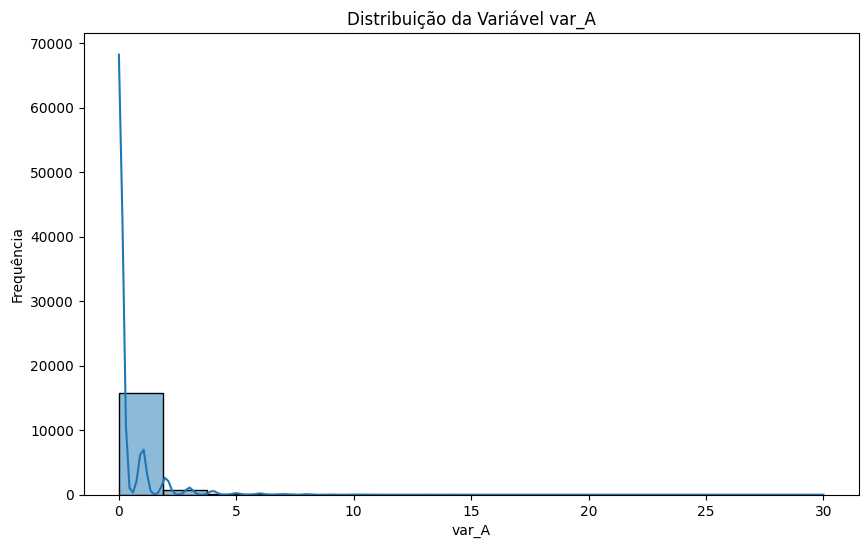

var_B


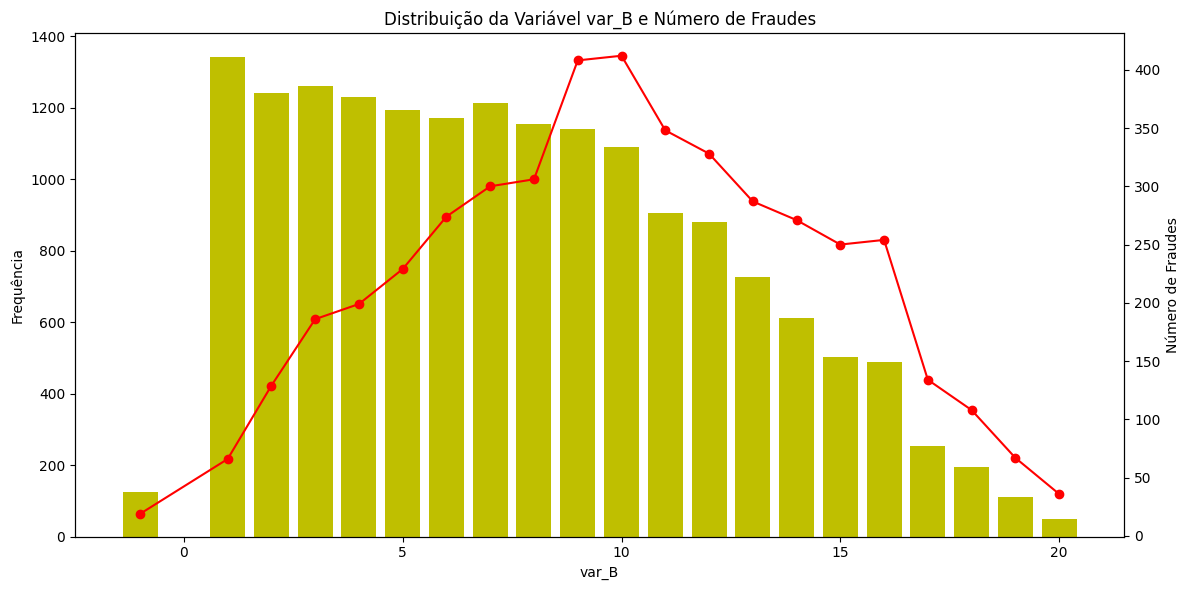

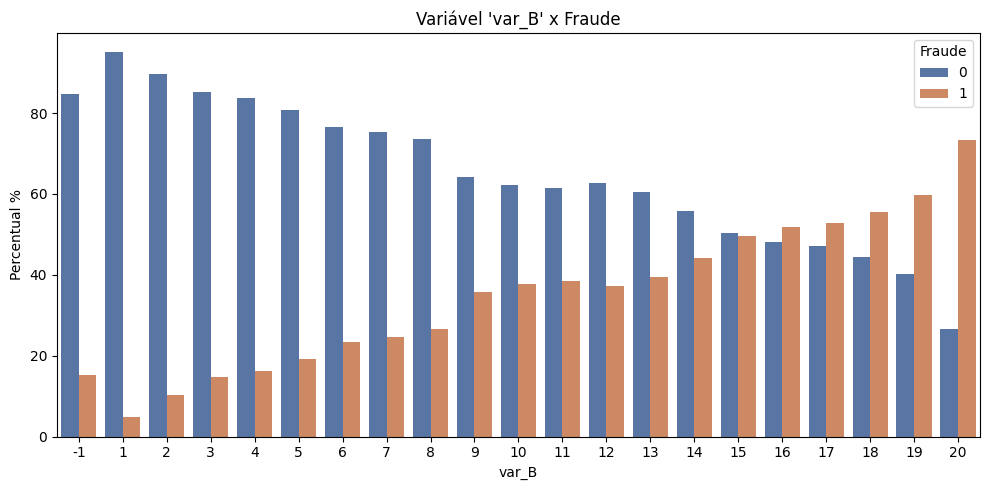

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


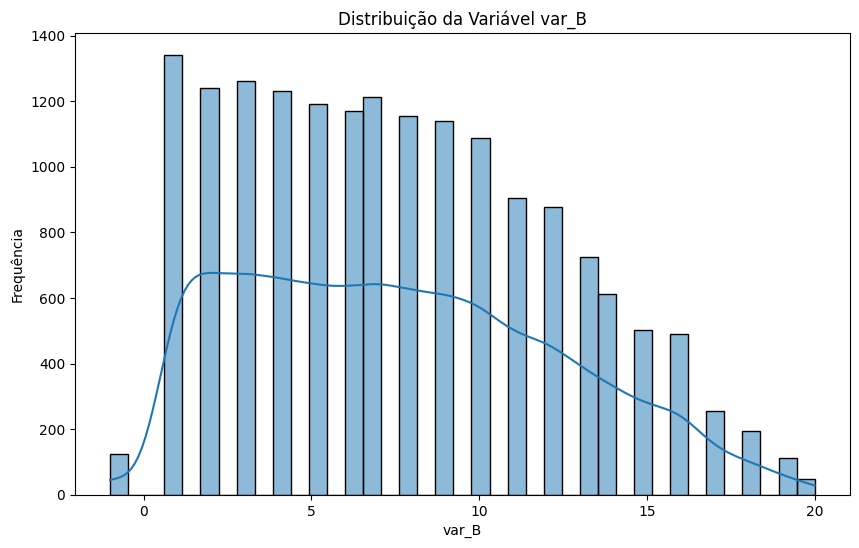

var_C_log


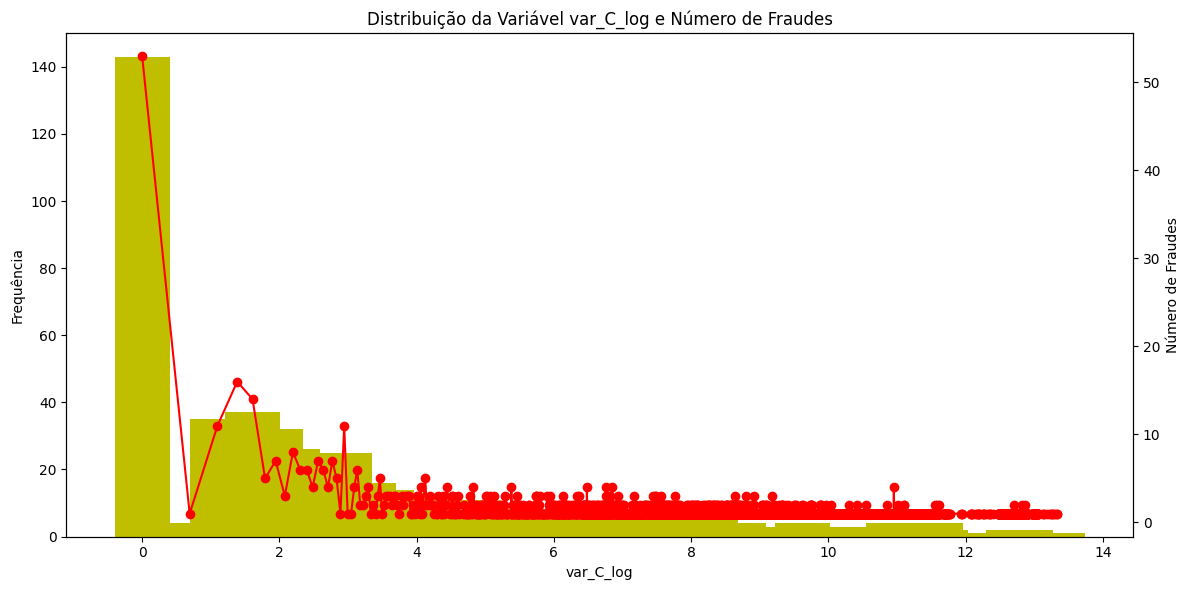

<ipython-input-218-1e83fc71f913>:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


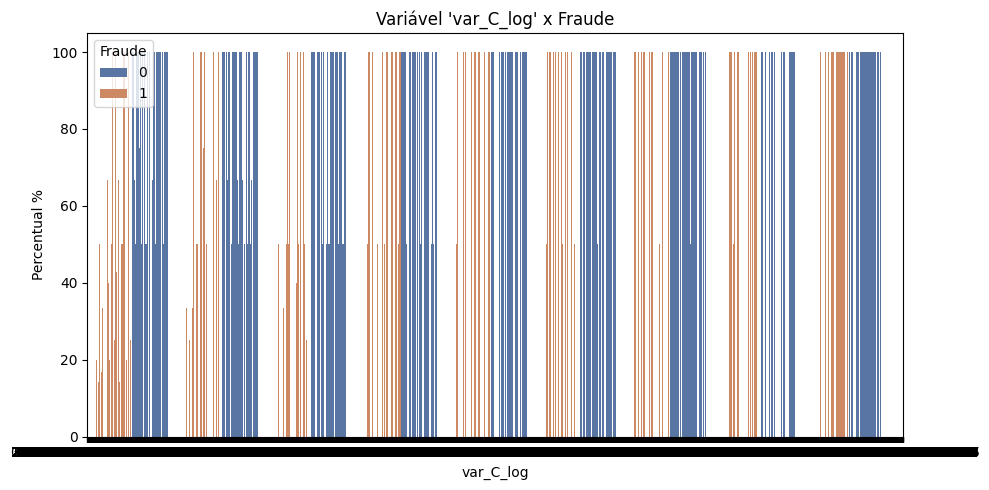

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


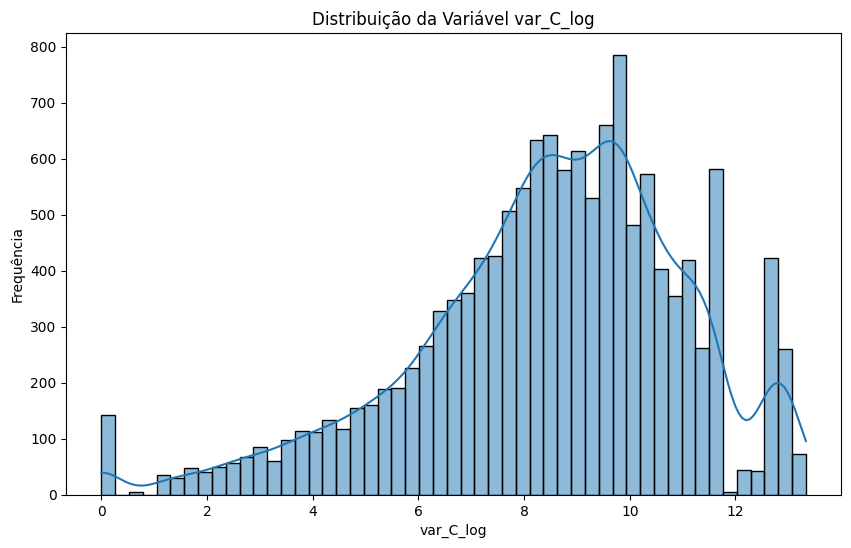

var_D


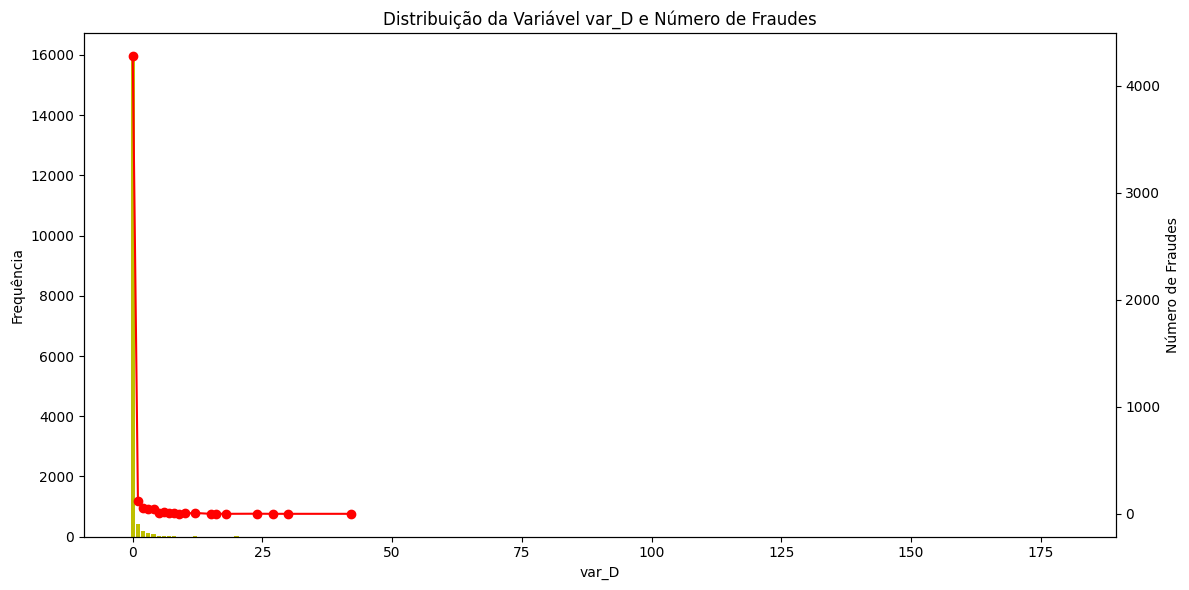

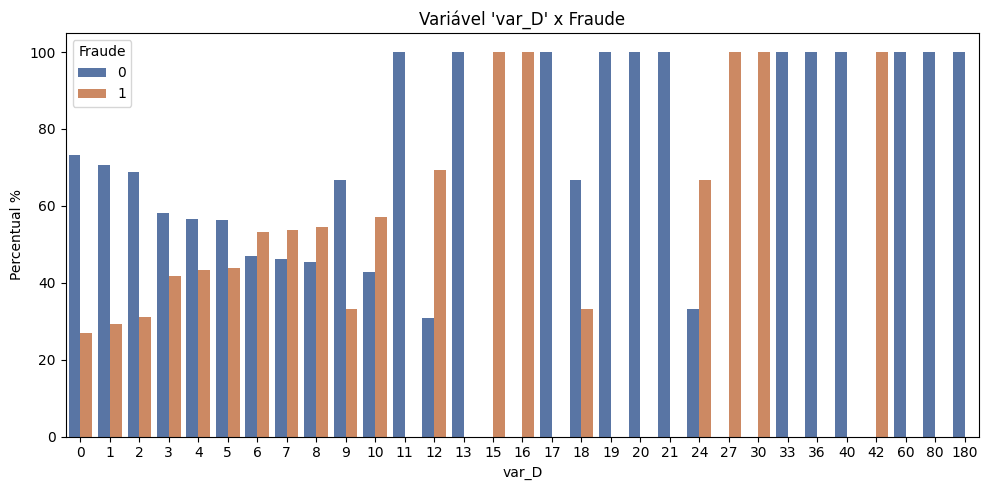

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


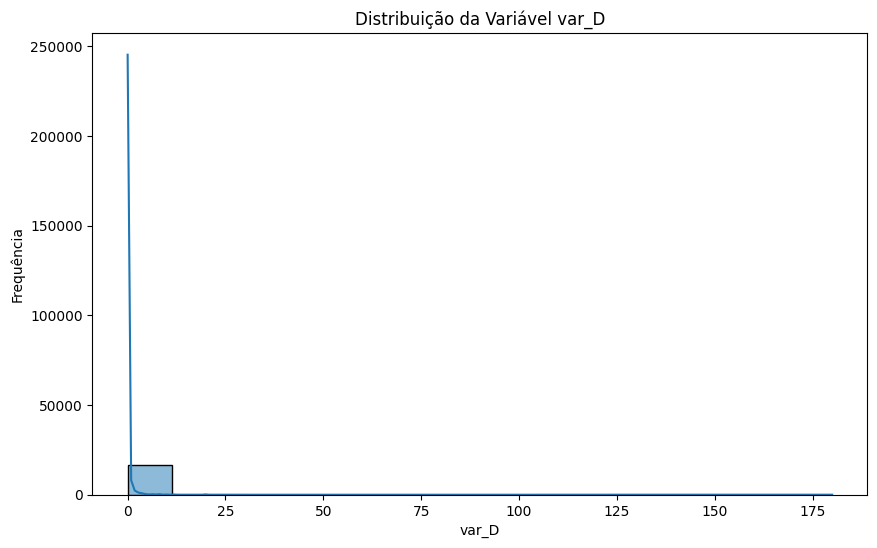

var_E


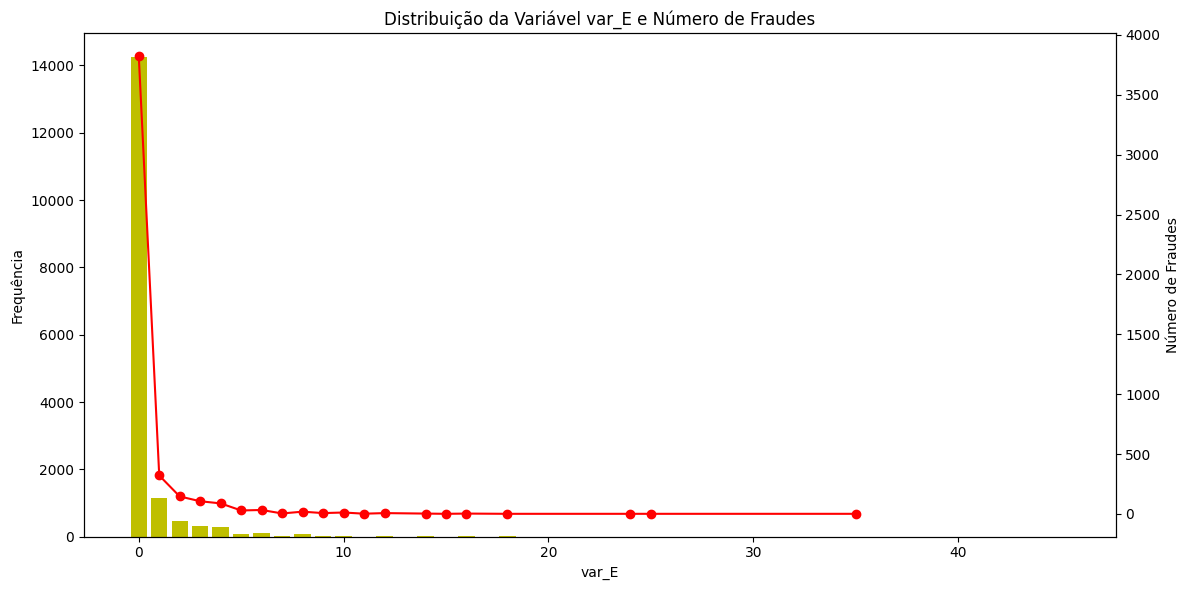

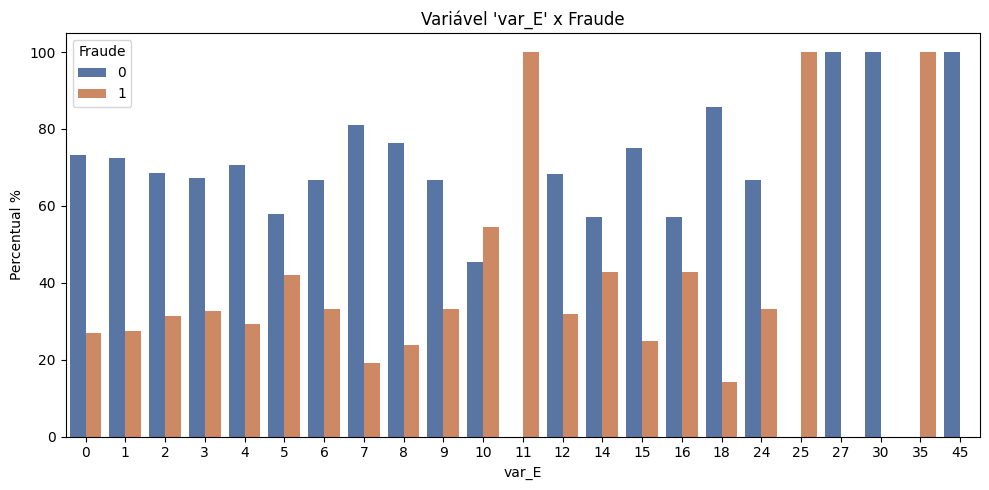

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


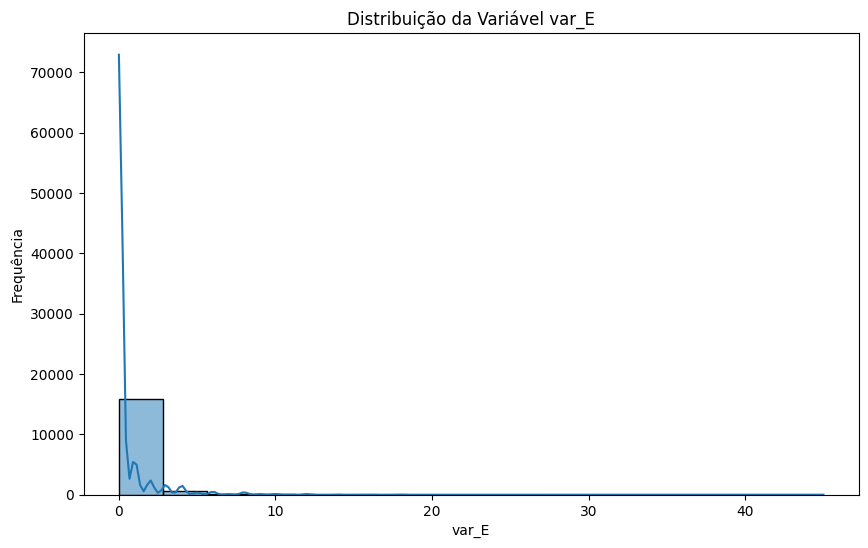

var_F_log


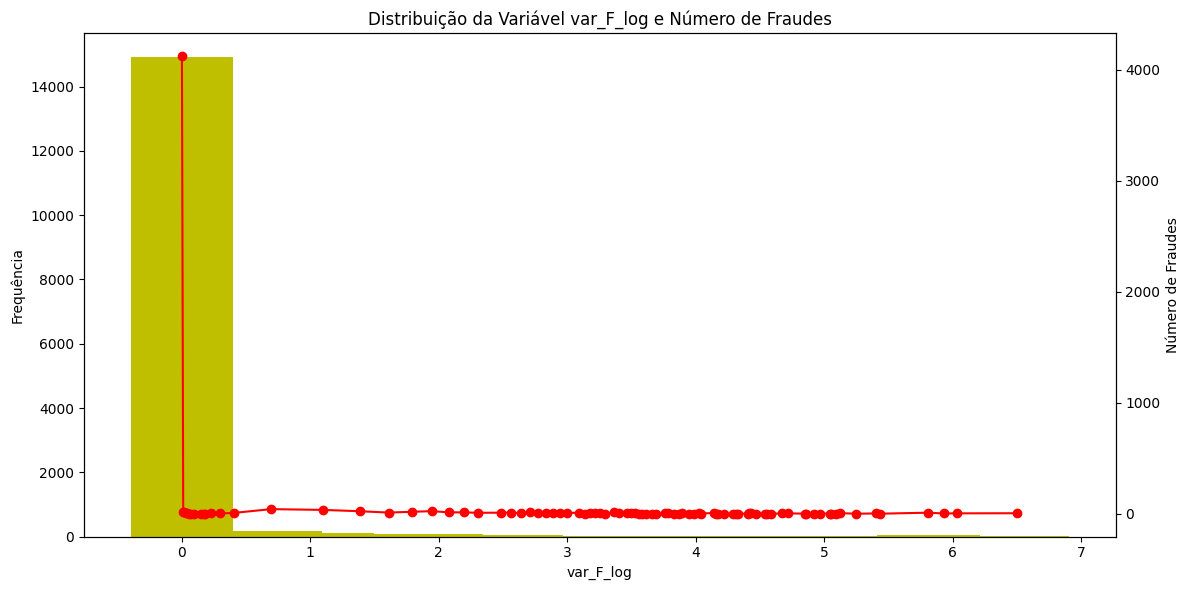

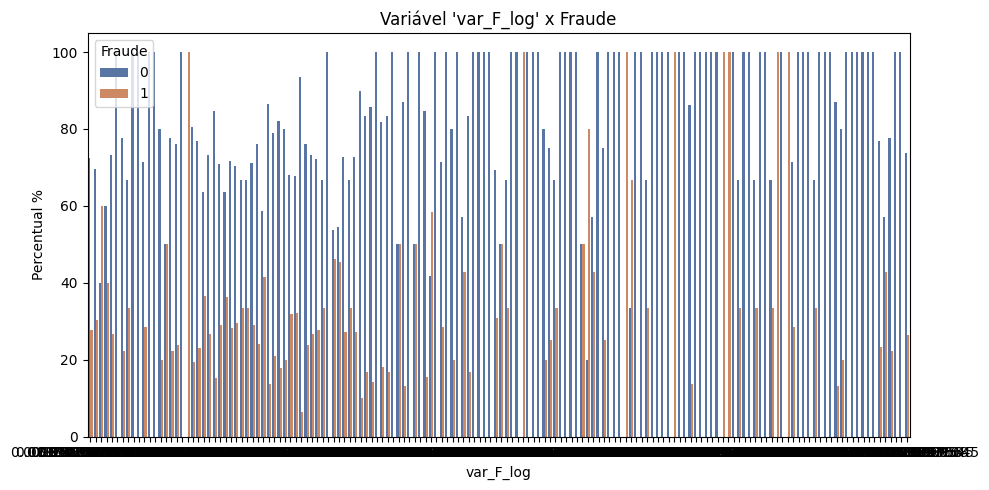

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


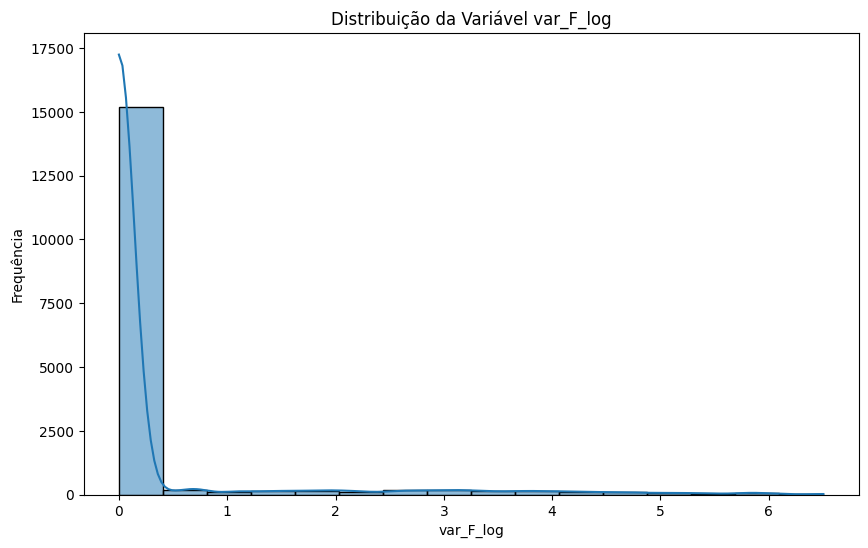

var_G_log


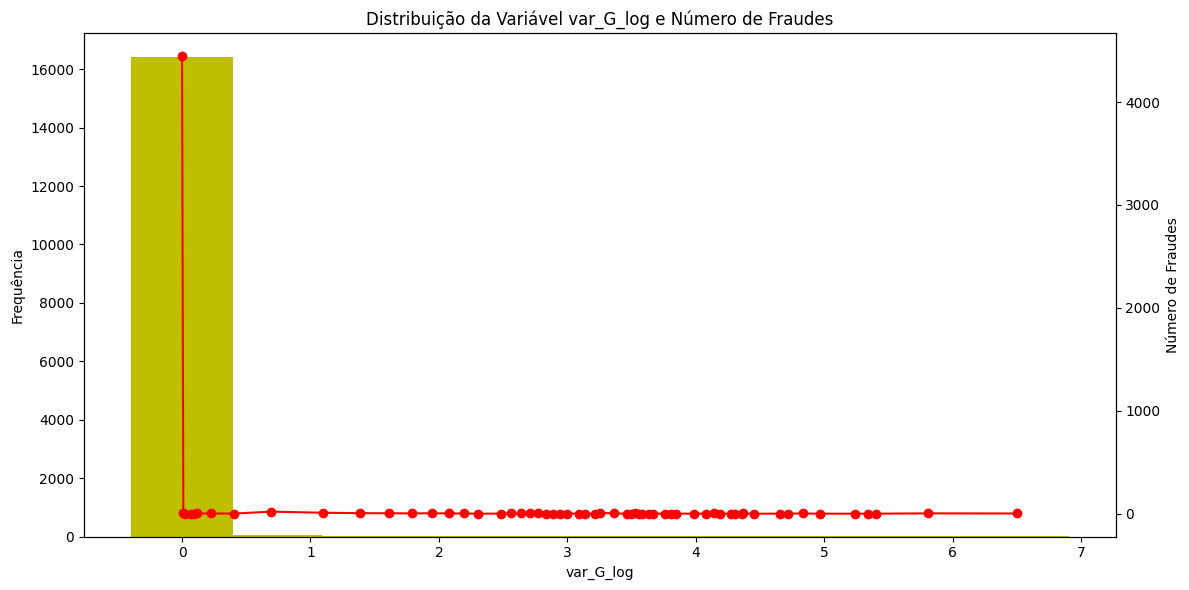

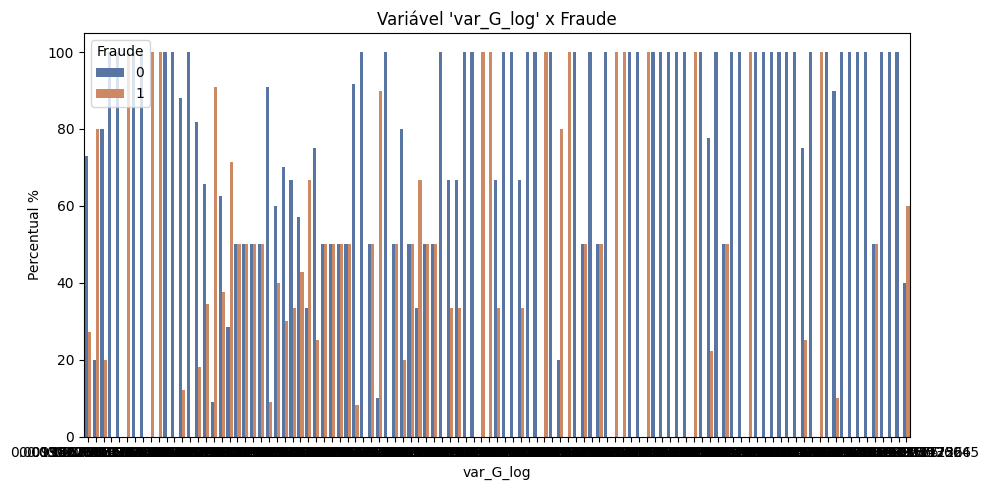

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


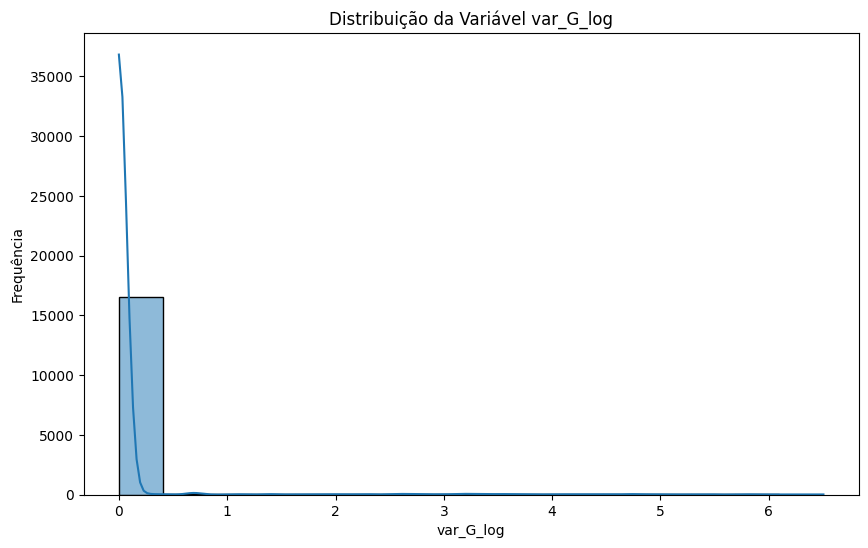

var_H


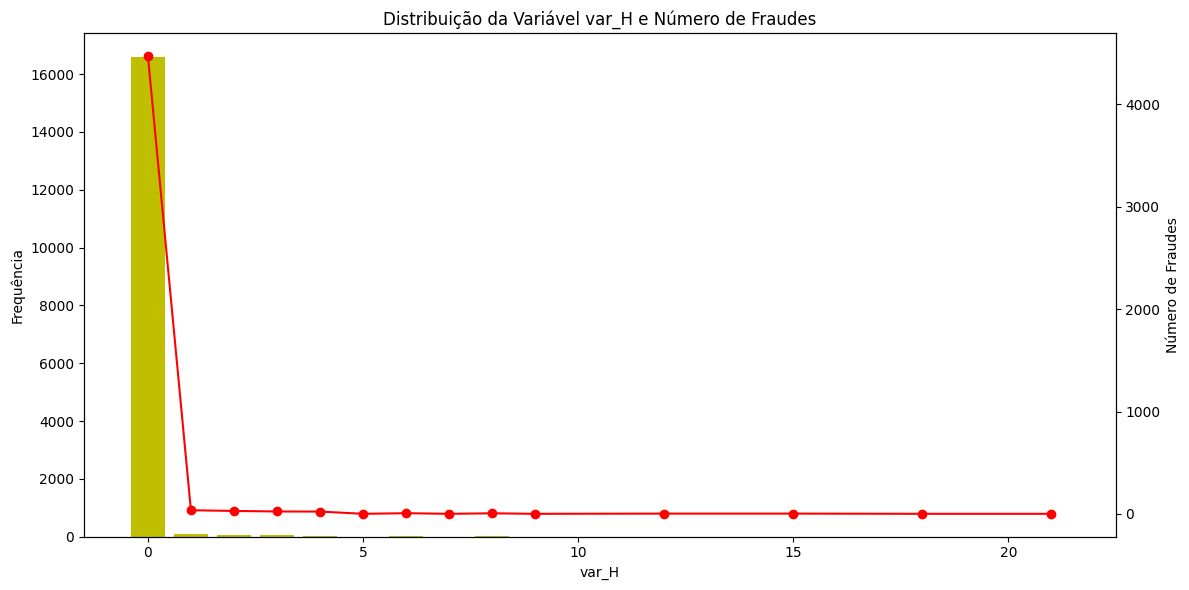

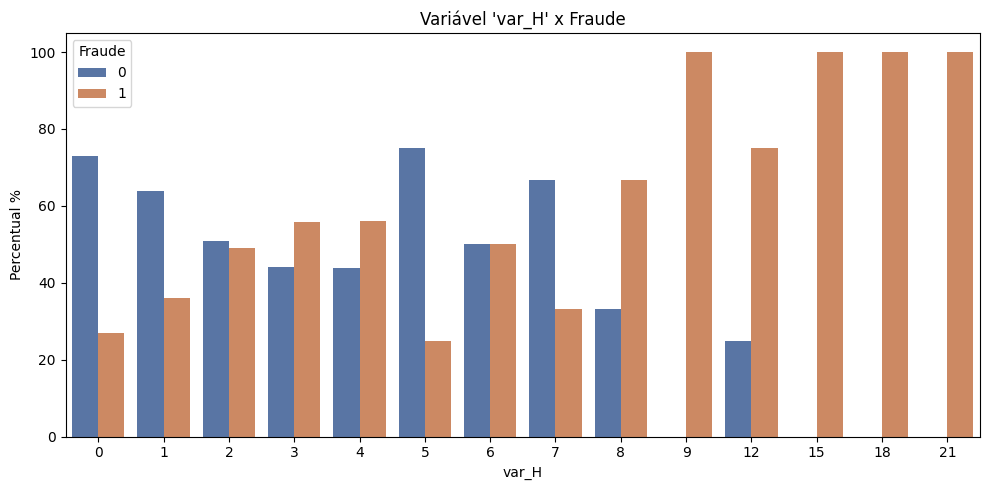

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


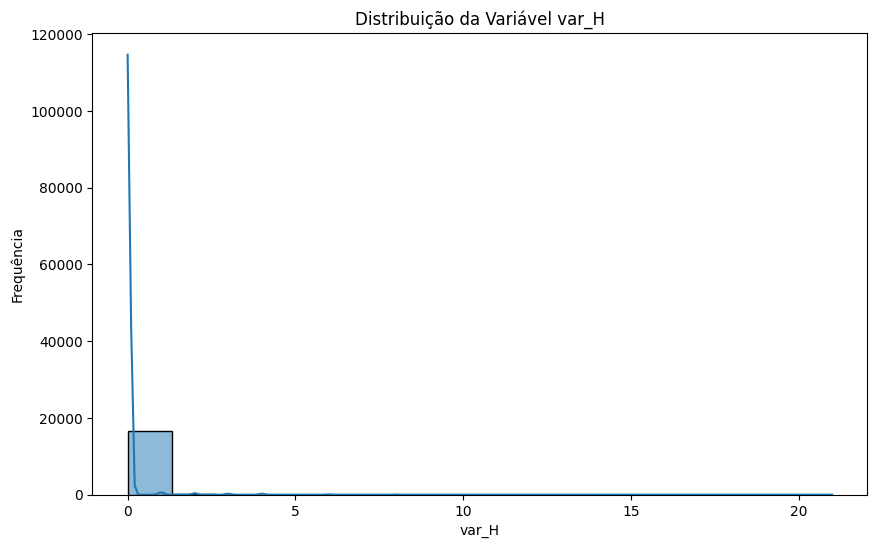

var_I


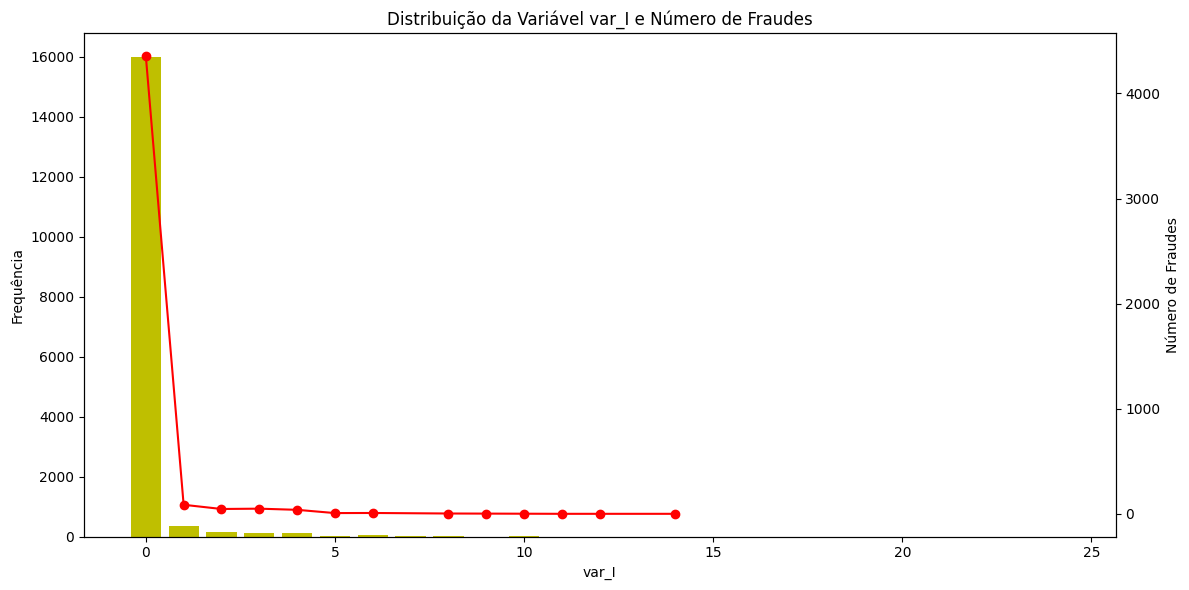

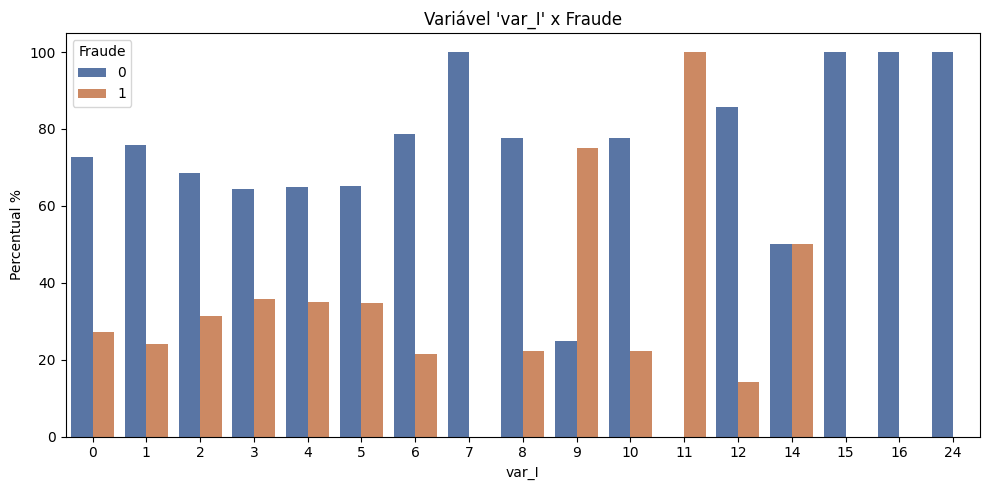

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


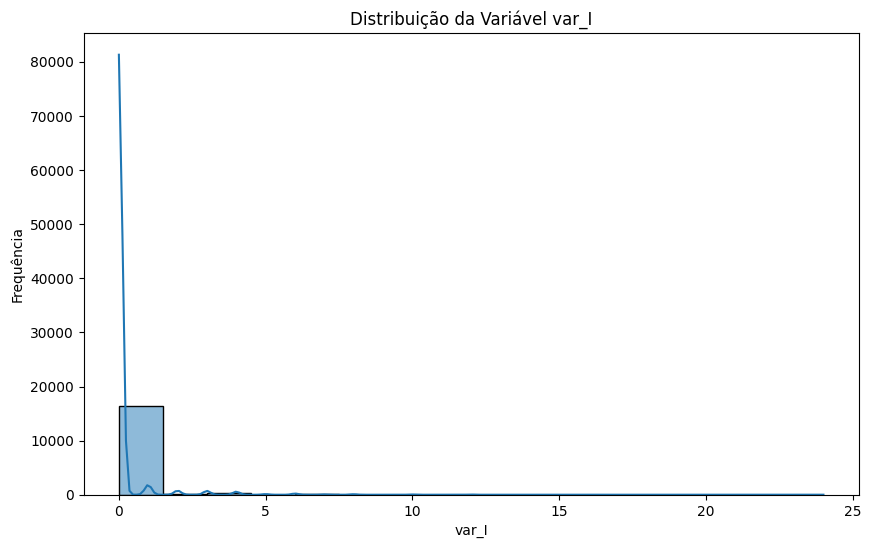

var_K


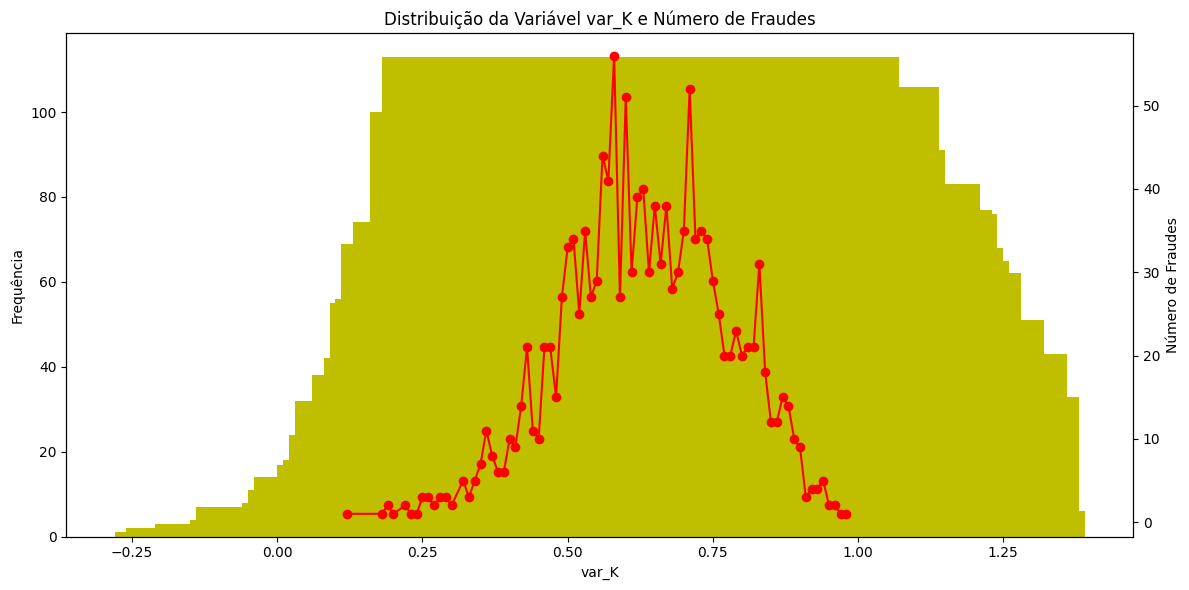

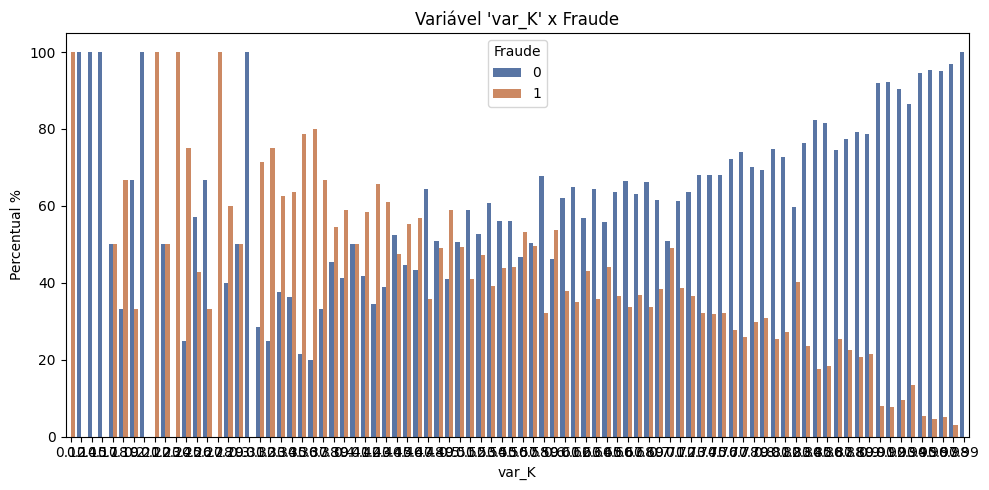

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


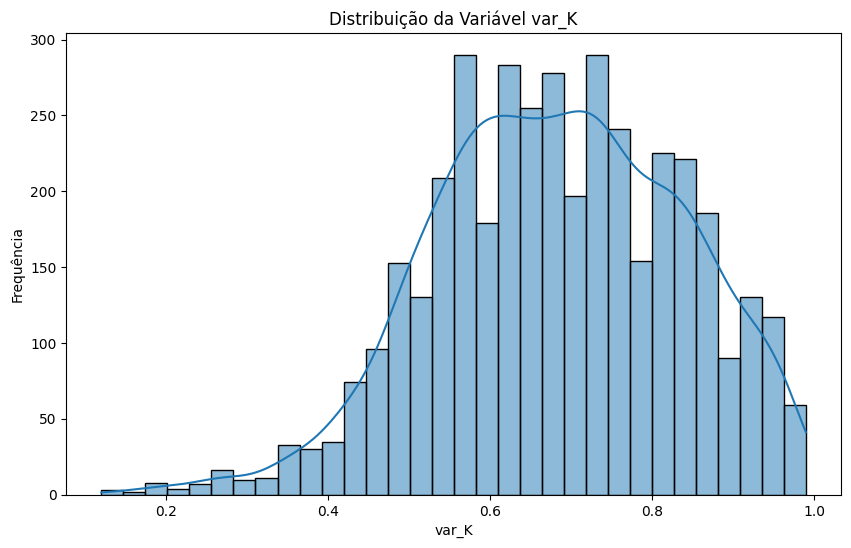

var_L


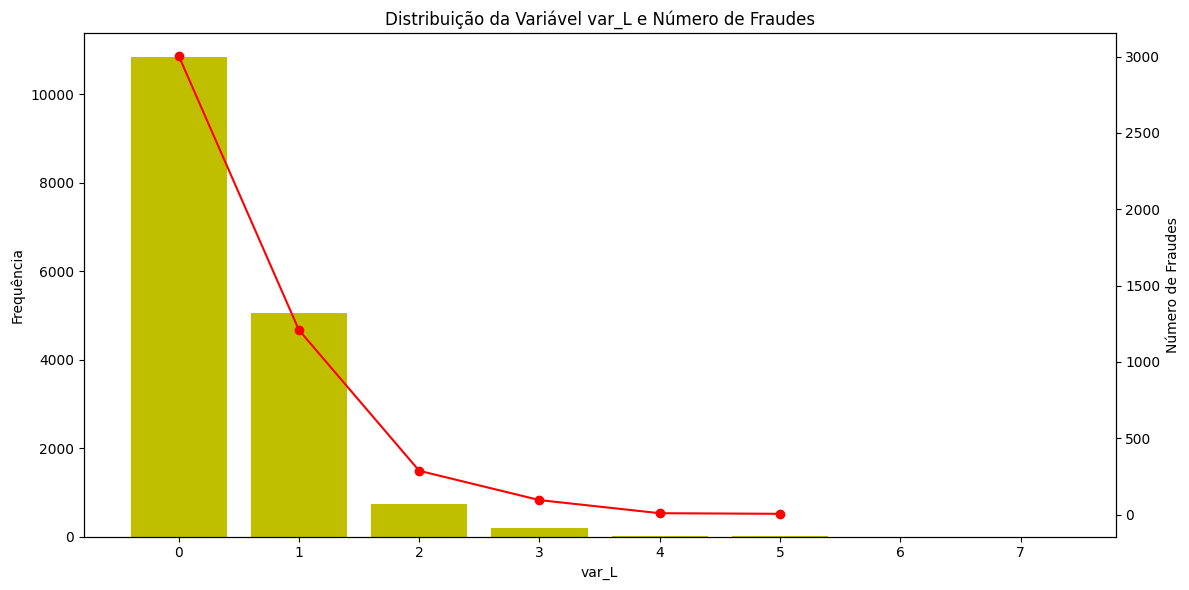

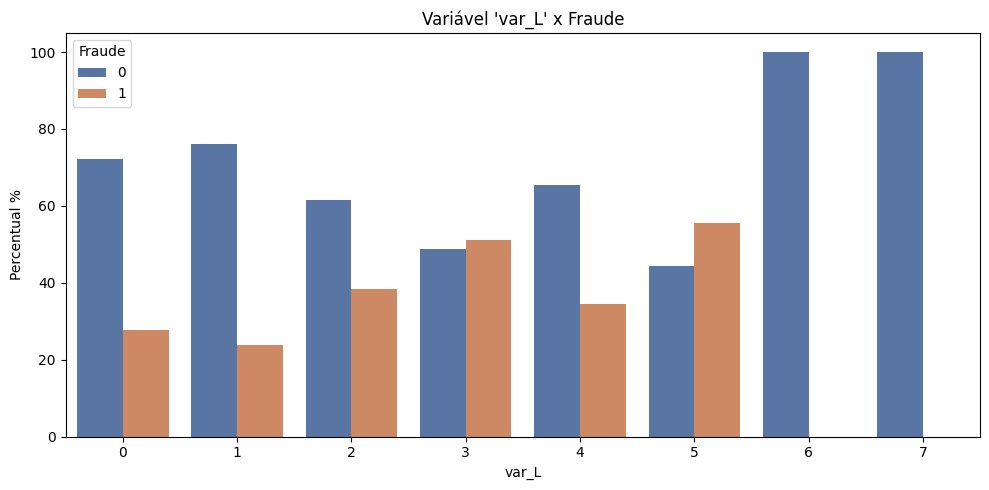

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


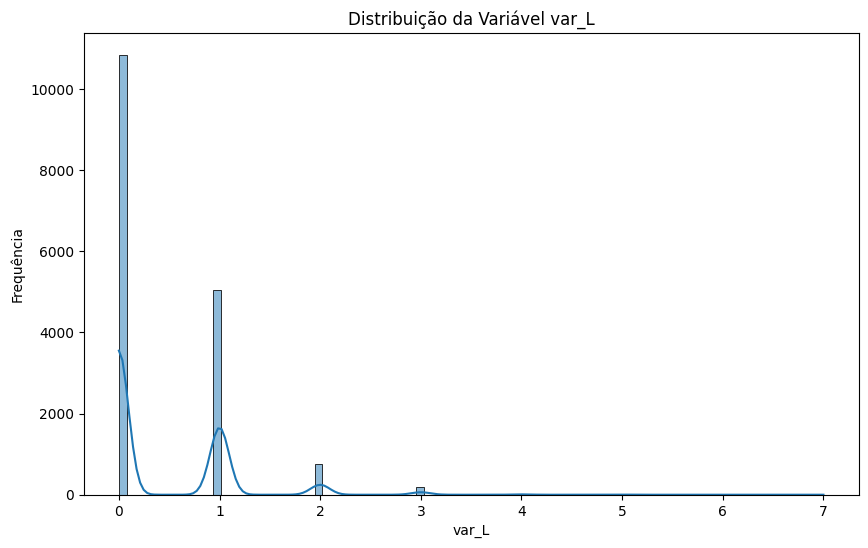

var_M


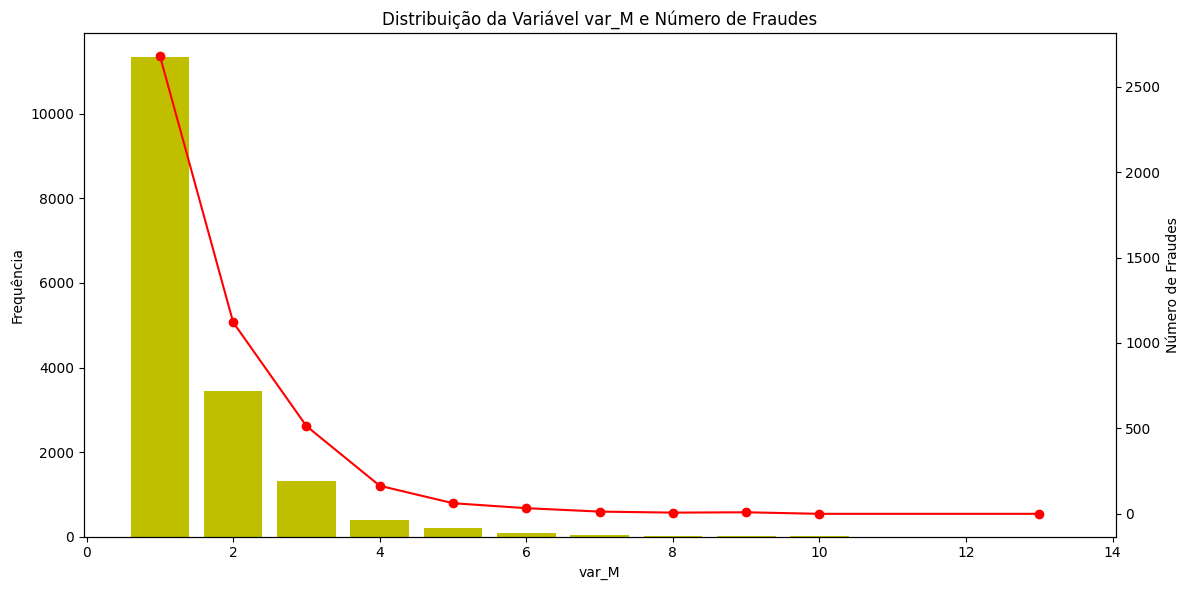

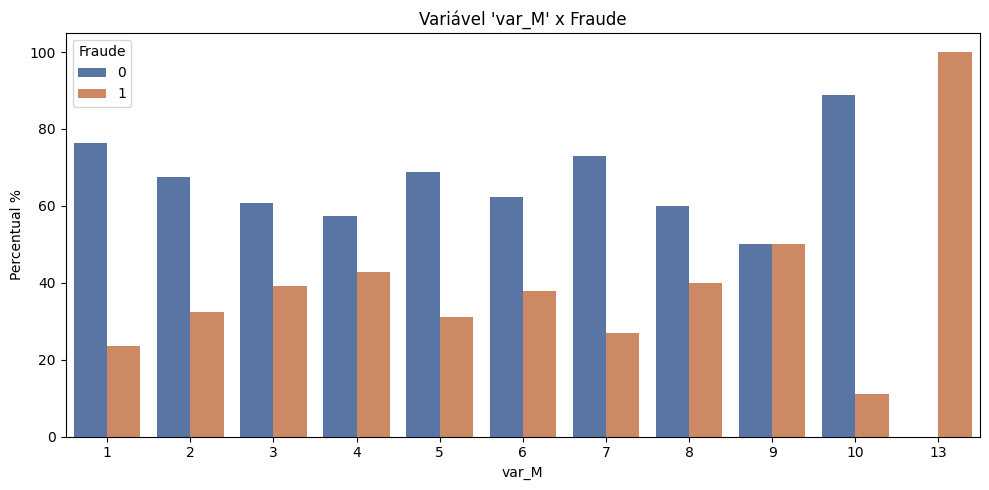

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


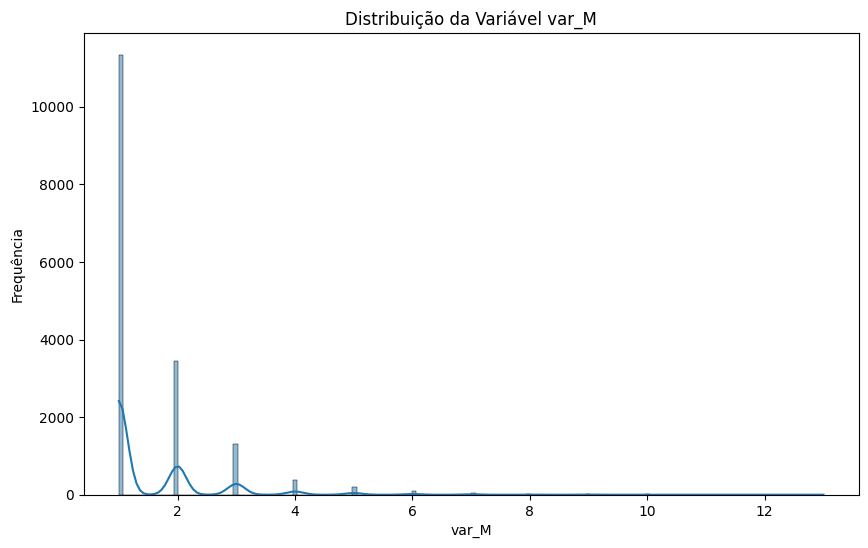

var_N


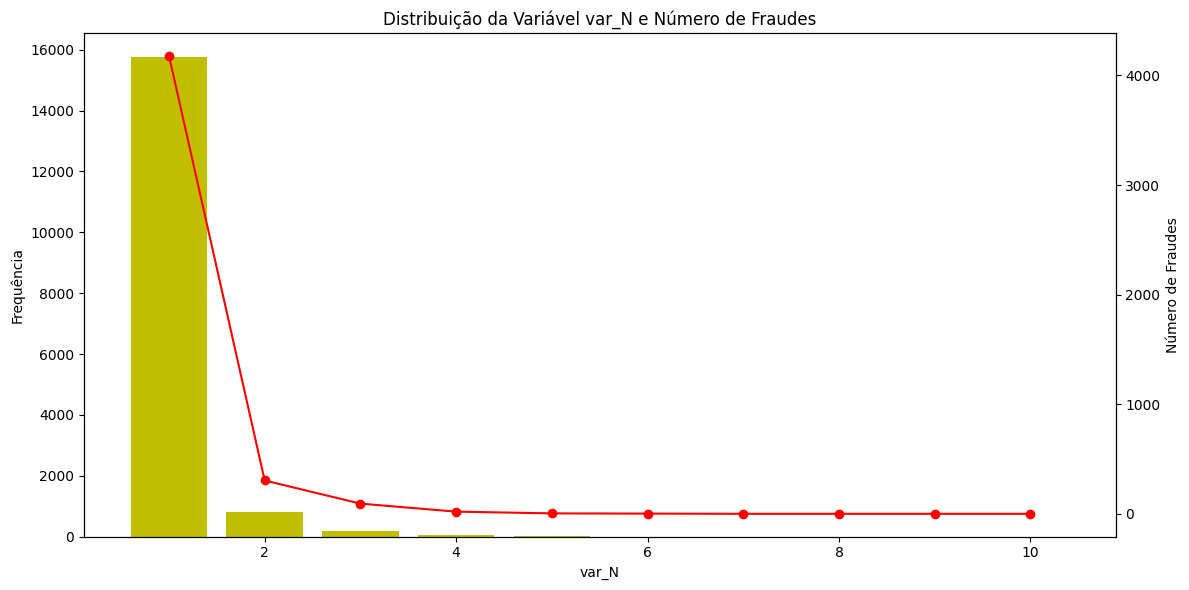

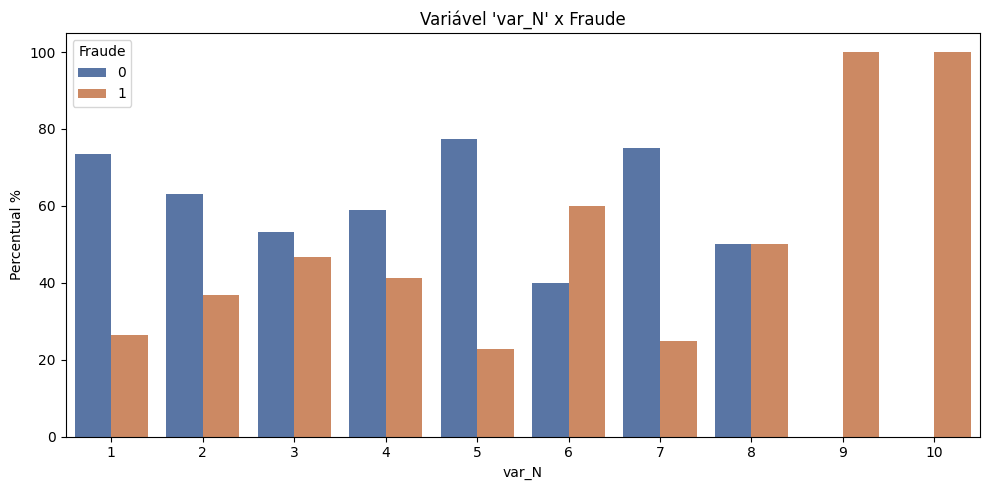

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


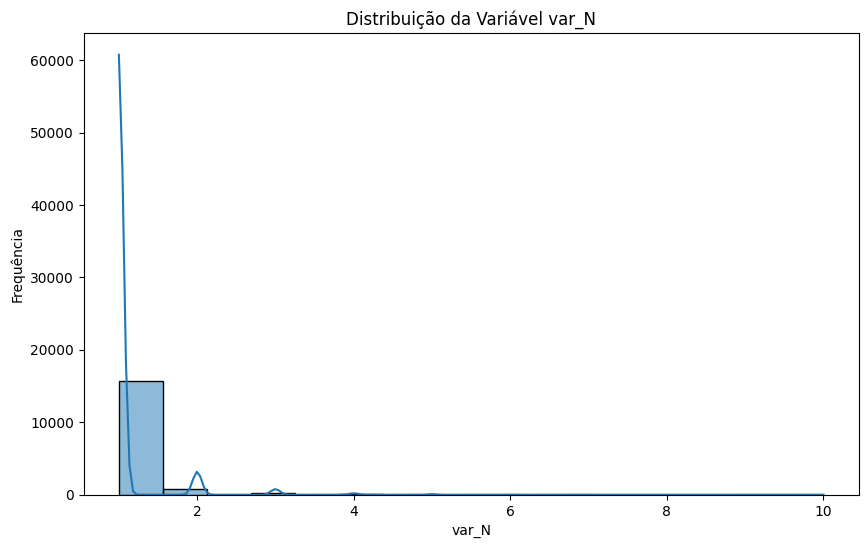

var_O


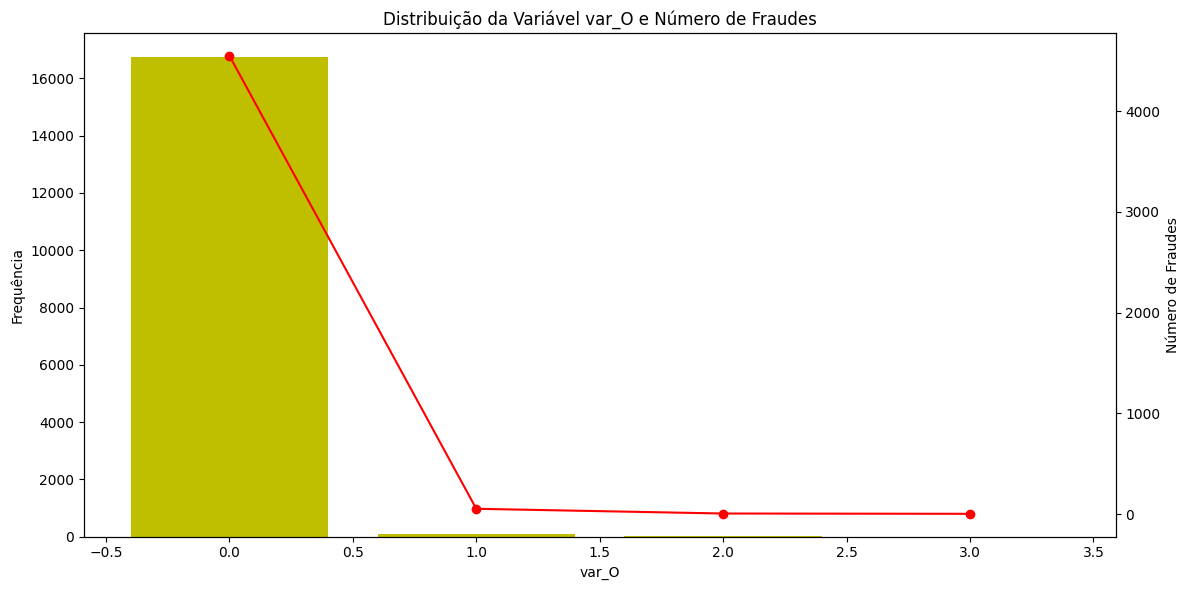

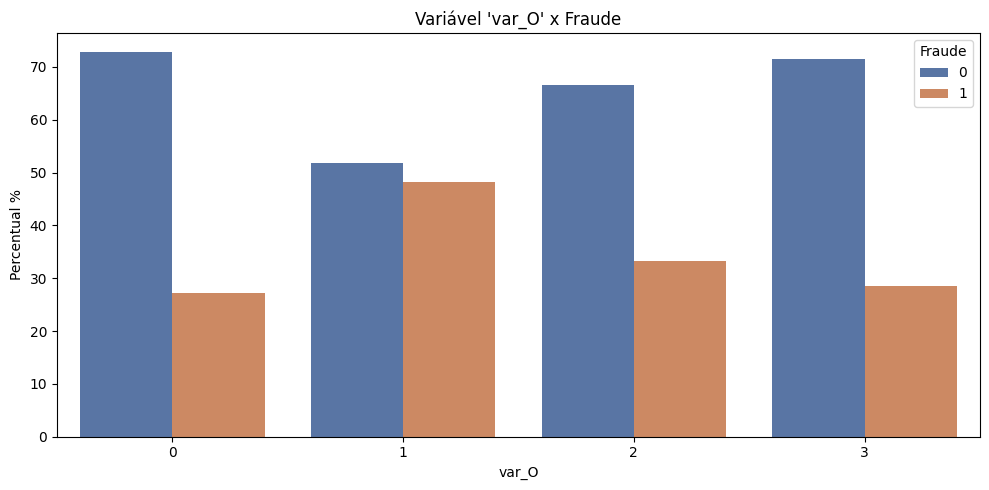

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


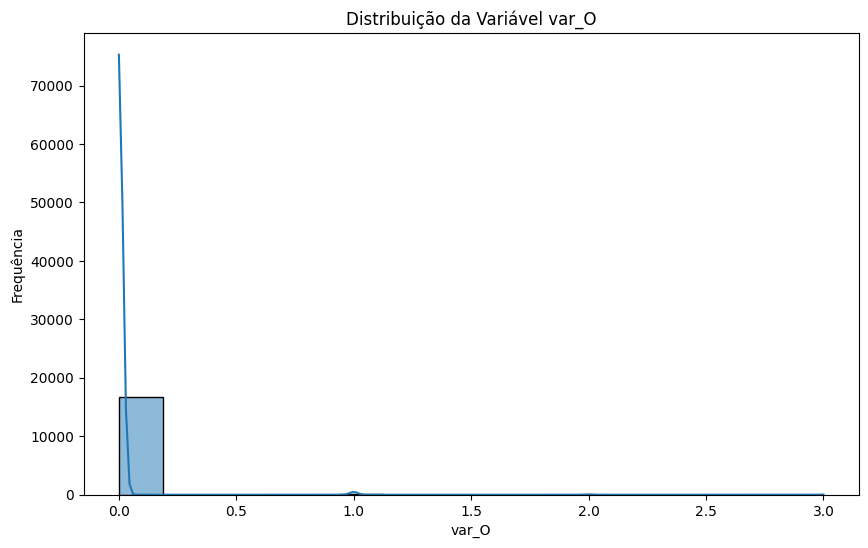

var_P


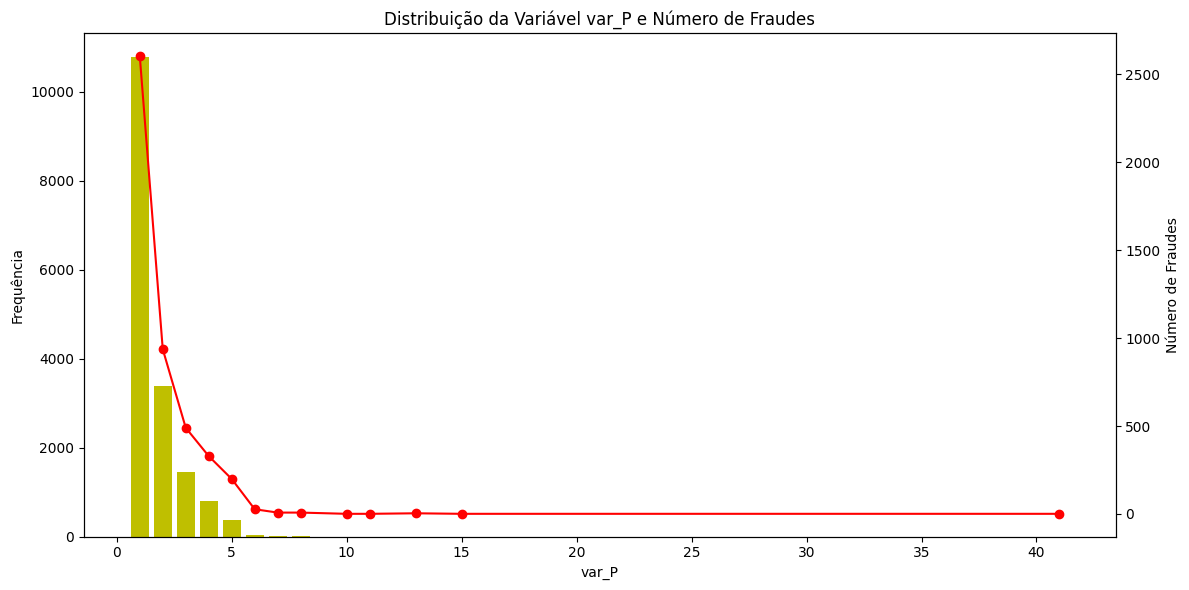

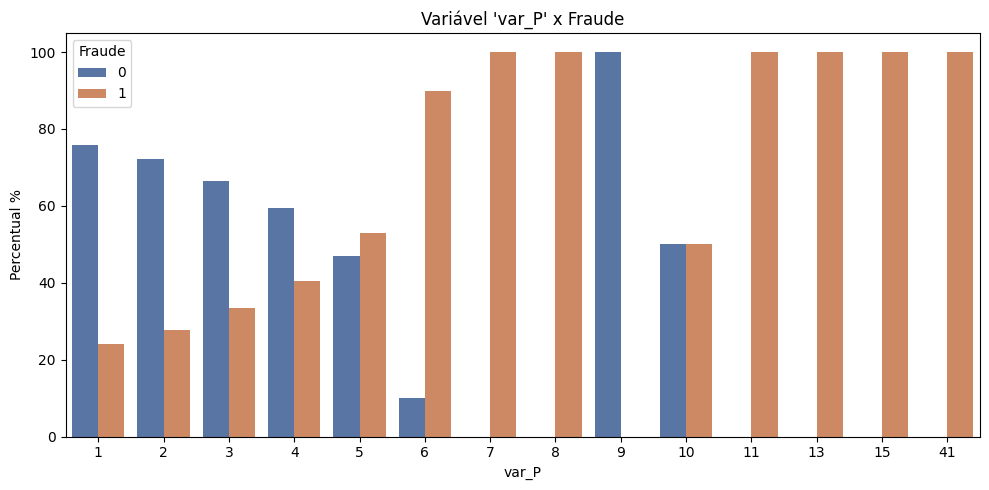

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


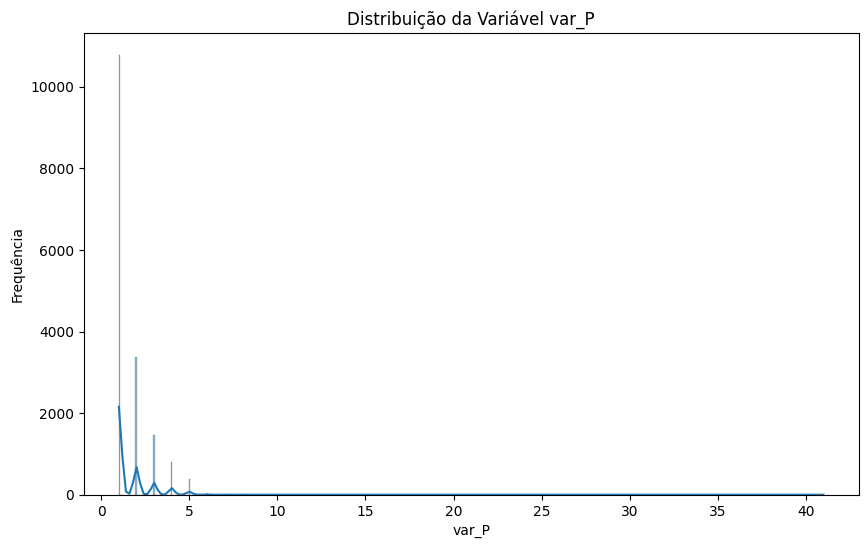

var_Q


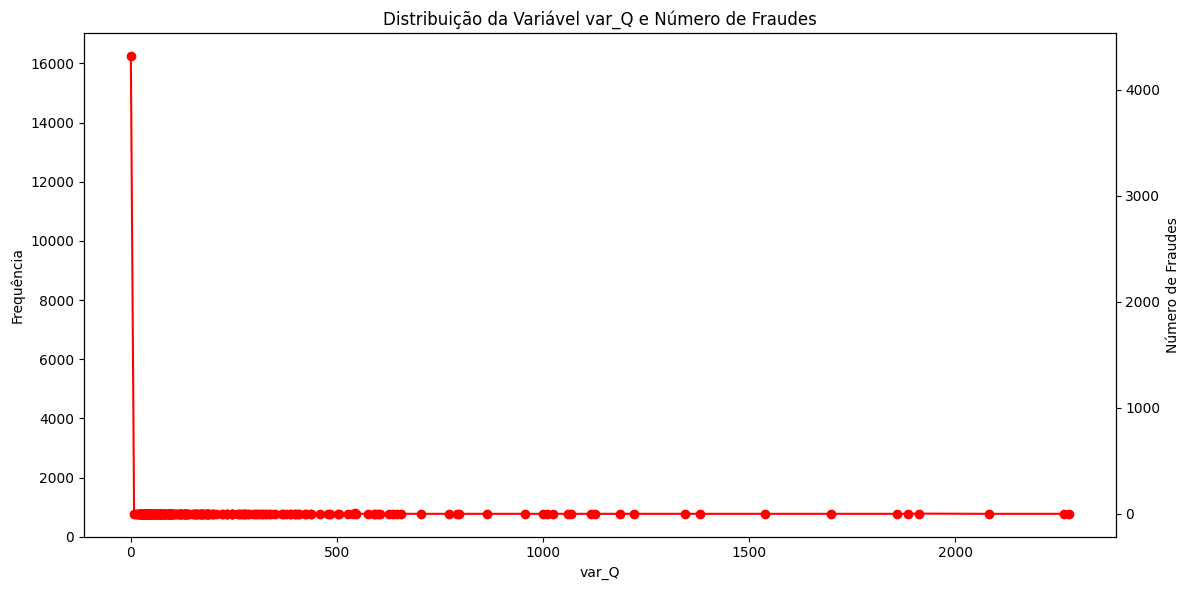

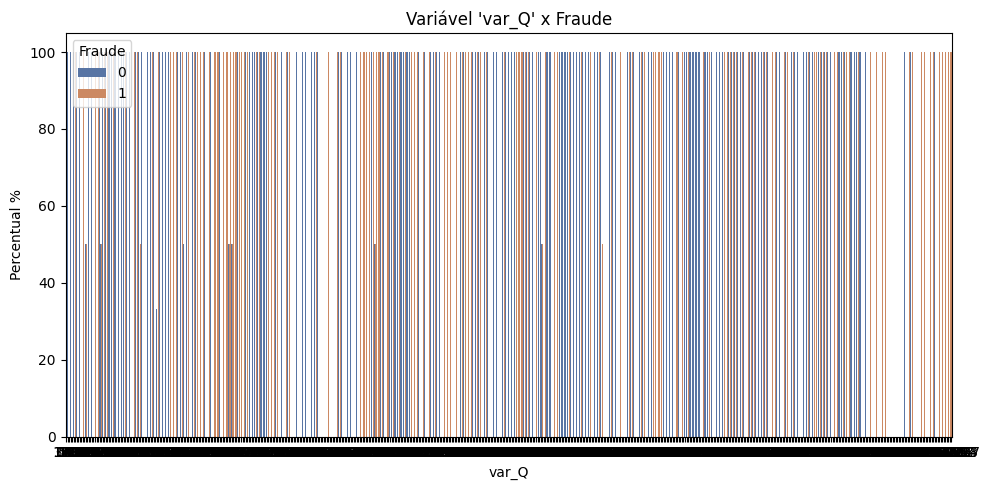

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


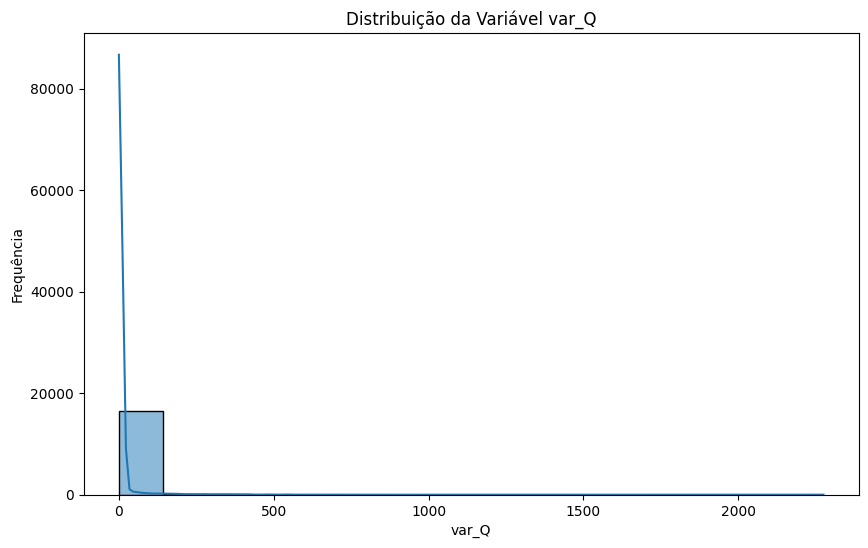

var_R


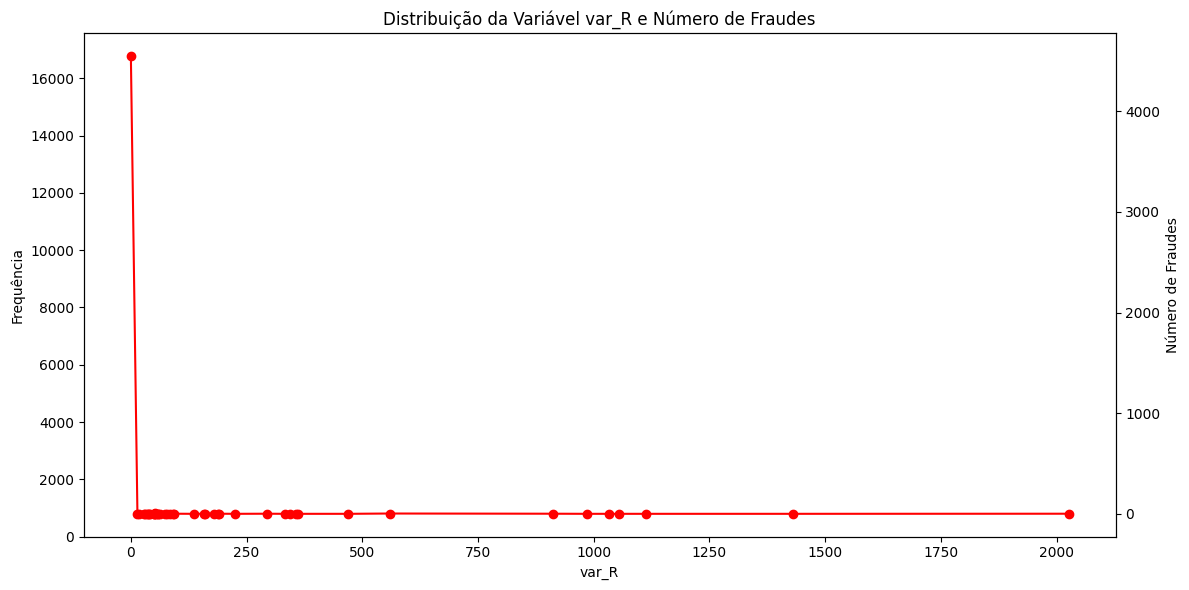

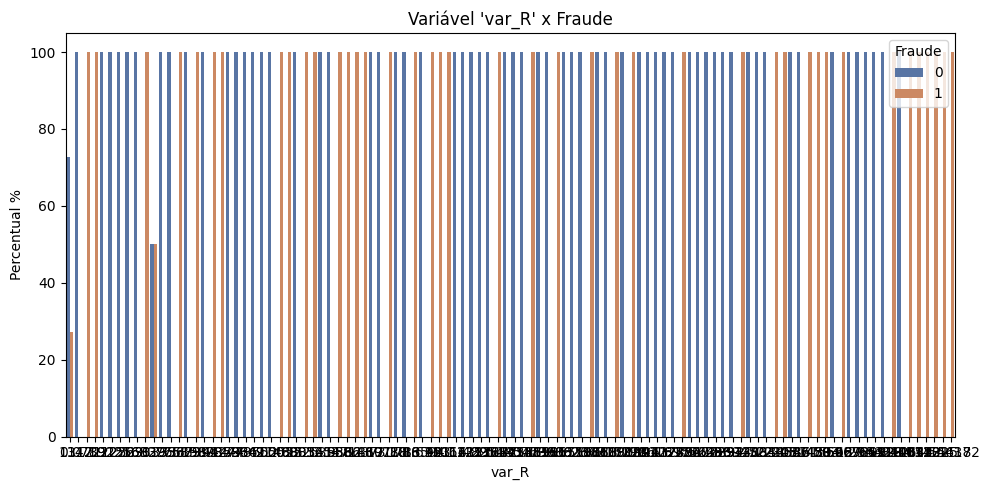

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


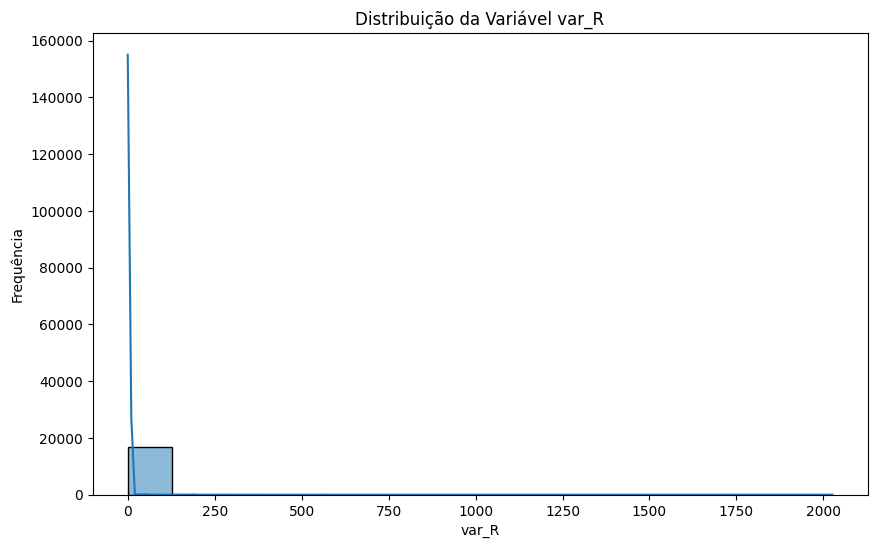

var_S


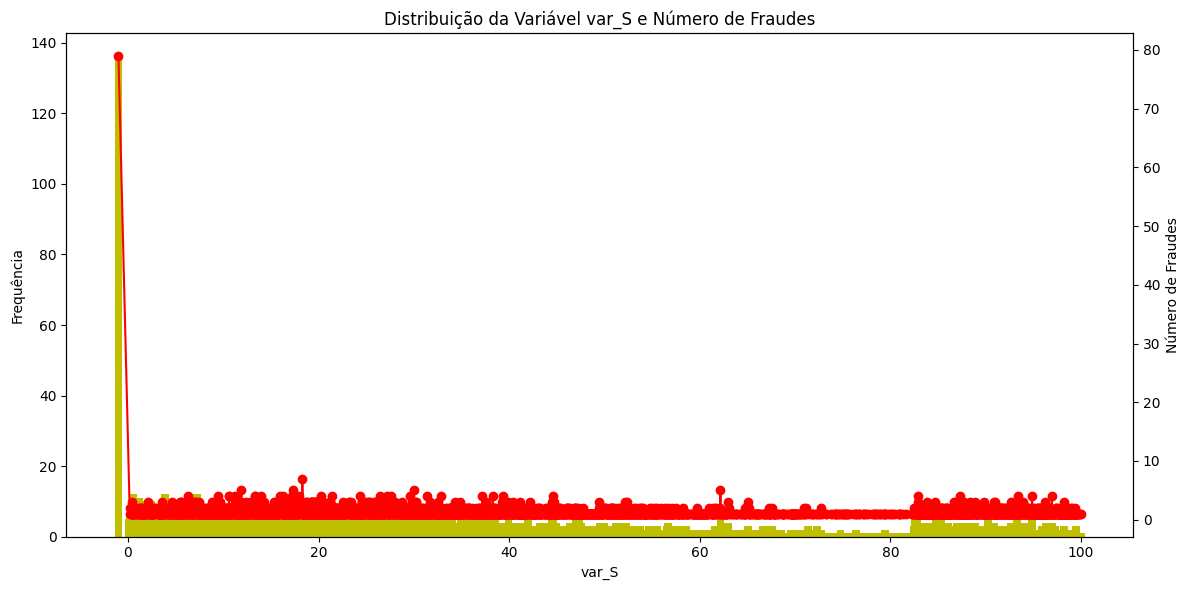

<ipython-input-218-1e83fc71f913>:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


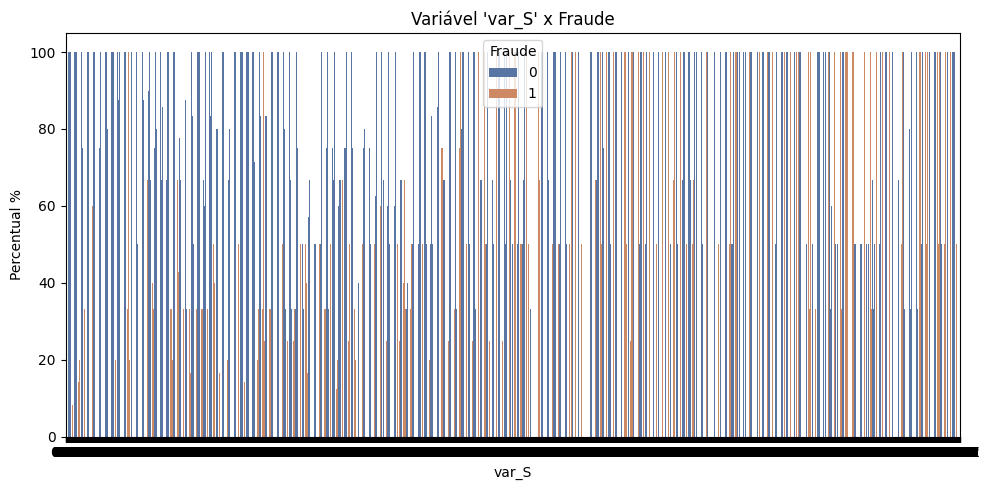

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


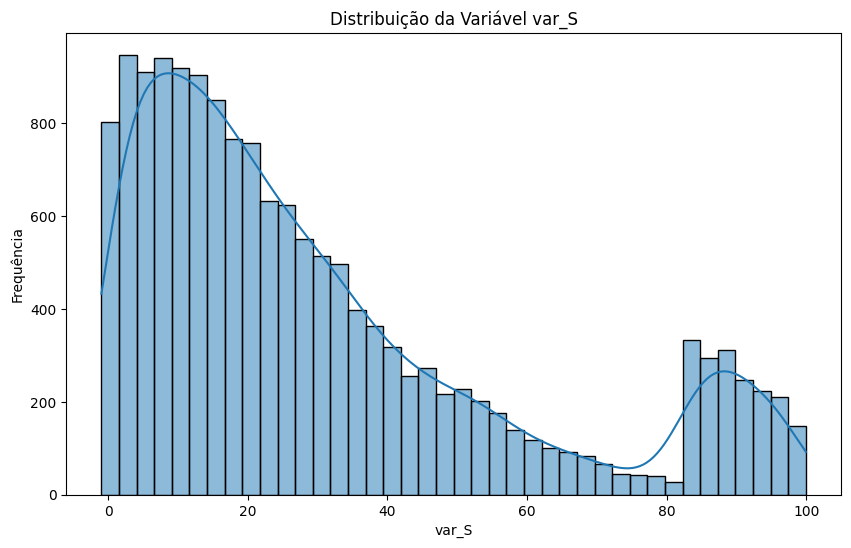

Monto


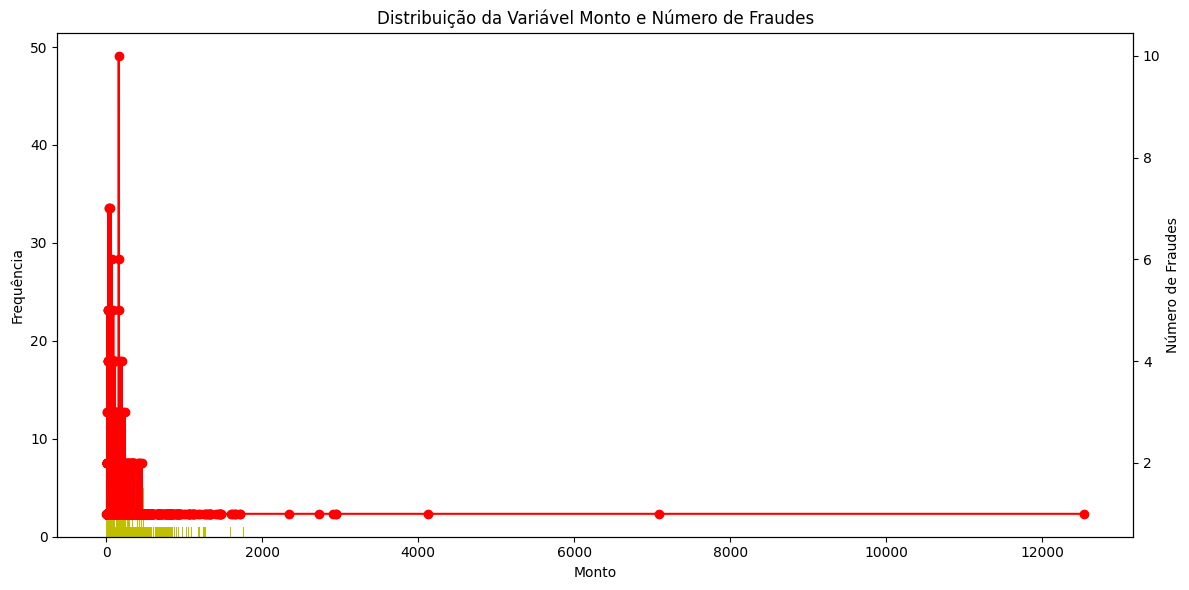

<ipython-input-218-1e83fc71f913>:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


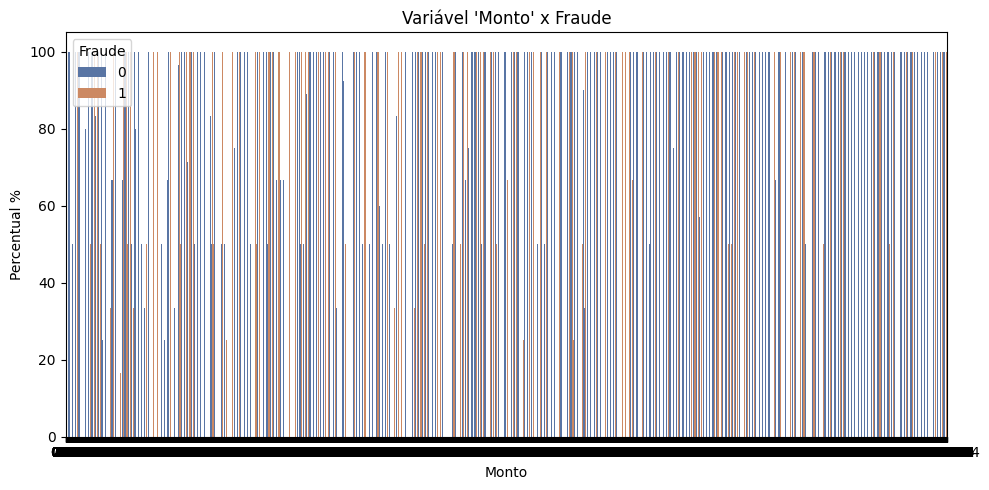

<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


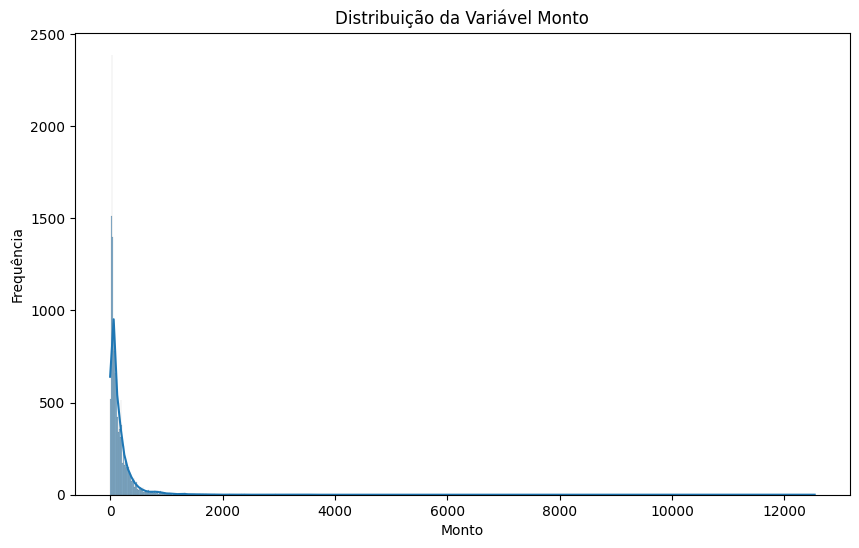

In [ ]:
for k in colunas:
  print(k)
  plot_distribuicao_target(base, k, 'Fraude')
  plotar_percentual_por_categoria(base, k, 'Fraude')
  plot_distribuicao(base, k)

## Verificação Monto

A variável MONTO possui 467 valores nulos. Eles sempre representam Fraude?

In [ ]:
monto_nan_fraude = base[base['Monto'].isna()].groupby('Fraude').size()
monto_nan_fraude

,0
Fraude,
0,354
1,113


In [ ]:
fraude = (monto_nan_fraude[1] / (monto_nan_fraude[0] + monto_nan_fraude[1])*100).round(2)
n_fraude = (monto_nan_fraude[0] / (monto_nan_fraude[0] + monto_nan_fraude[1])*100).round(2)

print(f"Proporção de Fraude quando a variável Monto é NaN: {fraude}")
print(f"Proporção de Fraude quando a variável Monto não NaN: {n_fraude}")

Proporção de Fraude quando a variável Monto é NaN: 24.2
Proporção de Fraude quando a variável Monto não NaN: 75.8


## Discretização da Variável J e Criar Dummies

In [ ]:
var_J_agrupada = base.groupby('var_J')['Fraude'].agg(['count', 'sum'])

var_J_agrupada['fraud_percentage'] = ((var_J_agrupada['sum'] / var_J_agrupada['count']) * 100).round(1)

var_J_agrupada = var_J_agrupada.rename(columns={
    'count': 'var_J_count',
    'sum': 'var_J_sum'
})
var_J_agrupada

,var_J_count,var_J_sum,fraud_percentage
var_J,,,
AR,9329,2626,28.1
AU,1,0,0.0
BR,4428,1099,24.8
CA,12,0,0.0
CH,1,0,0.0
CL,1,0,0.0
CO,1,0,0.0
ES,314,295,93.9
FR,2,0,0.0


In [ ]:
def mapear_pais(pais):
    if pais in ['BR', 'AR', 'MX']:
        return pais
    elif pais in ['ES', 'US', 'UY']:
        return 'ES_US_UY'
    else:
        return 'OUTROS'

base['pais_agg'] = base['var_J'].apply(mapear_pais)

In [ ]:
pais_agg_agrupada = base.groupby('pais_agg')['Fraude'].agg(['count', 'sum'])

pais_agg_agrupada['fraud_percentage'] = ((pais_agg_agrupada['sum'] / pais_agg_agrupada['count']) * 100).round(1)

pais_agg_agrupada = pais_agg_agrupada.rename(columns={
    'count': 'pais_agg_count',
    'sum': 'pais_agg_sum'
})
pais_agg_agrupada

,pais_agg_count,pais_agg_sum,fraud_percentage
pais_agg,,,
AR,9329,2626,28.1
BR,4428,1099,24.8
ES_US_UY,724,670,92.5
MX,2366,216,9.1
OUTROS,33,0,0.0


In [ ]:
pais_agg_dummies = pd.get_dummies(base['pais_agg'], prefix='pais_agg')
pais_agg_dummies = pais_agg_dummies.astype(int)

In [ ]:
base = pd.concat([base, pais_agg_dummies], axis=1)
base

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,...,Fraude,var_C_log,var_F_log,var_G_log,pais_agg,pais_agg_AR,pais_agg_BR,pais_agg_ES_US_UY,pais_agg_MX,pais_agg_OUTROS
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,1,10.824925,0.000000,0.0,ES_US_UY,0,0,1,0,0
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,1,10.275568,0.000000,0.0,ES_US_UY,0,0,1,0,0
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,1,4.532599,0.000000,0.0,ES_US_UY,0,0,1,0,0
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,1,10.825164,0.000000,0.0,ES_US_UY,0,0,1,0,0
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,1,9.009570,0.000000,0.0,ES_US_UY,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,11.055688,0.405465,0.0,BR,0,1,0,0,0
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,6.716595,0.000000,0.0,BR,0,1,0,0,0
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,1,11.303044,0.000000,0.0,BR,0,1,0,0,0
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,1,12.895144,0.000000,0.0,BR,0,1,0,0,0


<ipython-input-20-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


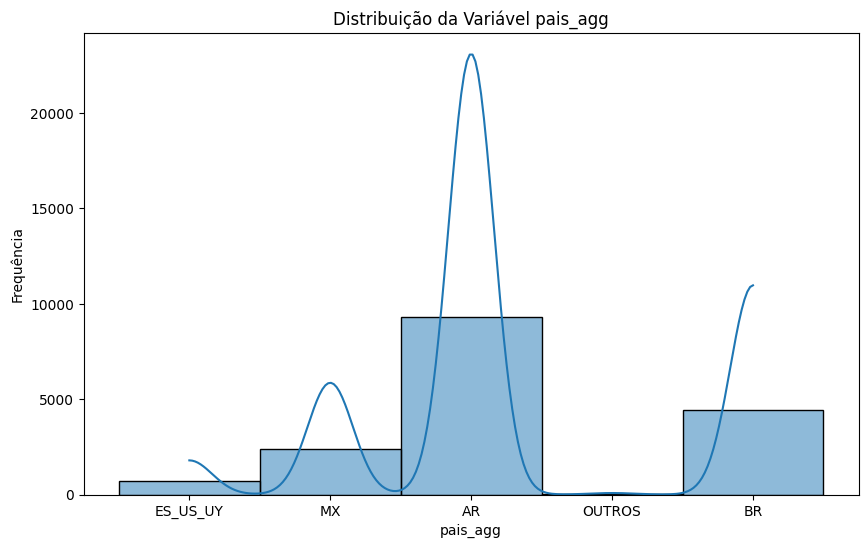

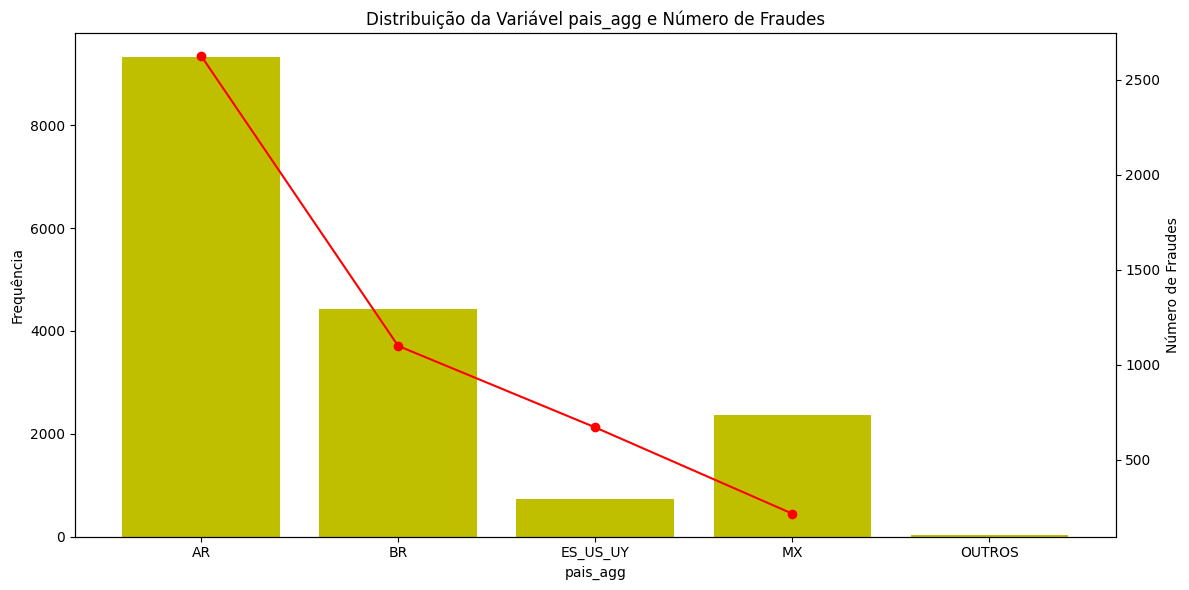

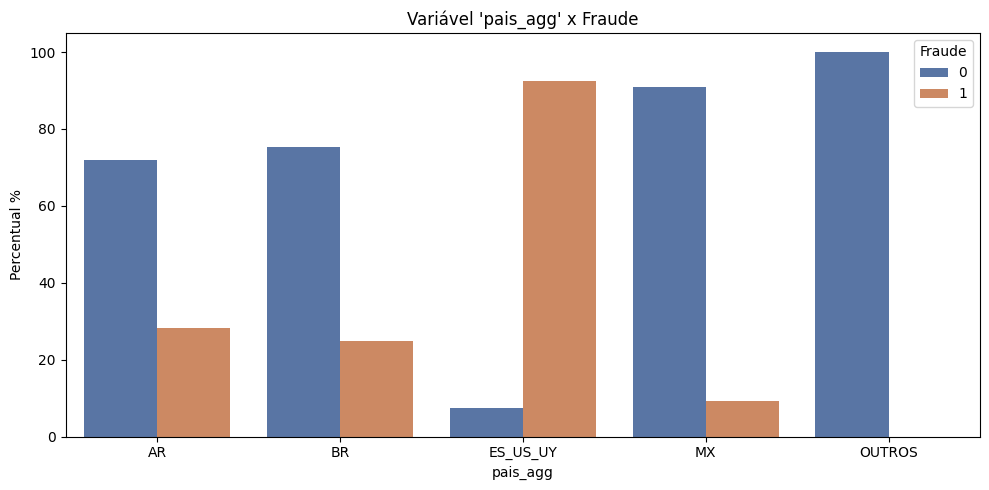

In [ ]:
plot_distribuicao(base, 'pais_agg')
plot_distribuicao_target(base, 'pais_agg', 'Fraude')
plotar_percentual_por_categoria(base, 'pais_agg', 'Fraude')

## Multiplica por 1000 a variável K

In [ ]:
base['var_K_100'] = (base['var_K'] * 100).round()

In [ ]:
base.groupby('var_K_100').count().sort_index()['Fraude']

,Fraude
var_K_100,
12.0,1
14.0,2
15.0,1
17.0,1
18.0,2
...,...
95.0,37
96.0,43
97.0,20


<ipython-input-217-336b4c756661>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[variable_name], kde=True, palette='deep')


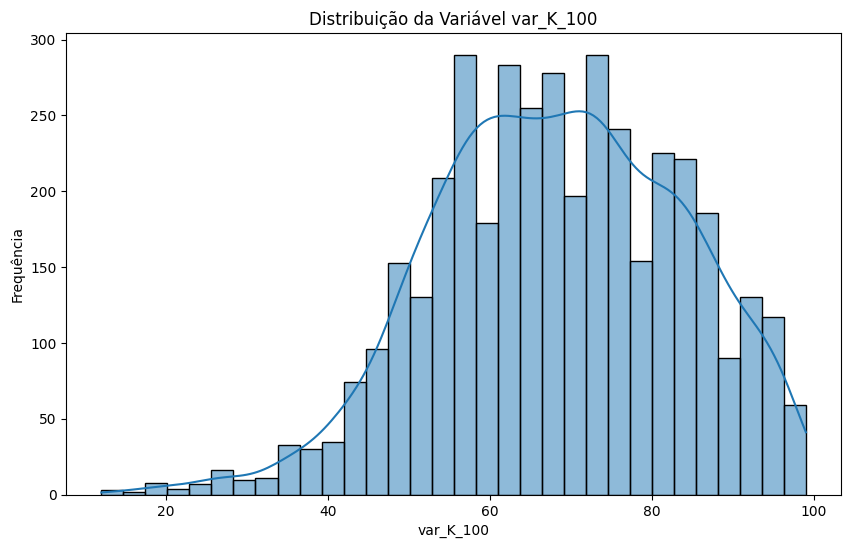

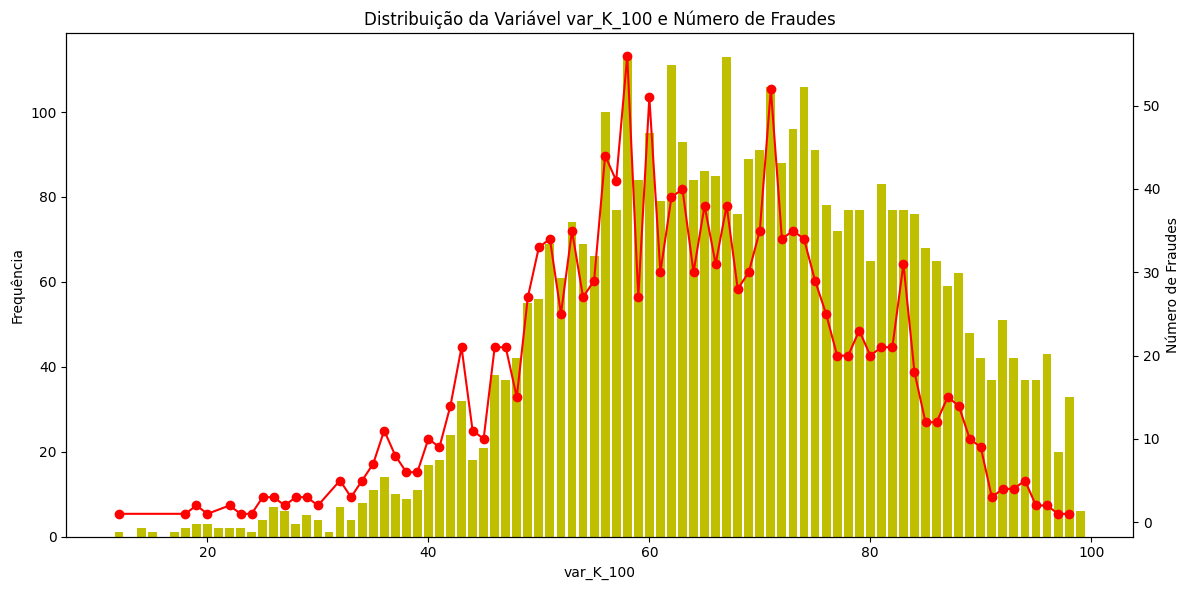

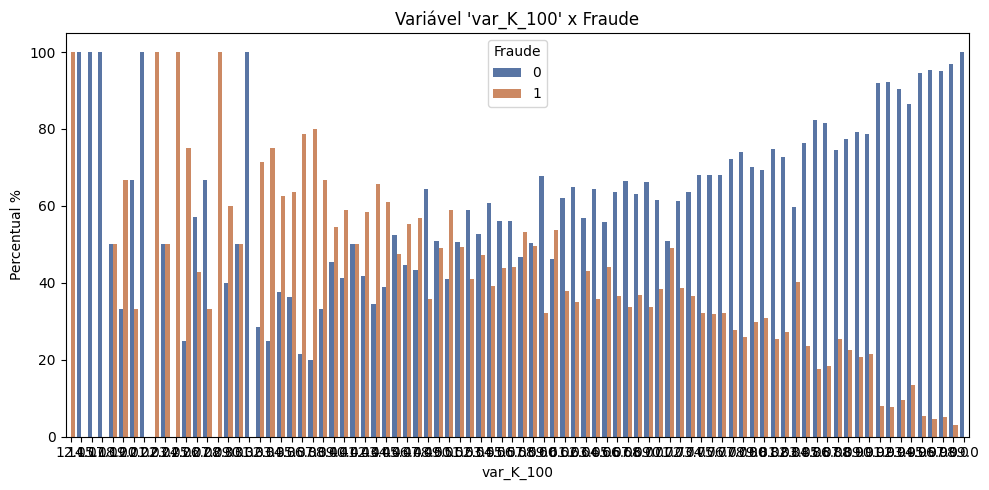

In [ ]:
plot_distribuicao(base, 'var_K_100')
plot_distribuicao_target(base, 'var_K_100', 'Fraude')
plotar_percentual_por_categoria(base, 'var_K_100', 'Fraude')

## Dropar variáveis

In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16880 non-null  int64  
 1   var_B              16880 non-null  int64  
 2   var_C              13683 non-null  float64
 3   var_D              16880 non-null  int64  
 4   var_E              16880 non-null  int64  
 5   var_F              16880 non-null  float64
 6   var_G              16880 non-null  float64
 7   var_H              16880 non-null  int64  
 8   var_I              16880 non-null  int64  
 9   var_J              16880 non-null  object 
 10  var_K              4016 non-null   float64
 11  var_L              16880 non-null  int64  
 12  var_M              16880 non-null  int64  
 13  var_N              16880 non-null  int64  
 14  var_O              16880 non-null  int64  
 15  var_P              16880 non-null  int64  
 16  var_Q              168

In [ ]:
drop_col = ['var_C', 'var_F', 'var_G', 'var_J', 'pais_agg', 'var_K']
base = base.drop(columns=drop_col, errors='ignore')
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16880 non-null  int64  
 1   var_B              16880 non-null  int64  
 2   var_D              16880 non-null  int64  
 3   var_E              16880 non-null  int64  
 4   var_H              16880 non-null  int64  
 5   var_I              16880 non-null  int64  
 6   var_L              16880 non-null  int64  
 7   var_M              16880 non-null  int64  
 8   var_N              16880 non-null  int64  
 9   var_O              16880 non-null  int64  
 10  var_P              16880 non-null  int64  
 11  var_Q              16863 non-null  float64
 12  var_R              16877 non-null  float64
 13  var_S              15575 non-null  float64
 14  Monto              16413 non-null  float64
 15  Fraude             16880 non-null  int64  
 16  var_C_log          136

In [ ]:
## Número de Nulos nas Variáveis
base.isna().sum()

,0
var_A,0
var_B,0
var_D,0
var_E,0
var_H,0
var_I,0
var_L,0
var_M,0
var_N,0
var_O,0


# Nulos para Feature Selection utilizando Random Forest

In [ ]:
base.columns

Index(['var_A', 'var_B', 'var_D', 'var_E', 'var_H', 'var_I', 'var_L', 'var_M',
       'var_N', 'var_O', 'var_P', 'var_Q', 'var_R', 'var_S', 'Monto', 'Fraude',
       'var_C_log', 'var_F_log', 'var_G_log', 'pais_agg_AR', 'pais_agg_BR',
       'pais_agg_ES_US_UY', 'pais_agg_MX', 'pais_agg_OUTROS', 'var_K_100'],
      dtype='object')

In [ ]:
variaveis_numericas = ['var_A', 'var_B', 'var_D', 'var_E', 'var_H', 'var_I', 'var_L', 'var_M',
       'var_N', 'var_O', 'var_P', 'var_Q', 'var_R', 'var_S', 'Monto',
       'var_C_log', 'var_F_log', 'var_G_log', 'pais_agg_AR', 'pais_agg_BR',
       'pais_agg_ES_US_UY', 'pais_agg_MX', 'pais_agg_OUTROS', 'var_K_100']

target = ['Fraude']

In [ ]:
for col in variaveis_numericas:
    # base[f"{col}_missing"] = base[col].isna().astype(int)
    base[col] = base[col].fillna(-999999999)

## Treino, Teste e Validação

In [ ]:
X = base.drop(columns=["Fraude"], errors='ignore')
y = base["Fraude"]

In [ ]:
X_treino, X_temp, y_treino, y_temp = train_test_split(X, y, test_size=0.4, random_state=13, stratify=y)
X_teste, X_valid, y_teste, y_valid = train_test_split(X_temp, y_temp, test_size=0.5, random_state=13, stratify=y_temp)

# Feature Selection

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=13)
rf.fit(X_treino, y_treino)

RandomForestClassifier(random_state=13)

In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X_treino.columns).sort_values(ascending=False)
importancias

,0
var_S,0.177016
Monto,0.153726
var_C_log,0.145018
var_B,0.138455
pais_agg_ES_US_UY,0.075441
var_K_100,0.045672
var_P,0.043743
var_M,0.032193
var_L,0.026451
var_A,0.024251


In [ ]:
features_selecionadas = importancias[importancias >= 0.01].index.tolist()
features_selecionadas

['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'pais_agg_ES_US_UY',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'pais_agg_MX',
 'var_F_log',
 'pais_agg_AR',
 'pais_agg_BR',
 'var_Q',
 'var_D']